In [77]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots
import matplotlib as mpl
# 1) セットアップ関数を読み込む（下のコードを1セルに貼るだけ）
from pathlib import Path
import importlib
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # --- フォント関連 ---
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Helvetica",
        "Arial",
        "DejaVu Sans",
        "Noto Sans CJK JP",
        "IPAexGothic",
    ],
    "mathtext.fontset": "stixsans",   # 数式もサンセリフ系に統一
    "mathtext.default": "it",         # LaTeX風の斜体
    "axes.unicode_minus": False,

    # --- サイズ系 ---
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "lines.linewidth": 2.2,

    # --- 軸と目盛り ---
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # --- 凡例とスタイル ---
    "legend.frameon": False,
    "figure.figsize": (4.5, 3.3),
    "figure.dpi": 300,
    "savefig.dpi": 400,
    "savefig.transparent": True,
})


# plt.rcParams['figure.figsize'] = fig_size
#plt.rcParams['mathtext.fontset'] = 'stix'
#plt.rcParams['font.family'] = 'STIXGeneral'
#plt.rcParams['text.usetex'] = True
M_sun = 1.989e33  # g
R_sun = 6.96e10  # cm
k_B = 1.380649e-16  # erg/K
G = 6.67430e-8  # cm^3/g/s^2
c = 2.99792458e10  # cm/s
R_NS = 1e6  # cm
M_NS = 1.4 * M_sun  # g
year = 3.1536e7  # s
R_c = 8.5
# import pulsar_lambert
# importlib.reload(pulsar_lambert)
# from pulsar_lambert import ra_dec_to_deg, xy, lb, lb_to_aitoff_rad, add_lb_box_aitoff, pl_lumi_mc, beaming_curve_cumulative, beaming_curve_cumulative_age, pl_lumi_delta

KPC_TO_CM = 3.086e21
TEV_TO_ERG = 1.602

In [78]:
def _as_array(x):
    """None/スカラー/ndarrayのいずれでも ndarray にする（コピーしない）"""
    return np.asarray(x)
import numpy as np

def pl_lumi_mc(
    f0, f0_err, gamma, gamma_err, d_kpc, d_err,
    E0=1.0, Emin=1.0, Emax=10.0,
    nsim=20000, random_state=None
):
    rng = np.random.default_rng(random_state)

    # 共同形状 S
    S = np.broadcast_shapes(
        _as_array(f0).shape, _as_array(f0_err).shape,
        _as_array(gamma).shape, _as_array(gamma_err).shape,
        _as_array(d_kpc).shape, _as_array(d_err).shape,
        _as_array(E0).shape, _as_array(Emin).shape, _as_array(Emax).shape,
    )

    # ブロードキャストして float 化
    f0      = np.broadcast_to(_as_array(f0),      S).astype(float)
    f0_err  = np.broadcast_to(_as_array(f0_err),  S).astype(float)
    gamma   = np.broadcast_to(_as_array(gamma),   S).astype(float)
    gamma_err = np.broadcast_to(_as_array(gamma_err), S).astype(float)
    d_kpc   = np.broadcast_to(_as_array(d_kpc),   S).astype(float)
    d_err   = np.broadcast_to(_as_array(d_err),   S).astype(float)
    E0      = np.broadcast_to(_as_array(E0),      S).astype(float)
    Emin    = np.broadcast_to(_as_array(Emin),    S).astype(float)
    Emax    = np.broadcast_to(_as_array(Emax),    S).astype(float)

    # サンプル（MC軸を先頭に）
    size = (nsim,) + S
    f0_sig = np.nan_to_num(f0_err,   nan=0.0, posinf=0.0, neginf=0.0)
    g_sig  = np.nan_to_num(gamma_err,nan=0.0, posinf=0.0, neginf=0.0)
    d_sig  = np.nan_to_num(d_err,    nan=0.0, posinf=0.0, neginf=0.0)

    f0_s = rng.normal(loc=f0,    scale=f0_sig, size=size)
    g_s  = rng.normal(loc=gamma, scale=g_sig,  size=size)
    d_s  = rng.normal(loc=d_kpc, scale=d_sig,  size=size)

    # E0/Emin/Emax を (nsim,)+S に拡張（ここが重要）
    E0_s   = np.broadcast_to(E0,   S)[None, ...]
    Emin_s = np.broadcast_to(Emin, S)[None, ...]
    Emax_s = np.broadcast_to(Emax, S)[None, ...]
    E0_s   = np.broadcast_to(E0_s,   f0_s.shape)
    Emin_s = np.broadcast_to(Emin_s, f0_s.shape)
    Emax_s = np.broadcast_to(Emax_s, f0_s.shape)

    # 積分（Γ=2 は log、Γ≠2 は解析式）— 全要素一括で np.where
    with np.errstate(divide='ignore', invalid='ignore'):
        mask_eq2 = np.isclose(g_s, 2.0, rtol=1e-12, atol=1e-12)
        # Γ≠2 の項
        integral_ne2 = (np.power(Emax_s, 2.0 - g_s) - np.power(Emin_s, 2.0 - g_s)) / (2.0 - g_s)
        # Γ=2 の項
        integral_eq2 = np.log(Emax_s / Emin_s)
        integral = np.where(mask_eq2, integral_eq2, integral_ne2)

    # 光度
    d_cm_s = d_s * KPC_TO_CM
    L_s = 4.0 * np.pi * (d_cm_s**2) * f0_s * np.power(E0_s, g_s) * integral * TEV_TO_ERG

    # 物理的に不正なサンプルを除外
    bad_bounds = ~np.isfinite(Emin_s) | ~np.isfinite(Emax_s) | (Emin_s <= 0) | (Emax_s <= Emin_s)
    bad = (f0_s <= 0) | (d_s <= 0) | ~np.isfinite(L_s) | bad_bounds
    L_s[bad] = np.nan

    mean   = np.nanmean(L_s, axis=0)
    q16    = np.nanpercentile(L_s, 16, axis=0)
    q84    = np.nanpercentile(L_s, 84, axis=0)
    err_lo = mean - q16
    err_hi = q84 - mean

    if mean.size == 1:
        return float(mean), float(err_lo), float(err_hi)
    return mean, err_lo, err_hi

In [104]:
df_pwn = pd.read_csv('/Users/takumi/NS/PWN/csv/PWN_catalog.csv')
pwn_HESS = df_pwn[df_pwn['Survey'].str.contains('H.E.S.S.', regex=False, na=False)]
pwn_LHAASO = df_pwn[df_pwn['Survey'].str.contains('LHAASO', regex=False, na=False)]
pwn_HAWC = df_pwn[df_pwn['Survey'].str.contains('HAWC', regex=False, na=False)]
pwn_HESS_age = pwn_HESS['tau_c_[kyr]'].dropna()
pwn_LHAASO_age = pwn_LHAASO['tau_c_[kyr]'].dropna()
pwn_HAWC_age = pwn_HAWC['tau_c_[kyr]'].dropna()
pwn_HESS_Edot = pwn_HESS['log10_Edot_[erg/s]'].dropna() 
pwn_LHAASO_Edot = pwn_LHAASO['log10_Edot_[erg/s]'].dropna()
pwn_HAWC_Edot = pwn_HAWC['log10_Edot_[erg/s]'].dropna()
pwn_HESS_d = pwn_HESS['d_[kpc]'].dropna()
pwn_LHAASO_d = pwn_LHAASO['d_[kpc]'].dropna()
pwn_HAWC_d = pwn_HAWC['d_[kpc]'].dropna()
pwn_HESS_flux = pwn_HESS['Flux(cm-2 s-1 TeV-1)'].dropna()
pwn_LHAASO_flux = pwn_LHAASO['Flux(cm-2 s-1 TeV-1)'].dropna()
pwn_HAWC_flux = pwn_HAWC['Flux(cm-2 s-1 TeV-1)'].dropna()
pwn_HESS_flux_err = pwn_HESS['Flux_error'].dropna()
pwn_LHAASO_flux_err = pwn_LHAASO['Flux_error'].dropna()
pwn_HAWC_flux_err = pwn_HAWC['Flux_error'].dropna()
pwn_HESS_index = pwn_HESS['index'].dropna()
pwn_LHAASO_index = pwn_LHAASO['index'].dropna()
pwn_HAWC_index = pwn_HAWC['index'].dropna()
pwn_HESS_index_err = pwn_HESS['index_error'].dropna()
pwn_LHAASO_index_err = pwn_LHAASO['index_error'].dropna()
pwn_HAWC_index_err = pwn_HAWC['index_error'].dropna()
pwn_HESS_pivot = pwn_HESS['Pivot'].dropna()
pwn_LHAASO_pivot = pwn_LHAASO['Pivot'].dropna()
pwn_HAWC_pivot = pwn_HAWC['Pivot'].dropna()
pwn_flux = df_pwn['Flux(cm-2 s-1 TeV-1)'].dropna()
pwn_flux_err = df_pwn['Flux_error'].dropna()
pwn_index = df_pwn['index'].dropna()
pwn_index_err = df_pwn['index_error'].dropna()
pwn_d = df_pwn['d_[kpc]'].dropna()
pwn_pivot = df_pwn['Pivot'].dropna()
n_pwn_HESS = len(pwn_HESS)
pwn_l = df_pwn['l'].dropna()
pwn_b = df_pwn['b'].dropna()
pwn_HESS_b = pwn_HESS['b'].dropna()
pwn_LHAASO_b = pwn_LHAASO['b'].dropna()
pwn_HAWC_b = pwn_HAWC['b'].dropna()
pwn_HESS_l = pwn_HESS['l'].dropna()
pwn_LHAASO_l = pwn_LHAASO['l'].dropna()
pwn_HAWC_l = pwn_HAWC['l'].dropna()
pwn_size = df_pwn["size"]
pwn_HESS_size = pwn_HESS["size"]
pwn_LHAASO_size = pwn_LHAASO["size"]
pwn_HAWC_size = pwn_HAWC["size"]
pwn_HESS_psize = pwn_HESS["size"] * pwn_HESS_d * np.pi / 180 * 1000  # pc
pwn_LHAASO_psize = pwn_LHAASO["size"] * pwn_LHAASO_d * np.pi / 180 * 1000  # pc
pwn_HAWC_psize = pwn_HAWC["size"] * pwn_HAWC_d * np.pi / 180 * 1000  # pc
pwn_HESS_psize = pwn_HESS_psize[pwn_HESS_psize > 0]
pwn_LHAASO_psize = pwn_LHAASO_psize[pwn_LHAASO_psize > 0]
pwn_HAWC_psize = pwn_HAWC_psize[pwn_HAWC_psize > 0]
df_unid = pd.read_csv('/Users/takumi/NS/PWN/csv/unid.csv')
unid_l = df_unid['l'].dropna()
unid_b = df_unid['b'].dropna()
unid_size = df_unid["size(deg)"]
df_unid_HESS = df_unid[df_unid['Survey'].str.contains('H.E.S.S.', regex=False, na=False)]
n_unid_HESS = len(df_unid_HESS[np.abs(df_unid_HESS['b']) < 7])
unid_HESS_flux = df_unid_HESS['Flux(cm-2 s-1 TeV-1)'].dropna()
unid_HESS_flux_err = df_unid_HESS['Flux_error'].dropna()
unid_HESS_index = df_unid_HESS['index'].dropna()
unid_HESS_index_err = df_unid_HESS['index_error'].dropna()
unid_HESS_pivot = df_unid_HESS['Pivot'].dropna()
df_unid_LHAASO = df_unid[df_unid['Survey'].str.contains('LHAASO', regex=False, na=False)]
n_unid_LHAASO = len(df_unid_LHAASO[np.abs(df_unid_LHAASO['b']) < 5])
unid_LHAASO_flux = df_unid_LHAASO['Flux(cm-2 s-1 TeV-1)'].dropna()
unid_LHAASO_flux_err = df_unid_LHAASO['Flux_error'].dropna()
unid_LHAASO_index = df_unid_LHAASO['index'].dropna()
unid_LHAASO_index_err = df_unid_LHAASO['index_error'].dropna()
unid_LHAASO_pivot = df_unid_LHAASO['Pivot'].dropna()
df_unid_HAWC = df_unid[df_unid['Survey'].str.contains('HAWC', regex=False, na=False)]
n_unid_HAWC = len(df_unid_HAWC[np.abs(df_unid_HAWC['b']) < 4])  
unid_HAWC_flux = df_unid_HAWC['Flux(cm-2 s-1 TeV-1)'].dropna()
unid_HAWC_flux_err = df_unid_HAWC['Flux_error'].dropna()
unid_HAWC_index = df_unid_HAWC['index'].dropna()
unid_HAWC_index_err = df_unid_HAWC['index_error'].dropna()
unid_HAWC_pivot = df_unid_HAWC['Pivot'].dropna()
unid_flux = df_unid['Flux(cm-2 s-1 TeV-1)'].dropna()
unid_flux_err = df_unid['Flux_error'].dropna()
unid_index = df_unid['index'].dropna()
unid_index_err = df_unid['index_error'].dropna()
unid_pivot = df_unid['Pivot'].dropna()
unid_HESS_size = df_unid_HESS['size(deg)']
unid_HAWC_size = df_unid_HAWC['size(deg)']
unid_LHAASO_size = df_unid_LHAASO['size(deg)']

In [105]:
def beaming_curve_cumulative(logL, n_unid_region, logL_nu=None, compress=False, return_error=True):
    """
    累積ビーミングカーブ
    f_b = N_{nu,PWN} / (N_PWN + N_Unid)

    Parameters
    ----------
    logL : array-like
        全PWNサンプル（分母の N_PWN を決める母集団）
    n_unid_region : int
        その領域の未同定源数 N_Unid
    logL_nu : array-like or None
        波長 nu で実際に検出されているPWNサンプル（分子の N_{nu,PWN}）
        None の場合は logL を使う
    """
    # --- 分母に使う全PWN母集団 ---
    v_all = np.asarray(logL, dtype=float)
    v_all = v_all[np.isfinite(v_all)]
    if v_all.size == 0:
        return np.array([]), np.array([]), np.nan, 0

    n_pwn_total = v_all.size

    # --- 分子に使う ν帯の検出サンプル ---
    if logL_nu is None:
        v = v_all.copy()
    else:
        v = np.asarray(logL_nu, dtype=float)
        v = v[np.isfinite(v)]

    if v.size == 0:
        x = np.array([])
        y = np.array([])
        y_final = 0.0
        n_det = 0
        if not return_error:
            return x, y, y_final, n_det
        return x, y, y_final, n_det, np.array([]), np.array([]), np.array([])

    # 高→低に並べ替え
    v_sorted = np.sort(v)[::-1]
    nbins = 10

    # --- ビン化 ---
    if nbins is not None and nbins > 1:
        edges = np.linspace(v_sorted.min(), v_sorted.max(), nbins + 1)
        centers = 0.5 * (edges[1:] + edges[:-1])
        counts = np.array([(v_sorted >= edge).sum() for edge in edges[:-1]])
        x = centers
        k = counts   # = N_{nu,PWN}(>threshold)
    else:
        if compress:
            uniq, counts = np.unique(v_sorted, return_counts=True)
            x = uniq
            k = np.cumsum(counts)
        else:
            x = v_sorted
            k = np.arange(1, v_sorted.size + 1)

    # --- ここが重要 ---
    # 分母は N_PWN + N_Unid で固定
    denom = n_pwn_total + n_unid_region
    y = k / denom

    y_final = y[-1]
    n_det = int(k[-1])

    if not return_error:
        return x, y, y_final, n_det

    # Poisson誤差
    # f = k / denom,  denom = N_PWN + N_Unid
    # Var(f) = (∂f/∂k)^2 Var(k) + (∂f/∂N_unid)^2 Var(N_unid)
    #        = (1/denom)^2 k + (k/denom^2)^2 n_unid_region
    sigma_y = np.sqrt(k / denom**2 + (k**2) * n_unid_region / denom**4)

    y_low = np.clip(y - sigma_y, 0, 1)
    y_high = np.clip(y + sigma_y, 0, 1)

    return x, y, y_final, n_det, sigma_y, y_low, y_high

In [106]:
def beaming_curve_cumulative_age(log_age, n_unid_region, log_age_nu=None,
                                 mode="binned10",
                                 return_error=True, prepend_first=True):
    """
    年齢依存ビーミング累積カーブ
    f_b = N_{nu,PWN} / (N_PWN + N_Unid)
    """
    v_all = np.sort(np.asarray(log_age, float))
    v_all = v_all[np.isfinite(v_all)]
    if v_all.size == 0:
        return np.array([]), np.array([]), np.nan

    n_pwn_total = v_all.size

    if log_age_nu is None:
        v = v_all.copy()
    else:
        v = np.sort(np.asarray(log_age_nu, float))
        v = v[np.isfinite(v)]

    if v.size == 0:
        x = np.array([])
        y = np.array([])
        y_final = 0.0
        if not return_error:
            return x, y, y_final
        return x, y, y_final, np.array([]), np.array([]), np.array([])

    if mode == "ecdf":
        x = v
        k = np.arange(1, v.size + 1)
    else:  # "binned10"
        edges = np.linspace(v[0], v[-1], 11)
        k = np.searchsorted(v, edges[1:], side='right')
        x = 0.5 * (edges[:-1] + edges[1:])
        if prepend_first:
            x = np.concatenate(([v[0]], x))
            k = np.concatenate(([1], k))
            k = np.maximum.accumulate(k)

    denom = n_pwn_total + n_unid_region
    y = k / denom
    y_final = y[-1]

    if not return_error:
        return x, y, y_final

    sigma_y = np.sqrt(k / denom**2 + (k**2) * n_unid_region / denom**4)
    y_low = np.clip(y - sigma_y, 0, 1)
    y_high = np.clip(y + sigma_y, 0, 1)

    return x, y, y_final, sigma_y, y_low, y_high

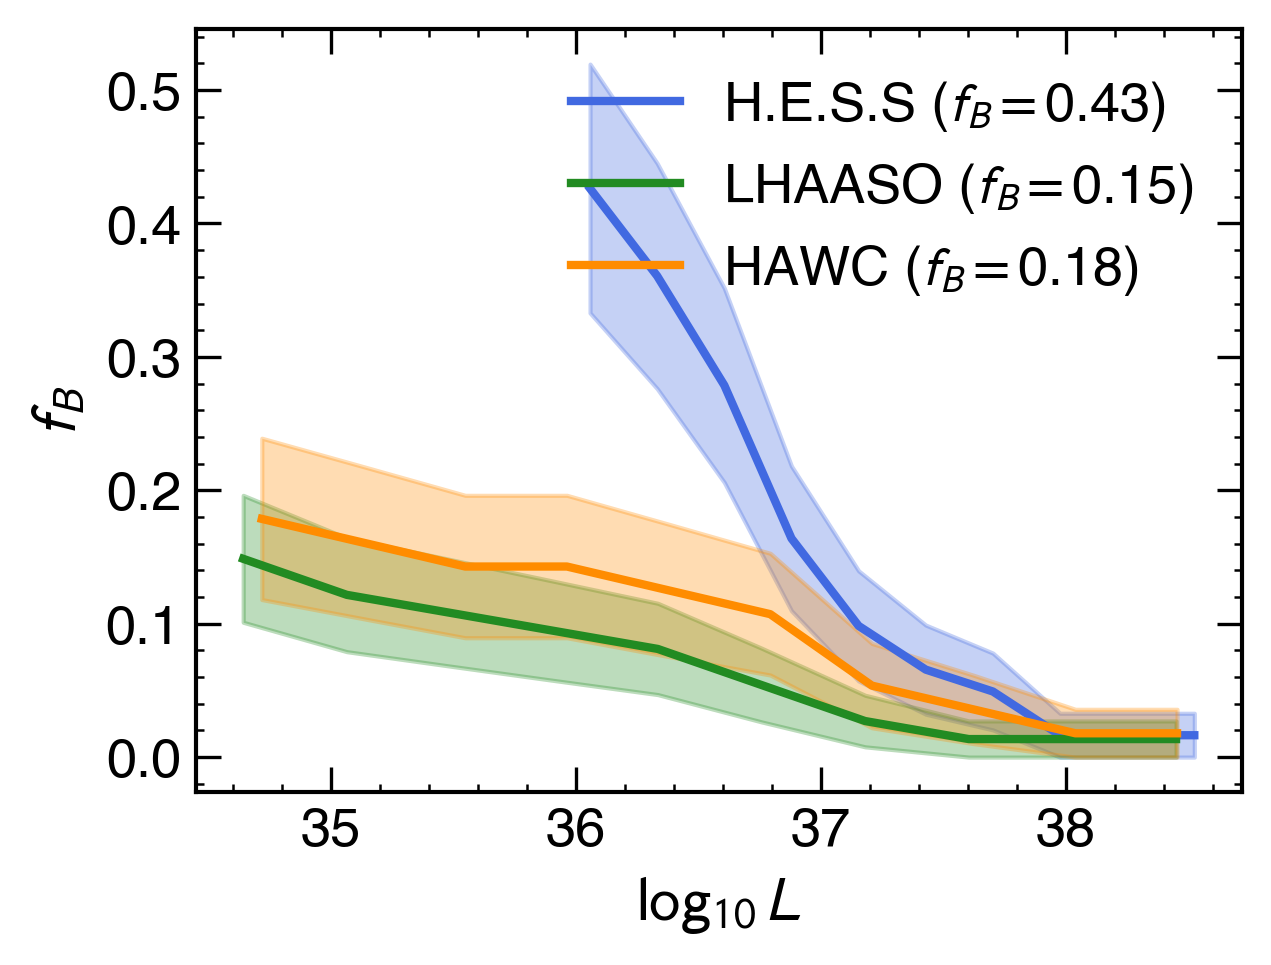

In [56]:
x, y, y_final, n_det, y_err, y_low, y_high = beaming_curve_cumulative(pwn_HESS_Edot, n_unid_region=n_unid_HESS, return_error=True)
plt.plot(x, y, label=r'H.E.S.S ($f_B = ${:.2f})'.format(y[0]), color='royalblue', linewidth=2)
plt.fill_between(x, y_low, y_high, color='royalblue', alpha=0.3)
# plt.fill_between(x, y_low, y_high, color='gray', alpha=0.3, step='post')
x_LHAASO, y_LHAASO, y_final_LHAASO, n_det_LHAASO, y_err_LHAASO, y_low_LHAASO, y_high_LHAASO = beaming_curve_cumulative(pwn_LHAASO_Edot, n_unid_region=n_unid_LHAASO, return_error=True)
plt.plot(x_LHAASO, y_LHAASO, label=r'LHAASO ($f_B = ${:.2f})'.format(y_LHAASO[0]), color='forestgreen', linewidth=2)
plt.fill_between(x_LHAASO, y_low_LHAASO, y_high_LHAASO, color='forestgreen', alpha=0.3)
x_HAWC, y_HAWC, y_final_HAWC, n_det_HAWC, y_err_HAWC, y_low_HAWC, y_high_HAWC = beaming_curve_cumulative(pwn_HAWC_Edot, n_unid_region=n_unid_HAWC, return_error=True)
plt.plot(x_HAWC, y_HAWC, label=r'HAWC ($f_B = ${:.2f})'.format(y_HAWC[0]), color='darkorange', linewidth=2)
plt.fill_between(x_HAWC, y_low_HAWC, y_high_HAWC, color='darkorange', alpha=0.3)
plt.xlabel(r'$\log_{10} L$')
plt.ylabel(r'$f_B$')
plt.legend()
plt.show()


In [108]:
pwn_HESS_radio = pwn_HESS[pwn_HESS['wavelength'].str.contains('radio', regex=False, na=False)]
pwn_HESS_gamma = pwn_HESS[pwn_HESS['wavelength'].str.contains('gamma', regex=False, na=False)]
pwn_HESS_x = pwn_HESS[pwn_HESS['wavelength'].str.contains('x-ray', regex=False, na=False)]
pwn_LHAASO_radio = pwn_LHAASO[pwn_LHAASO['wavelength'].str.contains('radio', regex=False, na=False)]
pwn_LHAASO_gamma = pwn_LHAASO[pwn_LHAASO['wavelength'].str.contains('gamma', regex=False, na=False)]
pwn_LHAASO_x = pwn_LHAASO[pwn_LHAASO['wavelength'].str.contains('x-ray', regex=False, na=False)]
pwn_HAWC_radio = pwn_HAWC[pwn_HAWC['wavelength'].str.contains('radio', regex=False, na=False)]
pwn_HAWC_gamma = pwn_HAWC[pwn_HAWC['wavelength'].str.contains('gamma', regex=False, na=False)]
pwn_HAWC_x = pwn_HAWC[pwn_HAWC['wavelength'].str.contains('x-ray', regex=False, na=False)]
pwn_HESS_radio_age = pwn_HESS_radio['tau_c_[kyr]'].dropna()
pwn_HESS_gamma_age = pwn_HESS_gamma['tau_c_[kyr]'].dropna()
pwn_HESS_x_age = pwn_HESS_x['tau_c_[kyr]'].dropna()
pwn_LHAASO_radio_age = pwn_LHAASO_radio['tau_c_[kyr]'].dropna()
pwn_LHAASO_gamma_age = pwn_LHAASO_gamma['tau_c_[kyr]'].dropna()
pwn_LHAASO_x_age = pwn_LHAASO_x['tau_c_[kyr]'].dropna()
pwn_HAWC_radio_age = pwn_HAWC_radio['tau_c_[kyr]'].dropna()
pwn_HAWC_gamma_age = pwn_HAWC_gamma['tau_c_[kyr]'].dropna()
pwn_HAWC_x_age = pwn_HAWC_x['tau_c_[kyr]'].dropna()
pwn_HESS_radio_Edot = pwn_HESS_radio['log10_Edot_[erg/s]'].dropna() 
pwn_HESS_gamma_Edot = pwn_HESS_gamma['log10_Edot_[erg/s]'].dropna() 
pwn_HESS_x_Edot = pwn_HESS_x['log10_Edot_[erg/s]'].dropna()
pwn_LHAASO_radio_Edot = pwn_LHAASO_radio['log10_Edot_[erg/s]'].dropna() 
pwn_LHAASO_gamma_Edot = pwn_LHAASO_gamma['log10_Edot_[erg/s]'].dropna() 
pwn_LHAASO_x_Edot = pwn_LHAASO_x['log10_Edot_[erg/s]'].dropna()
pwn_HAWC_radio_Edot = pwn_HAWC_radio['log10_Edot_[erg/s]'].dropna() 
pwn_HAWC_gamma_Edot = pwn_HAWC_gamma['log10_Edot_[erg/s]'].dropna() 
pwn_HAWC_x_Edot = pwn_HAWC_x['log10_Edot_[erg/s]'].dropna()
pwn_HESS_x_p = pwn_HESS_x[pwn_HESS_x['pulse'].str.contains('p', regex=False, na=False)]
pwn_HESS_x_p_age = pwn_HESS_x_p['tau_c_[kyr]'].dropna()
pwn_HESS_x_p_Edot = pwn_HESS_x_p['log10_Edot_[erg/s]'].dropna() 
pwn_HESS_x_p_l = pwn_HESS_x_p['l'].dropna()
pwn_HESS_x_p_b = pwn_HESS_x_p['b'].dropna()
pwn_LHAASO_x_p = pwn_LHAASO_x[pwn_LHAASO_x['pulse'].str.contains('p', regex=False, na=False)]
pwn_LHAASO_x_p_age = pwn_LHAASO_x_p['tau_c_[kyr]'].dropna()
pwn_LHAASO_x_p_Edot = pwn_LHAASO_x_p['log10_Edot_[erg/s]'].dropna()
pwn_LHAASO_x_p_l = pwn_LHAASO_x_p['l'].dropna()
pwn_LHAASO_x_p_b = pwn_LHAASO_x_p['b'].dropna()
pwn_HAWC_x_p = pwn_HAWC_x[pwn_HAWC_x['pulse'].str.contains('p', regex=False, na=False)]
pwn_HAWC_x_p_age = pwn_HAWC_x_p['tau_c_[kyr]'].dropna()
pwn_HAWC_x_p_Edot = pwn_HAWC_x_p['log10_Edot_[erg/s]'].dropna()
pwn_HAWC_x_p_l = pwn_HAWC_x_p['l'].dropna()
pwn_HAWC_x_p_b = pwn_HAWC_x_p['b'].dropna()




In [109]:
pwn_HESS_Edot.shape, pwn_HESS_radio_Edot.shape, pwn_HESS_gamma_Edot.shape, pwn_HESS_x_Edot.shape

((26,), (20,), (15,), (22,))

In [110]:
import numpy as np
import pandas as pd

wrap_lon_360 = lambda l: np.mod(l, 360.0)
mask_HESS   = lambda l, b: ((((0.0 <= wrap_lon_360(l)) & (wrap_lon_360(l) <= 77.5)) | ((244.5 <= wrap_lon_360(l)) & (wrap_lon_360(l) <= 360.0))) & (np.abs(b) <= 7.0))
mask_HAWC   = lambda l, b: ((((12.0 <= wrap_lon_360(l)) & (wrap_lon_360(l) <= 96.0)) | ((156.0 <= wrap_lon_360(l)) & (wrap_lon_360(l) <= 234.0))) & (np.abs(b) <= 4.0))
mask_LHAASO = lambda l, b: (((15.0 <= wrap_lon_360(l)) & (wrap_lon_360(l) <= 225.0)) & (np.abs(b) <= 5.0))

def to_num(s): return pd.to_numeric(s, errors='coerce')
def sdrop(df, col): return to_num(df[col]).dropna()
def apply_region_mask(df, survey_key):
    l, b = to_num(df['l']), to_num(df['b'])
    if survey_key == 'HESS':
        m = df['Survey'].str.contains('H.E.S.S.', regex=False, na=False) & mask_HESS(l, b)
    elif survey_key == 'HAWC':
        m = df['Survey'].str.contains('HAWC', regex=False, na=False) & mask_HAWC(l, b)
    elif survey_key == 'LHAASO':
        m = df['Survey'].str.contains('LHAASO', regex=False, na=False) & mask_LHAASO(l, b)
    else:
        raise ValueError("survey_key must be 'HESS', 'HAWC', or 'LHAASO'")
    return df.loc[m].copy().reset_index(drop=True)

def physical_size_pc(df, size_col, d_col='d_[kpc]'):
    size_deg, d_kpc = to_num(df[size_col]), to_num(df[d_col])
    psize = size_deg * d_kpc * np.pi / 180.0 * 1000.0
    return psize[(psize > 0) & np.isfinite(psize)]

# =========================
# PWN
# =========================
df_pwn = pd.read_csv('/Users/takumi/NS/PWN/csv/PWN_catalog.csv')

pwn_HESS   = apply_region_mask(df_pwn, 'HESS')
pwn_HAWC   = apply_region_mask(df_pwn, 'HAWC')
pwn_LHAASO = apply_region_mask(df_pwn, 'LHAASO')

pwn_HESS_age,   pwn_HAWC_age,   pwn_LHAASO_age   = sdrop(pwn_HESS,'tau_c_[kyr]'), sdrop(pwn_HAWC,'tau_c_[kyr]'), sdrop(pwn_LHAASO,'tau_c_[kyr]')
pwn_HESS_Edot,  pwn_HAWC_Edot,  pwn_LHAASO_Edot  = sdrop(pwn_HESS,'log10_Edot_[erg/s]'), sdrop(pwn_HAWC,'log10_Edot_[erg/s]'), sdrop(pwn_LHAASO,'log10_Edot_[erg/s]')
pwn_HESS_d,     pwn_HAWC_d,     pwn_LHAASO_d     = sdrop(pwn_HESS,'d_[kpc]'), sdrop(pwn_HAWC,'d_[kpc]'), sdrop(pwn_LHAASO,'d_[kpc]')
pwn_HESS_flux,  pwn_HAWC_flux,  pwn_LHAASO_flux  = sdrop(pwn_HESS,'Flux(cm-2 s-1 TeV-1)'), sdrop(pwn_HAWC,'Flux(cm-2 s-1 TeV-1)'), sdrop(pwn_LHAASO,'Flux(cm-2 s-1 TeV-1)')
pwn_HESS_flux_err, pwn_HAWC_flux_err, pwn_LHAASO_flux_err = sdrop(pwn_HESS,'Flux_error'), sdrop(pwn_HAWC,'Flux_error'), sdrop(pwn_LHAASO,'Flux_error')
pwn_HESS_index, pwn_HAWC_index, pwn_LHAASO_index = sdrop(pwn_HESS,'index'), sdrop(pwn_HAWC,'index'), sdrop(pwn_LHAASO,'index')
pwn_HESS_index_err, pwn_HAWC_index_err, pwn_LHAASO_index_err = sdrop(pwn_HESS,'index_error'), sdrop(pwn_HAWC,'index_error'), sdrop(pwn_LHAASO,'index_error')
pwn_HESS_pivot, pwn_HAWC_pivot, pwn_LHAASO_pivot = sdrop(pwn_HESS,'Pivot'), sdrop(pwn_HAWC,'Pivot'), sdrop(pwn_LHAASO,'Pivot')

pwn_flux, pwn_flux_err, pwn_index, pwn_index_err, pwn_d, pwn_pivot = sdrop(df_pwn,'Flux(cm-2 s-1 TeV-1)'), sdrop(df_pwn,'Flux_error'), sdrop(df_pwn,'index'), sdrop(df_pwn,'index_error'), sdrop(df_pwn,'d_[kpc]'), sdrop(df_pwn,'Pivot')

n_pwn_HESS, n_pwn_HAWC, n_pwn_LHAASO = len(pwn_HESS), len(pwn_HAWC), len(pwn_LHAASO)

pwn_l, pwn_b = sdrop(df_pwn,'l'), sdrop(df_pwn,'b')
pwn_HESS_l, pwn_HESS_b = sdrop(pwn_HESS,'l'), sdrop(pwn_HESS,'b')
pwn_HAWC_l, pwn_HAWC_b = sdrop(pwn_HAWC,'l'), sdrop(pwn_HAWC,'b')
pwn_LHAASO_l, pwn_LHAASO_b = sdrop(pwn_LHAASO,'l'), sdrop(pwn_LHAASO,'b')

pwn_size = to_num(df_pwn['size'])
pwn_HESS_size, pwn_HAWC_size, pwn_LHAASO_size = to_num(pwn_HESS['size']), to_num(pwn_HAWC['size']), to_num(pwn_LHAASO['size'])

pwn_HESS_psize   = physical_size_pc(pwn_HESS, 'size')
pwn_HAWC_psize   = physical_size_pc(pwn_HAWC, 'size')
pwn_LHAASO_psize = physical_size_pc(pwn_LHAASO, 'size')

# wavelengthで制限したPWN
pwn_HESS_radio   = pwn_HESS[pwn_HESS['wavelength'].str.contains('radio', regex=False, na=False)].copy()
pwn_HESS_gamma   = pwn_HESS[pwn_HESS['wavelength'].str.contains('gamma', regex=False, na=False)].copy()
pwn_HESS_x       = pwn_HESS[pwn_HESS['wavelength'].str.contains('x-ray', regex=False, na=False)].copy()

pwn_HAWC_radio   = pwn_HAWC[pwn_HAWC['wavelength'].str.contains('radio', regex=False, na=False)].copy()
pwn_HAWC_gamma   = pwn_HAWC[pwn_HAWC['wavelength'].str.contains('gamma', regex=False, na=False)].copy()
pwn_HAWC_x       = pwn_HAWC[pwn_HAWC['wavelength'].str.contains('x-ray', regex=False, na=False)].copy()

pwn_LHAASO_radio = pwn_LHAASO[pwn_LHAASO['wavelength'].str.contains('radio', regex=False, na=False)].copy()
pwn_LHAASO_gamma = pwn_LHAASO[pwn_LHAASO['wavelength'].str.contains('gamma', regex=False, na=False)].copy()
pwn_LHAASO_x     = pwn_LHAASO[pwn_LHAASO['wavelength'].str.contains('x-ray', regex=False, na=False)].copy()

pwn_HESS_radio_age,  pwn_HESS_gamma_age,  pwn_HESS_x_age  = sdrop(pwn_HESS_radio,'tau_c_[kyr]'), sdrop(pwn_HESS_gamma,'tau_c_[kyr]'), sdrop(pwn_HESS_x,'tau_c_[kyr]')
pwn_HAWC_radio_age,  pwn_HAWC_gamma_age,  pwn_HAWC_x_age  = sdrop(pwn_HAWC_radio,'tau_c_[kyr]'), sdrop(pwn_HAWC_gamma,'tau_c_[kyr]'), sdrop(pwn_HAWC_x,'tau_c_[kyr]')
pwn_LHAASO_radio_age,pwn_LHAASO_gamma_age,pwn_LHAASO_x_age= sdrop(pwn_LHAASO_radio,'tau_c_[kyr]'), sdrop(pwn_LHAASO_gamma,'tau_c_[kyr]'), sdrop(pwn_LHAASO_x,'tau_c_[kyr]')

pwn_HESS_radio_Edot,  pwn_HESS_gamma_Edot,  pwn_HESS_x_Edot  = sdrop(pwn_HESS_radio,'log10_Edot_[erg/s]'), sdrop(pwn_HESS_gamma,'log10_Edot_[erg/s]'), sdrop(pwn_HESS_x,'log10_Edot_[erg/s]')
pwn_HAWC_radio_Edot,  pwn_HAWC_gamma_Edot,  pwn_HAWC_x_Edot  = sdrop(pwn_HAWC_radio,'log10_Edot_[erg/s]'), sdrop(pwn_HAWC_gamma,'log10_Edot_[erg/s]'), sdrop(pwn_HAWC_x,'log10_Edot_[erg/s]')
pwn_LHAASO_radio_Edot,pwn_LHAASO_gamma_Edot,pwn_LHAASO_x_Edot= sdrop(pwn_LHAASO_radio,'log10_Edot_[erg/s]'), sdrop(pwn_LHAASO_gamma,'log10_Edot_[erg/s]'), sdrop(pwn_LHAASO_x,'log10_Edot_[erg/s]')

# =========================
# Unid
# =========================
df_unid = pd.read_csv('/Users/takumi/NS/PWN/csv/unid.csv')

df_unid_HESS   = apply_region_mask(df_unid, 'HESS')
df_unid_HAWC   = apply_region_mask(df_unid, 'HAWC')
df_unid_LHAASO = apply_region_mask(df_unid, 'LHAASO')

n_unid_HESS, n_unid_HAWC, n_unid_LHAASO = len(df_unid_HESS), len(df_unid_HAWC), len(df_unid_LHAASO)

unid_l, unid_b = sdrop(df_unid,'l'), sdrop(df_unid,'b')
unid_size = to_num(df_unid['size(deg)'])

unid_HESS_flux, unid_HAWC_flux, unid_LHAASO_flux = sdrop(df_unid_HESS,'Flux(cm-2 s-1 TeV-1)'), sdrop(df_unid_HAWC,'Flux(cm-2 s-1 TeV-1)'), sdrop(df_unid_LHAASO,'Flux(cm-2 s-1 TeV-1)')
unid_HESS_flux_err, unid_HAWC_flux_err, unid_LHAASO_flux_err = sdrop(df_unid_HESS,'Flux_error'), sdrop(df_unid_HAWC,'Flux_error'), sdrop(df_unid_LHAASO,'Flux_error')
unid_HESS_index, unid_HAWC_index, unid_LHAASO_index = sdrop(df_unid_HESS,'index'), sdrop(df_unid_HAWC,'index'), sdrop(df_unid_LHAASO,'index')
unid_HESS_index_err, unid_HAWC_index_err, unid_LHAASO_index_err = sdrop(df_unid_HESS,'index_error'), sdrop(df_unid_HAWC,'index_error'), sdrop(df_unid_LHAASO,'index_error')
unid_HESS_pivot, unid_HAWC_pivot, unid_LHAASO_pivot = sdrop(df_unid_HESS,'Pivot'), sdrop(df_unid_HAWC,'Pivot'), sdrop(df_unid_LHAASO,'Pivot')

unid_flux, unid_flux_err, unid_index, unid_index_err, unid_pivot = sdrop(df_unid,'Flux(cm-2 s-1 TeV-1)'), sdrop(df_unid,'Flux_error'), sdrop(df_unid,'index'), sdrop(df_unid,'index_error'), sdrop(df_unid,'Pivot')

unid_HESS_size, unid_HAWC_size, unid_LHAASO_size = to_num(df_unid_HESS['size(deg)']), to_num(df_unid_HAWC['size(deg)']), to_num(df_unid_LHAASO['size(deg)'])

# 確認用
print(f'n_pwn_HESS={n_pwn_HESS}, n_pwn_HAWC={n_pwn_HAWC}, n_pwn_LHAASO={n_pwn_LHAASO}')
print(f'n_unid_HESS={n_unid_HESS}, n_unid_HAWC={n_unid_HAWC}, n_unid_LHAASO={n_unid_LHAASO}')

n_pwn_HESS=25, n_pwn_HAWC=8, n_pwn_LHAASO=8
n_unid_HESS=35, n_unid_HAWC=44, n_unid_LHAASO=60


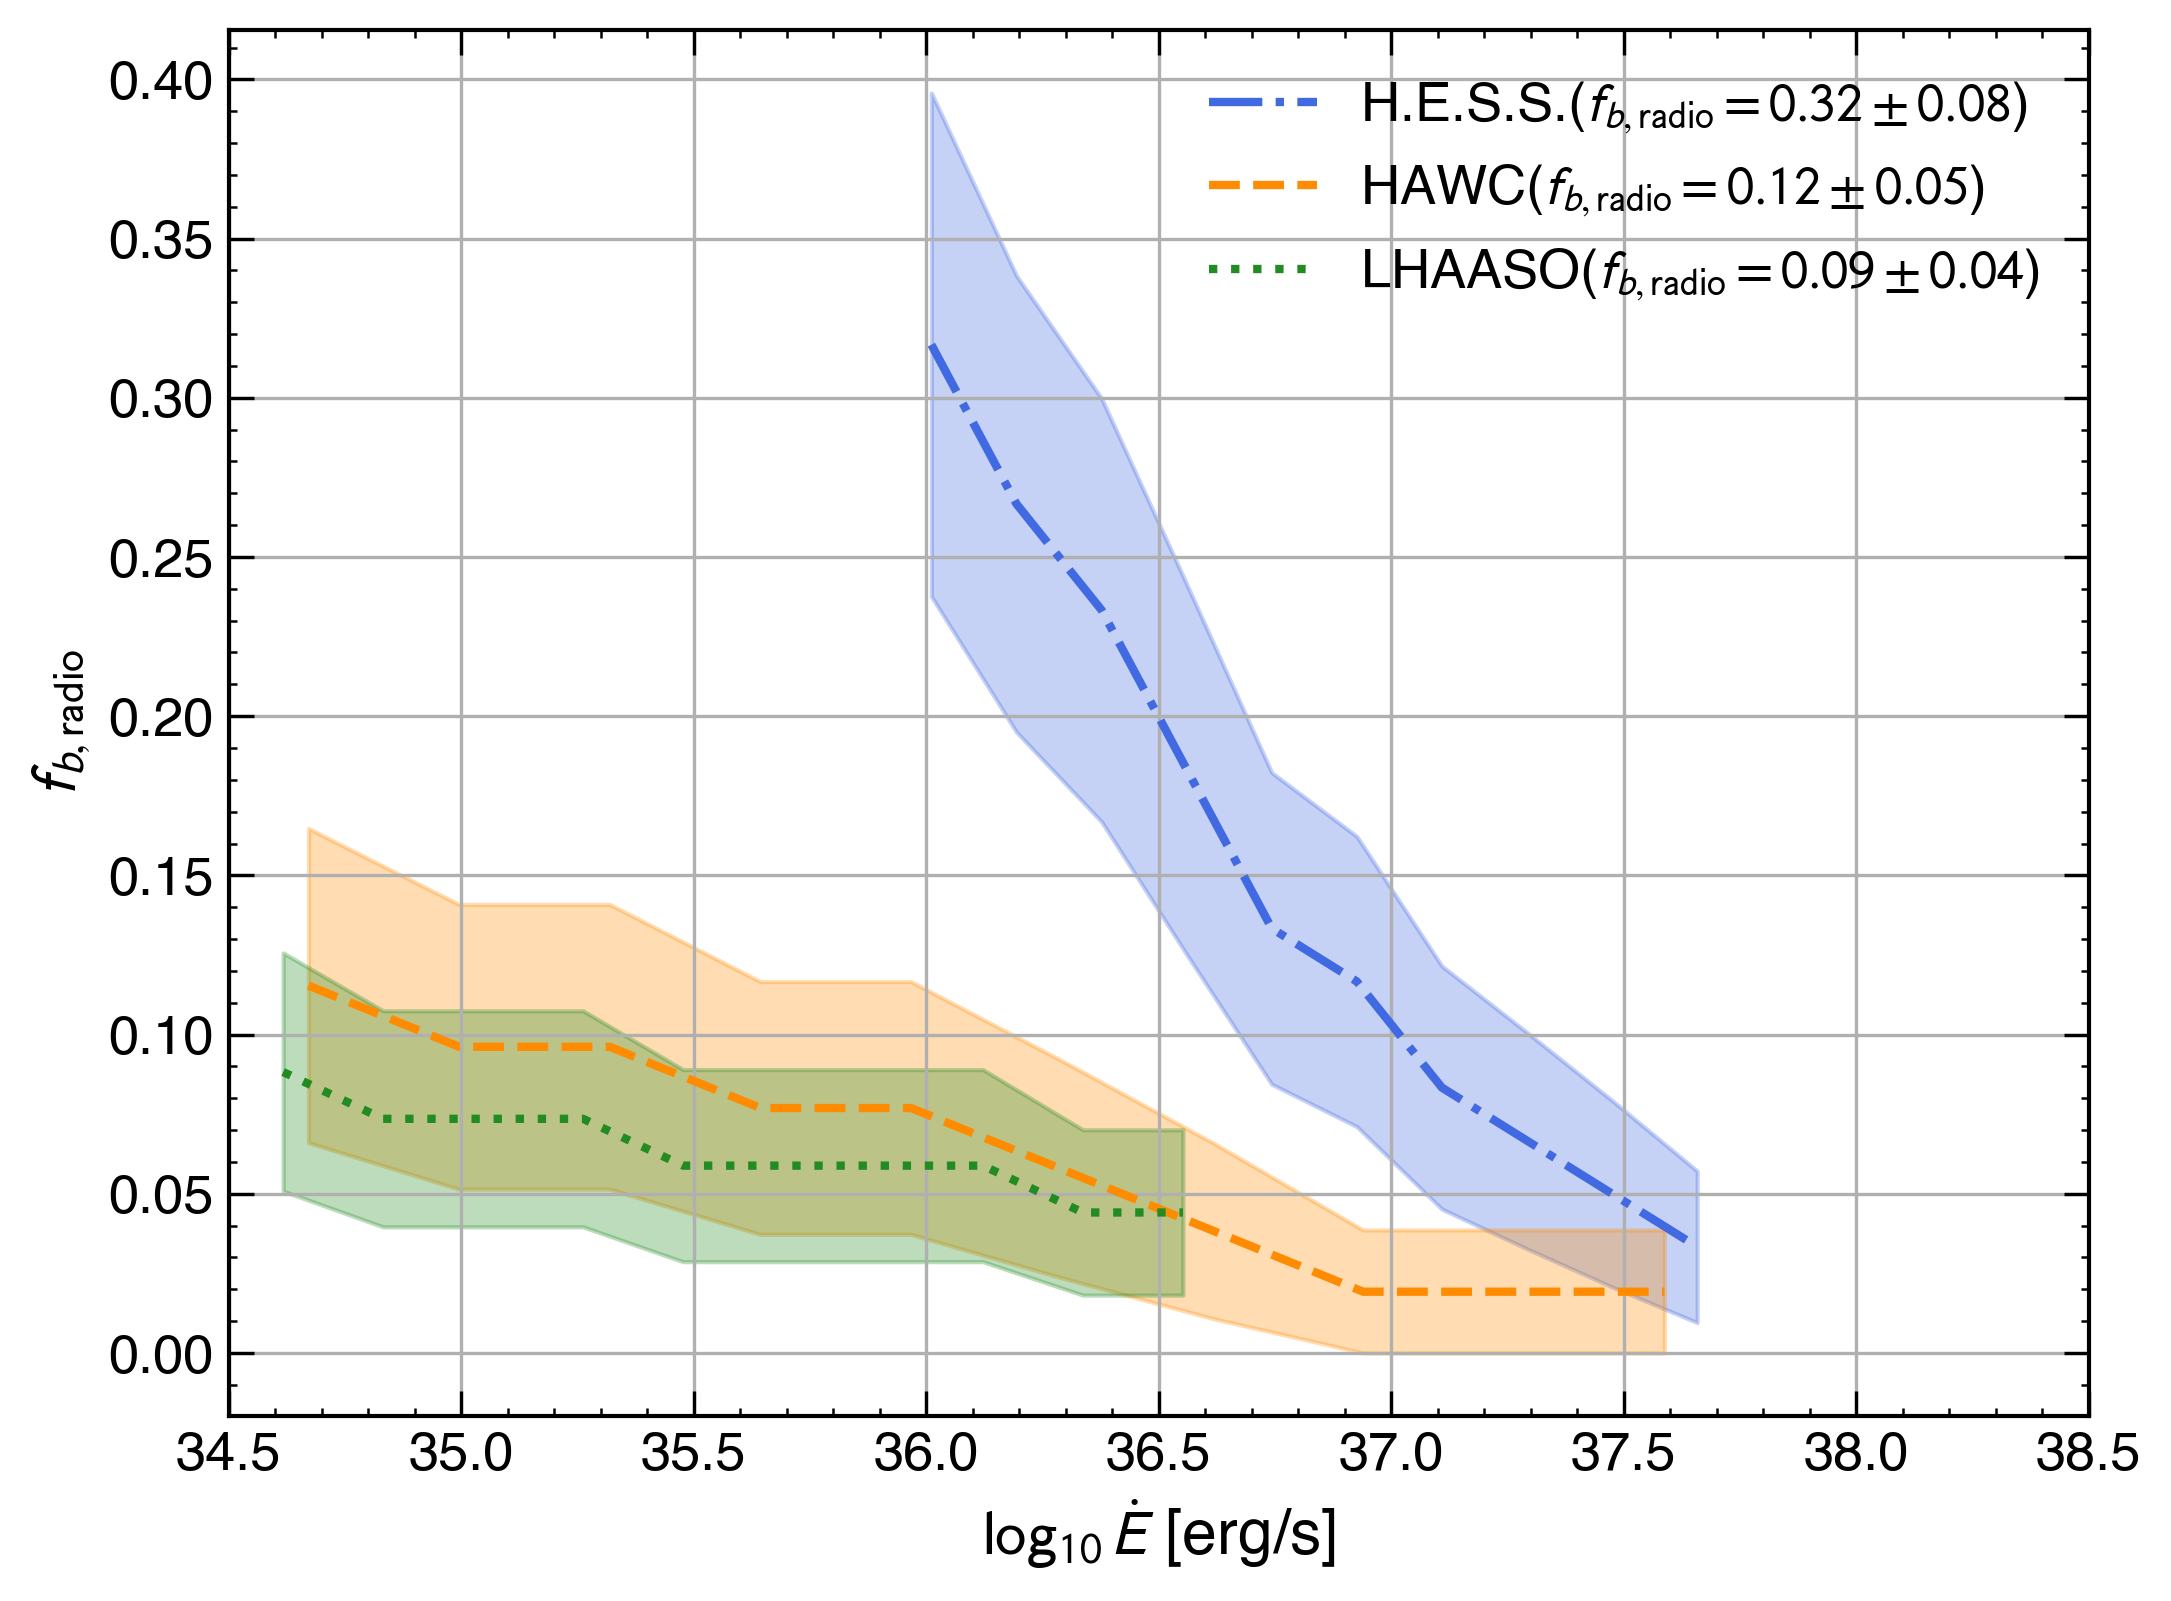

In [112]:
import numpy as np
import matplotlib.pyplot as plt

wrap_lon_360 = lambda l: np.mod(l, 360.0)
mask_HESS   = lambda l, b: ((((0.0 <= wrap_lon_360(l)) & (wrap_lon_360(l) <= 77.5)) | ((244.5 <= wrap_lon_360(l)) & (wrap_lon_360(l) <= 360.0))) & (np.abs(b) <= 7.0))
mask_HAWC   = lambda l, b: ((((12.0 <= wrap_lon_360(l)) & (wrap_lon_360(l) <= 96.0)) | ((156.0 <= wrap_lon_360(l)) & (wrap_lon_360(l) <= 234.0))) & (np.abs(b) <= 4.0))
mask_LHAASO = lambda l, b: (((15.0 <= wrap_lon_360(l)) & (wrap_lon_360(l) <= 225.0)) & (np.abs(b) <= 5.0))

m_HESS, m_HAWC, m_LHAASO = mask_HESS(pwn_HESS_l, pwn_HESS_b), mask_HAWC(pwn_HAWC_l, pwn_HAWC_b), mask_LHAASO(pwn_LHAASO_l, pwn_LHAASO_b)
m_HESS_p, m_HAWC_p, m_LHAASO_p = mask_HESS(pwn_HESS_x_p_l, pwn_HESS_x_p_b), mask_HAWC(pwn_HAWC_x_p_l, pwn_HAWC_x_p_b), mask_LHAASO(pwn_LHAASO_x_p_l, pwn_LHAASO_x_p_b)

x_HESS_Edot_radio, y_HESS_Edot_radio, f_HESS_radio, n_det_HESS_radio, y_err_HESS_radio, y_low_HESS_radio, y_high_HESS_radio = beaming_curve_cumulative(pwn_HESS_Edot[m_HESS], n_unid_region=n_unid_HESS, logL_nu=pwn_HESS_radio_Edot[m_HESS], return_error=True)
x_HESS_Edot_gamma, y_HESS_Edot_gamma, f_HESS_gamma, n_det_HESS_gamma, y_err_HESS_gamma, y_low_HESS_gamma, y_high_HESS_gamma = beaming_curve_cumulative(pwn_HESS_Edot[m_HESS], n_unid_region=n_unid_HESS, logL_nu=pwn_HESS_gamma_Edot[m_HESS], return_error=True)
x_HESS_Edot_x, y_HESS_Edot_x, f_HESS_x, n_det_HESS_x, y_err_HESS_x, y_low_HESS_x, y_high_HESS_x = beaming_curve_cumulative(pwn_HESS_Edot[m_HESS], n_unid_region=n_unid_HESS, logL_nu=pwn_HESS_x_Edot[m_HESS], return_error=True)
x_HAWC_Edot_radio, y_HAWC_Edot_radio, f_HAWC_radio, n_det_HAWC_radio, y_err_HAWC_radio, y_low_HAWC_radio, y_high_HAWC_radio = beaming_curve_cumulative(pwn_HAWC_Edot[m_HAWC], n_unid_region=n_unid_HAWC, logL_nu=pwn_HAWC_radio_Edot[m_HAWC], return_error=True)
x_HAWC_Edot_gamma, y_HAWC_Edot_gamma, f_HAWC_gamma, n_det_HAWC_gamma, y_err_HAWC_gamma, y_low_HAWC_gamma, y_high_HAWC_gamma = beaming_curve_cumulative(pwn_HAWC_Edot[m_HAWC], n_unid_region=n_unid_HAWC, logL_nu=pwn_HAWC_gamma_Edot[m_HAWC], return_error=True)
x_HAWC_Edot_x, y_HAWC_Edot_x, f_HAWC_x, n_det_HAWC_x, y_err_HAWC_x, y_low_HAWC_x, y_high_HAWC_x = beaming_curve_cumulative(pwn_HAWC_Edot[m_HAWC], n_unid_region=n_unid_HAWC, logL_nu=pwn_HAWC_x_Edot[m_HAWC], return_error=True)
x_LHAASO_Edot_radio, y_LHAASO_Edot_radio, f_LHAASO_radio, n_det_LHAASO_radio, y_err_LHAASO_radio, y_low_LHAASO_radio, y_high_LHAASO_radio = beaming_curve_cumulative(pwn_LHAASO_Edot[m_LHAASO], n_unid_region=n_unid_LHAASO, logL_nu=pwn_LHAASO_radio_Edot[m_LHAASO], return_error=True)
x_LHAASO_Edot_gamma, y_LHAASO_Edot_gamma, f_LHAASO_gamma, n_det_LHAASO_gamma, y_err_LHAASO_gamma, y_low_LHAASO_gamma, y_high_LHAASO_gamma = beaming_curve_cumulative(pwn_LHAASO_Edot[m_LHAASO], n_unid_region=n_unid_LHAASO, logL_nu=pwn_LHAASO_gamma_Edot[m_LHAASO], return_error=True)
x_LHAASO_Edot_x, y_LHAASO_Edot_x, f_LHAASO_x, n_det_LHAASO_x, y_err_LHAASO_x, y_low_LHAASO_x, y_high_LHAASO_x = beaming_curve_cumulative(pwn_LHAASO_Edot[m_LHAASO], n_unid_region=n_unid_LHAASO, logL_nu=pwn_LHAASO_x_Edot[m_LHAASO], return_error=True)
x_HESS_Edot_x_p, y_HESS_Edot_x_p, f_HESS_x_p, n_det_HESS_x_p, y_err_HESS_x_p, y_low_HESS_x_p, y_high_HESS_x_p = beaming_curve_cumulative(pwn_HESS_Edot[m_HESS], n_unid_region=n_unid_HESS, logL_nu=pwn_HESS_x_p_Edot[m_HESS_p], return_error=True)
x_HAWC_Edot_x_p, y_HAWC_Edot_x_p, f_HAWC_x_p, n_det_HAWC_x_p, y_err_HAWC_x_p, y_low_HAWC_x_p, y_high_HAWC_x_p = beaming_curve_cumulative(pwn_HAWC_Edot[m_HAWC], n_unid_region=n_unid_HAWC, logL_nu=pwn_HAWC_x_p_Edot[m_HAWC_p], return_error=True)
x_LHAASO_Edot_x_p, y_LHAASO_Edot_x_p, f_LHAASO_x_p, n_det_LHAASO_x_p, y_err_LHAASO_x_p, y_low_LHAASO_x_p, y_high_LHAASO_x_p = beaming_curve_cumulative(pwn_LHAASO_Edot[m_LHAASO], n_unid_region=n_unid_LHAASO, logL_nu=pwn_LHAASO_x_p_Edot[m_LHAASO_p], return_error=True)

plt.figure(figsize=(8,6))
plt.plot(x_HESS_Edot_radio, y_HESS_Edot_radio, label=r'H.E.S.S.($f_{{b,\mathrm{{radio}}}} = {:.2f}\pm{:.2f}$)'.format(y_HESS_Edot_radio[0], y_err_HESS_radio[0]), color='royalblue', linewidth=2, linestyle='dashdot'); plt.fill_between(x_HESS_Edot_radio, y_low_HESS_radio, y_high_HESS_radio, color='royalblue', alpha=0.3)
plt.plot(x_HAWC_Edot_radio, y_HAWC_Edot_radio, label=r'HAWC($f_{{b,\mathrm{{radio}}}} = {:.2f}\pm{:.2f}$)'.format(y_HAWC_Edot_radio[0], y_err_HAWC_radio[0]), color='darkorange', linewidth=2, linestyle='dashed'); plt.fill_between(x_HAWC_Edot_radio, y_low_HAWC_radio, y_high_HAWC_radio, color='darkorange', alpha=0.3)
plt.plot(x_LHAASO_Edot_radio, y_LHAASO_Edot_radio, label=r'LHAASO($f_{{b,\mathrm{{radio}}}} = {:.2f}\pm{:.2f}$)'.format(y_LHAASO_Edot_radio[0], y_err_LHAASO_radio[0]), color='forestgreen', linewidth=2, linestyle='dotted'); plt.fill_between(x_LHAASO_Edot_radio, y_low_LHAASO_radio, y_high_LHAASO_radio, color='forestgreen', alpha=0.3)
plt.xlabel(r'$\log_{10} \dot{E}$ [erg/s]'); plt.ylabel(r'$f_{b,\mathrm{radio}}$'); plt.legend(frameon=False, loc='best'); plt.xlim(34.5, 38.5); plt.grid(); plt.savefig('/Users/takumi/NS/Figure/beaming_fraction_Edot_radio.pdf', bbox_inches='tight', pad_inches=0.1)
plt.savefig('/Users/takumi/NS/Figure/beaming_fraction_Edot_radio.pdf', bbox_inches='tight', pad_inches=0.1)

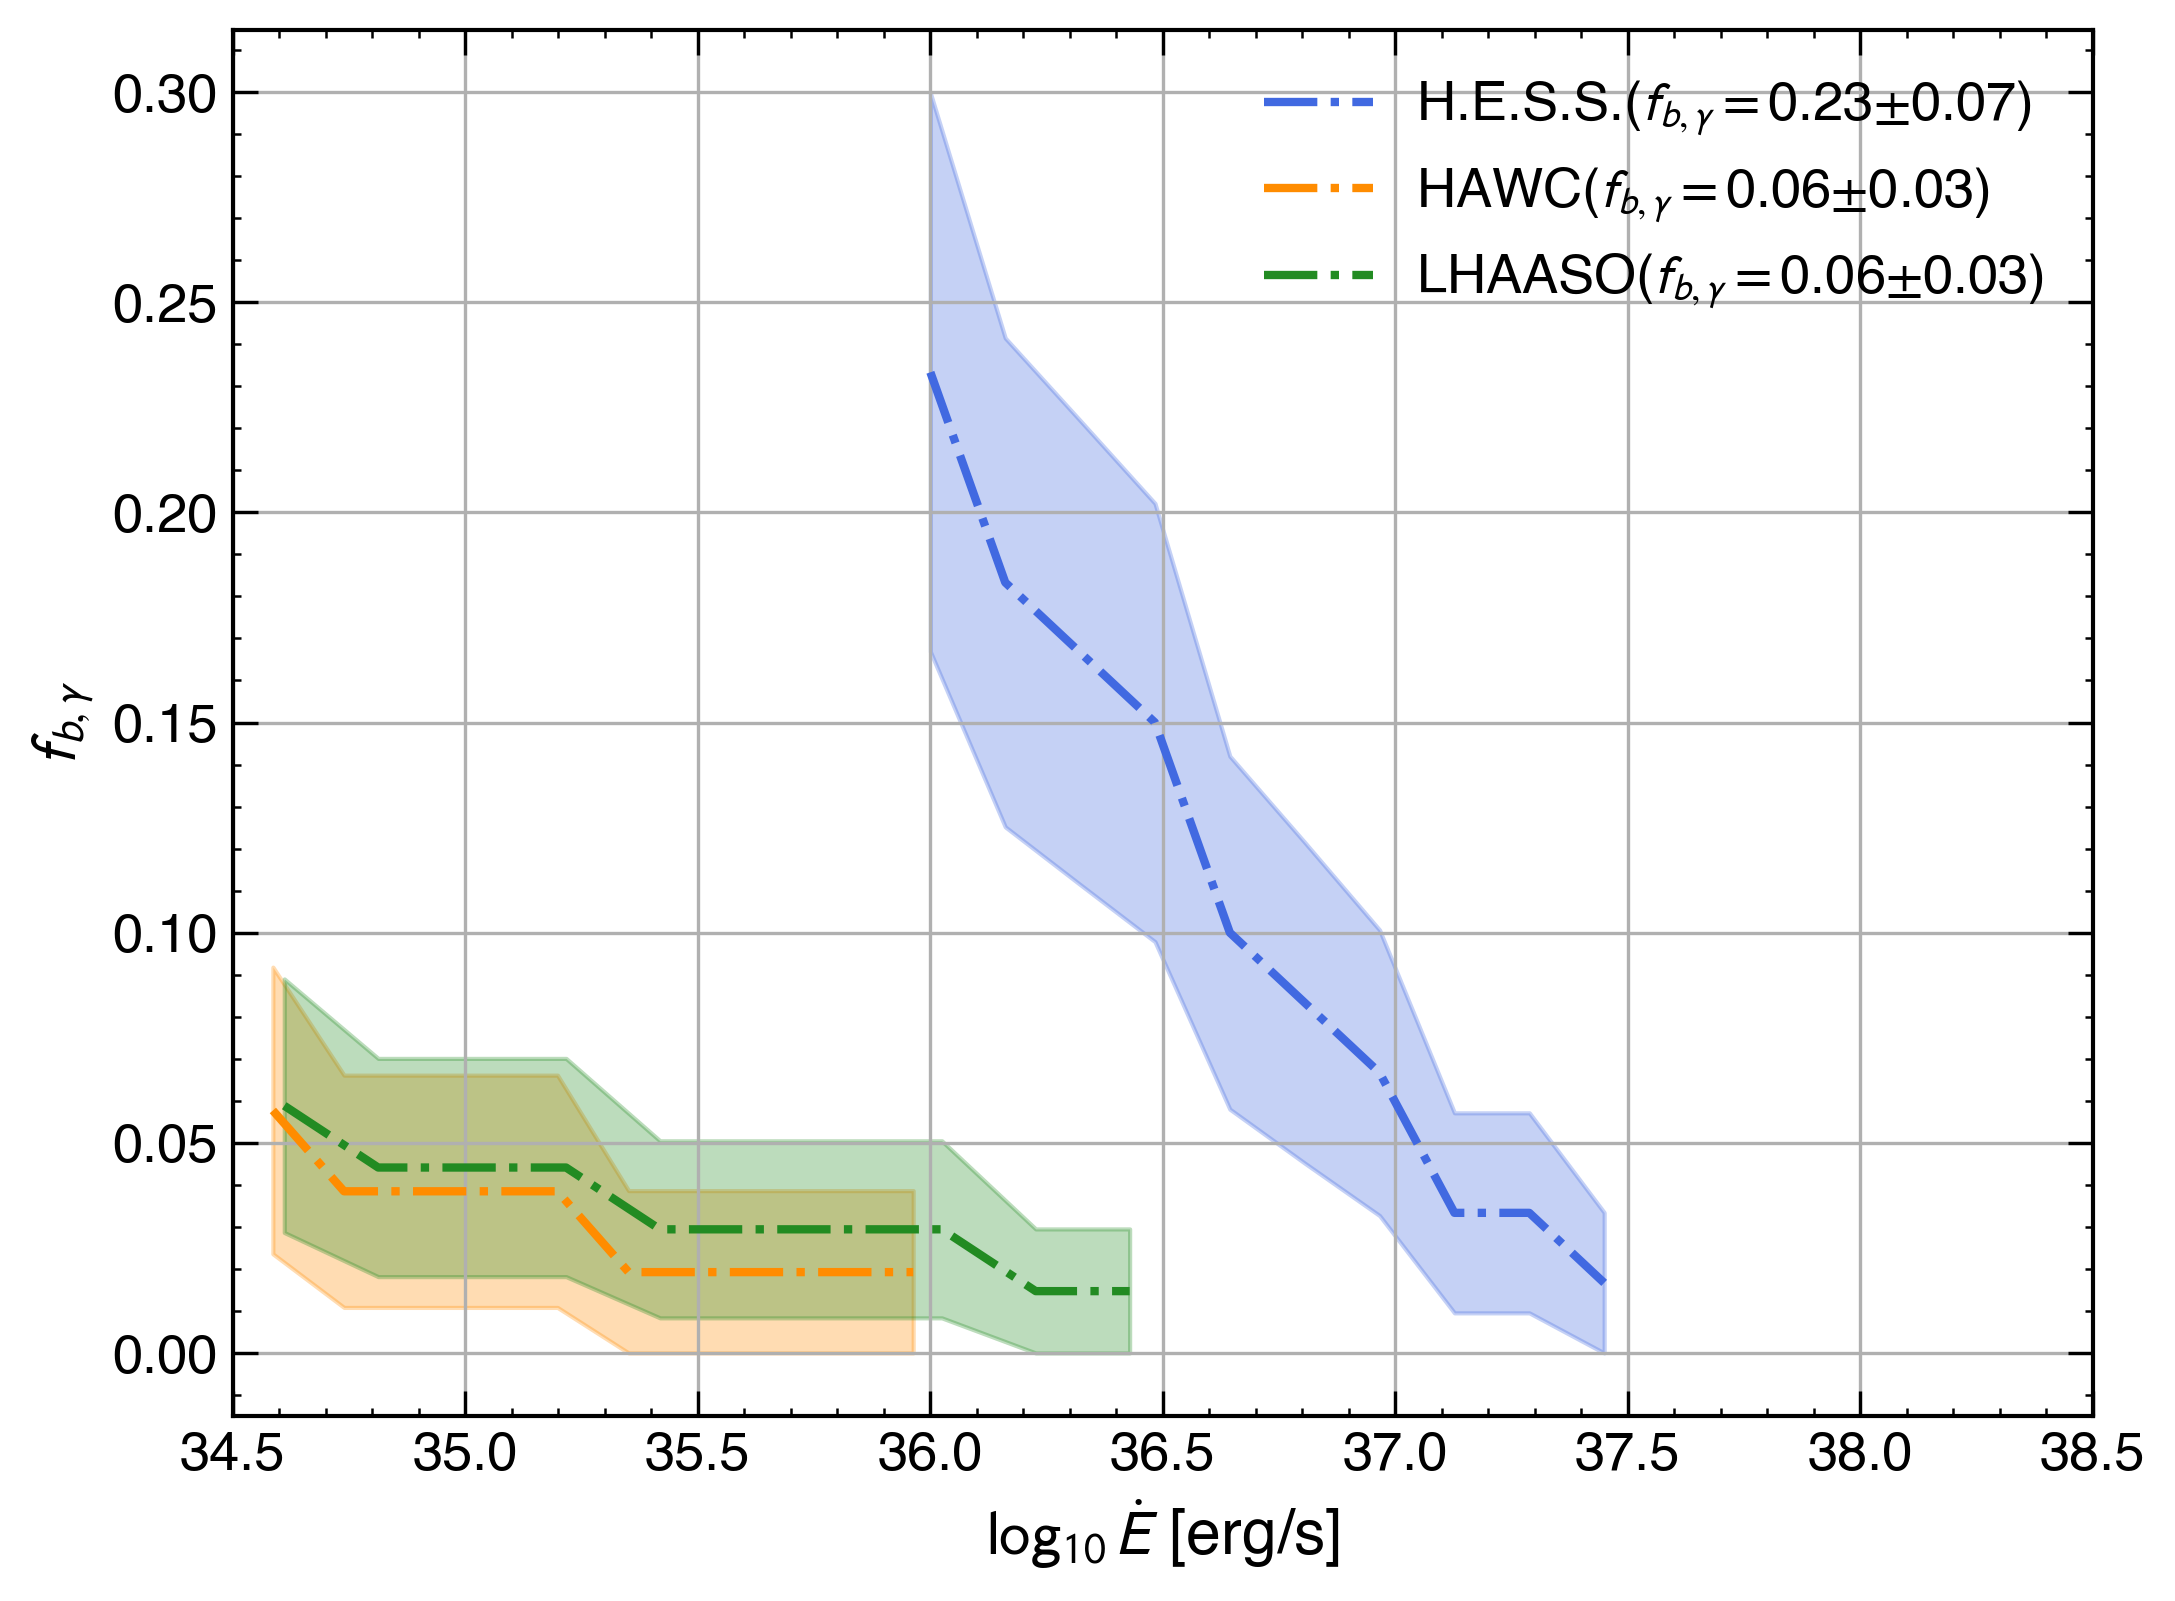

In [75]:
plt.figure(figsize=(8,6 ))
plt.plot(x_HESS_Edot_gamma, y_HESS_Edot_gamma, label=r'H.E.S.S.($f_{{{{b,\gamma}}}} = ${:.2f}$\pm${:.2f})'.format(y_HESS_Edot_gamma[0], y_err_HESS_gamma[0]), color='royalblue', linewidth=2, linestyle='dashdot')
plt.fill_between(x_HESS_Edot_gamma, y_low_HESS_gamma, y_high_HESS_gamma, color='royalblue', alpha=0.3)
plt.plot(x_HAWC_Edot_gamma, y_HAWC_Edot_gamma, label=r'HAWC($f_{{{{b,\gamma}}}} = ${:.2f}$\pm${:.2f})'.format(y_HAWC_Edot_gamma[0], y_err_HAWC_gamma[0]), color='darkorange', linewidth=2, linestyle='dashdot')
plt.fill_between(x_HAWC_Edot_gamma, y_low_HAWC_gamma, y_high_HAWC_gamma, color='darkorange', alpha=0.3)
plt.plot(x_LHAASO_Edot_gamma, y_LHAASO_Edot_gamma, label=r'LHAASO($f_{{{{b,\gamma}}}} = ${:.2f}$\pm${:.2f})'.format(y_LHAASO_Edot_gamma[0], y_err_LHAASO_gamma[0]), color='forestgreen', linewidth=2, linestyle='dashdot')
plt.fill_between(x_LHAASO_Edot_gamma, y_low_LHAASO_gamma, y_high_LHAASO_gamma, color='forestgreen', alpha=0.3)
plt.xlabel(r'$\log_{10} \dot{E}$ [erg/s]')
plt.ylabel(r'$f_{b,\gamma}$')
plt.legend(frameon=False, loc='best')
plt.xlim(34.5, 38.5)
plt.grid()
plt.savefig('/Users/takumi/NS/Figure/beaming_fraction_Edot_gamma.pdf', bbox_inches='tight', pad_inches=0.1)

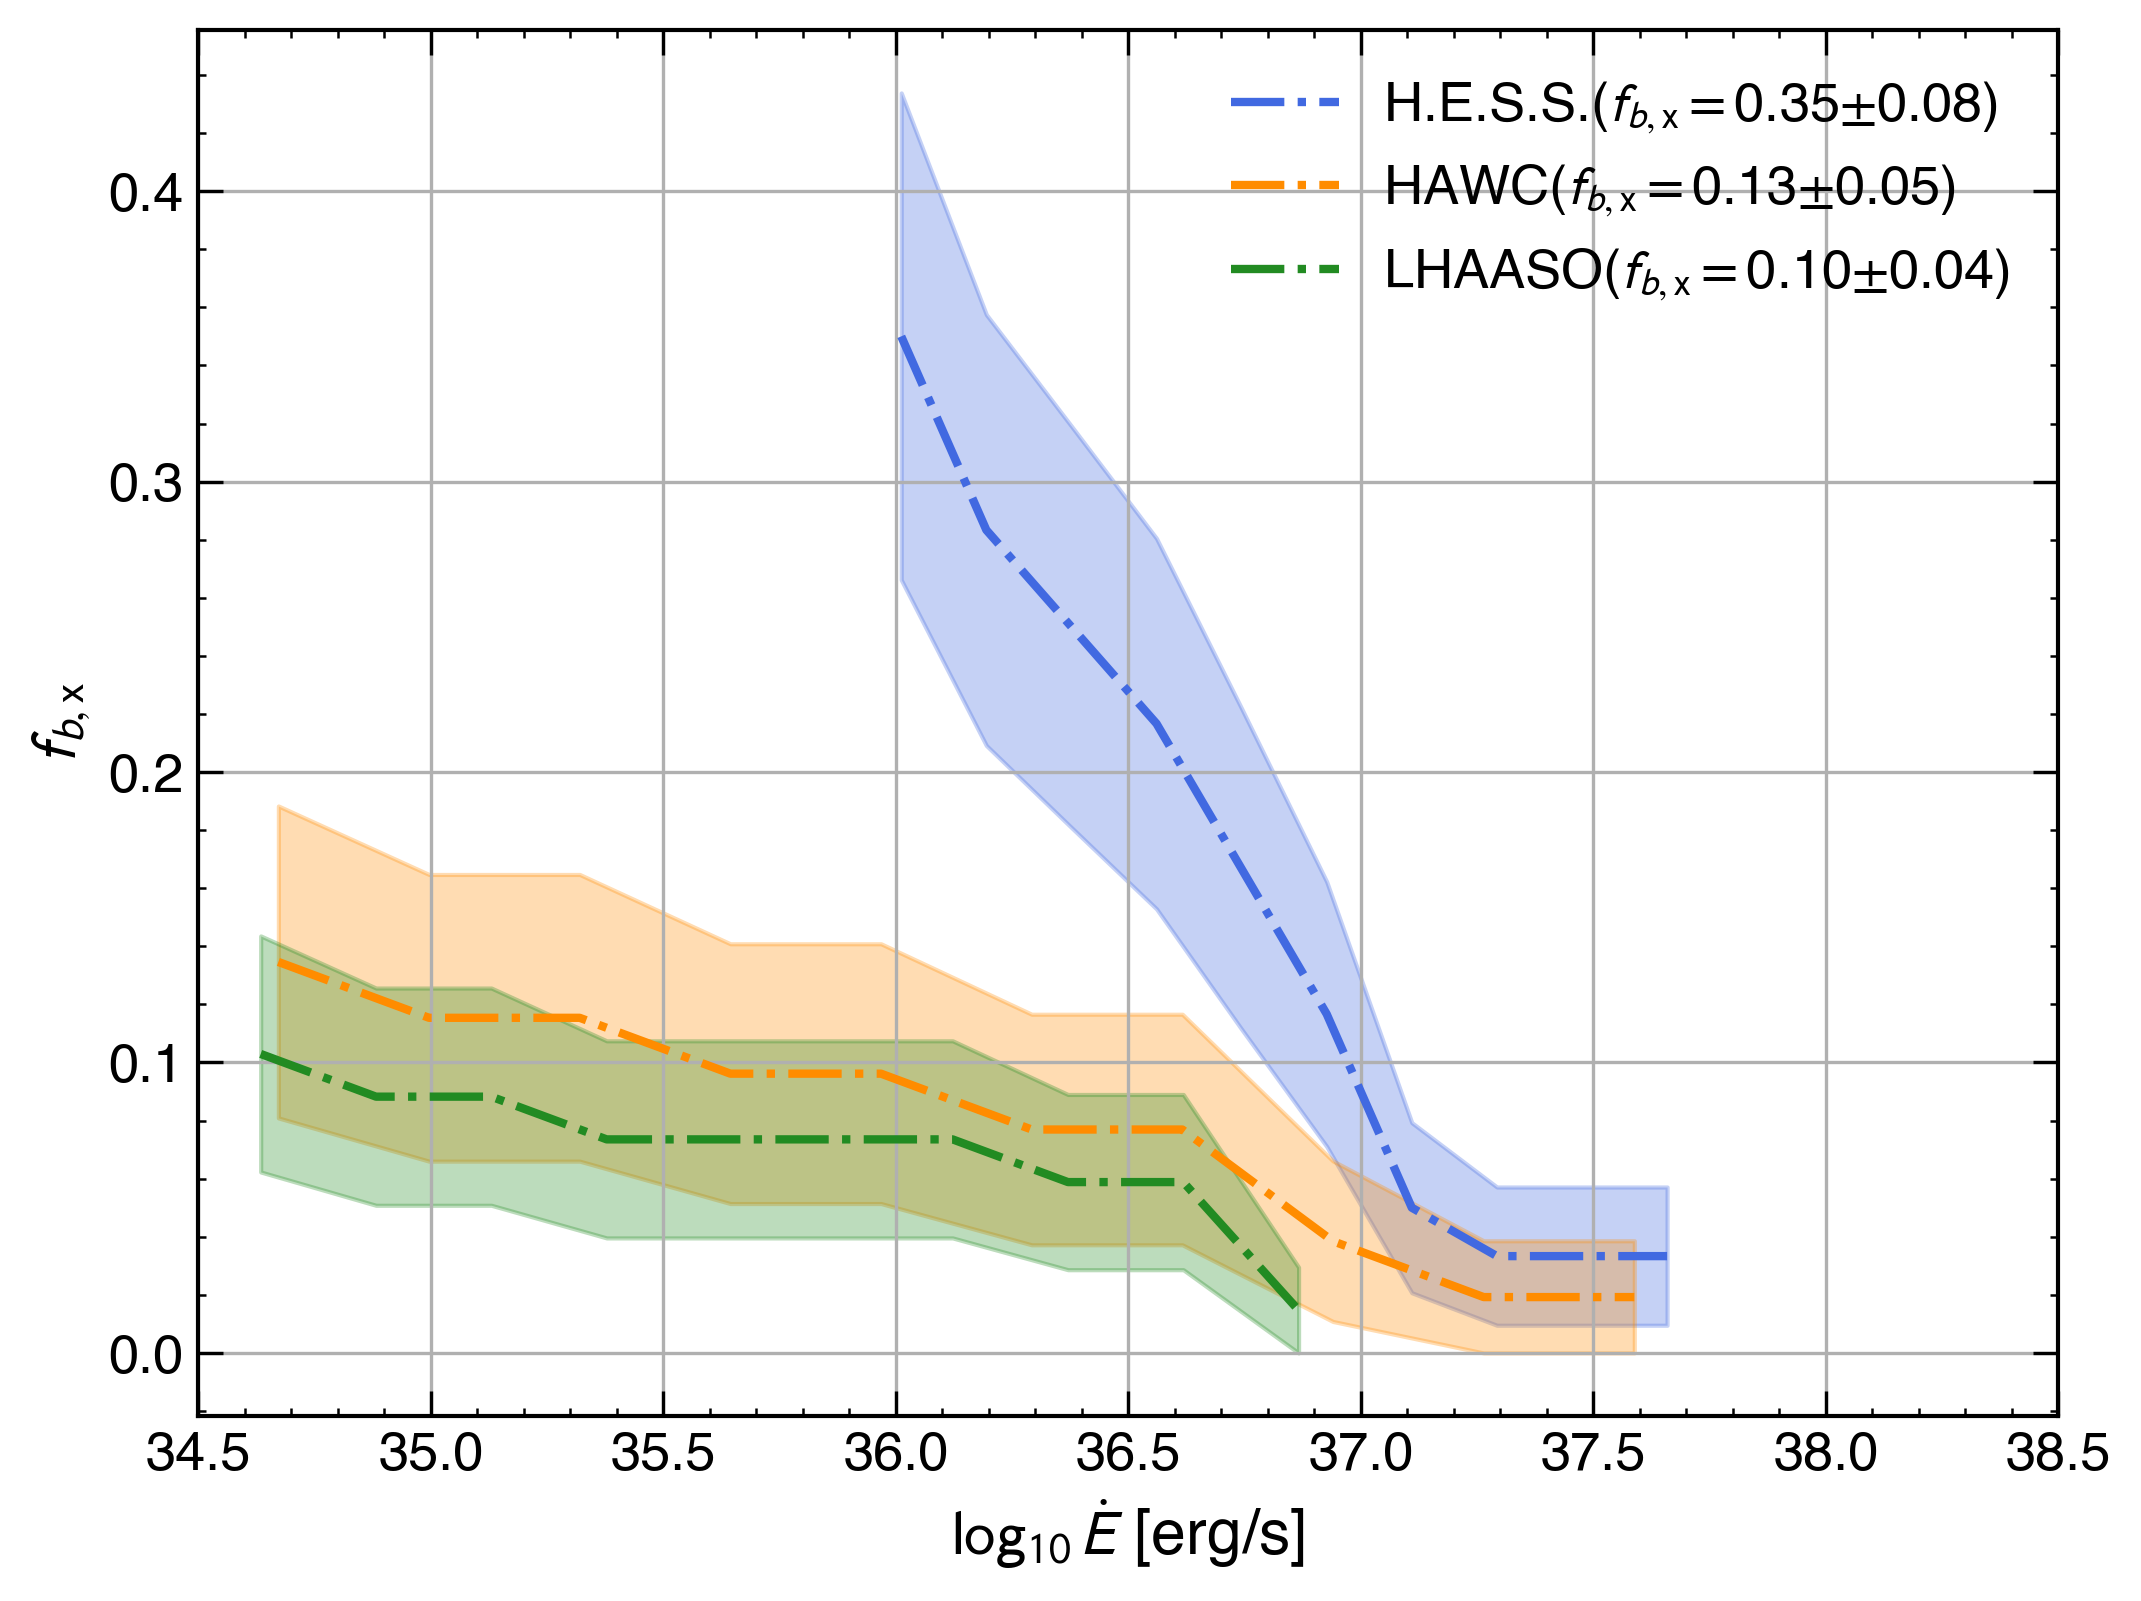

In [96]:
plt.figure(figsize=(8,6 ))
plt.plot(x_HESS_Edot_x, y_HESS_Edot_x, label=r'H.E.S.S.($f_{{{{b, \mathrm{{{{x}}}}}}}} = ${:.2f}$\pm${:.2f})'.format(y_HESS_Edot_x[0], y_err_HESS_x[0]), color='royalblue', linewidth=2, linestyle='dashdot')
plt.fill_between(x_HESS_Edot_x, y_low_HESS_x, y_high_HESS_x, color='royalblue', alpha=0.3)
plt.plot(x_HAWC_Edot_x, y_HAWC_Edot_x, label=r'HAWC($f_{{{{b, \mathrm{{{{x}}}}}}}} = ${:.2f}$\pm${:.2f})'.format(y_HAWC_Edot_x[0], y_err_HAWC_x[0]), color='darkorange', linewidth=2, linestyle='dashdot')
plt.fill_between(x_HAWC_Edot_x, y_low_HAWC_x, y_high_HAWC_x, color='darkorange', alpha=0.3)
plt.plot(x_LHAASO_Edot_x, y_LHAASO_Edot_x, label=r'LHAASO($f_{{{{b, \mathrm{{{{x}}}}}}}} = ${:.2f}$\pm${:.2f})'.format(y_LHAASO_Edot_x[0], y_err_LHAASO_x[0]), color='forestgreen', linewidth=2, linestyle='dashdot')
plt.fill_between(x_LHAASO_Edot_x, y_low_LHAASO_x, y_high_LHAASO_x, color='forestgreen', alpha=0.3)
# plt.plot(x_HESS_Edot_x_p, y_HESS_Edot_x_p, label=r'H.E.S.S.($f_{{{{b, \mathrm{{{{x,p}}}}}}}} = ${:.2f}$\pm${:.2f})'.format(y_HESS_Edot_x_p[0], y_err_HESS_x_p[0]), color='royalblue', linewidth=2, linestyle='dashed')
# plt.fill_between(x_HESS_Edot_x_p, y_low_HESS_x_p, y_high_HESS_x_p, color='royalblue', alpha=0.3)
# plt.plot(x_HAWC_Edot_x_p, y_HAWC_Edot_x_p, label=r'HAWC($f_{{{{b, \mathrm{{{{x,p}}}}}}}} = ${:.2f}$\pm${:.2f})'.format(y_HAWC_Edot_x_p[0], y_err_HAWC_x_p[0]), color='darkorange', linewidth=2, linestyle='dashed')
# plt.fill_between(x_HAWC_Edot_x_p, y_low_HAWC_x_p, y_high_HAWC_x_p, color='darkorange', alpha=0.3)
# plt.plot(x_LHAASO_Edot_x_p, y_LHAASO_Edot_x_p, label=r'LHAASO($f_{{{{b, \mathrm{{{{x,p}}}}}}}} = ${:.2f}$\pm${:.2f})'.format(y_LHAASO_Edot_x_p[0], y_err_LHAASO_x_p[0]), color='forestgreen', linewidth=2, linestyle='dashed')
# plt.fill_between(x_LHAASO_Edot_x_p, y_low_LHAASO_x_p, y_high_LHAASO_x_p, color='forestgreen', alpha=0.3)
plt.xlabel(r'$\log_{10} \dot{E}$ [erg/s]')
plt.ylabel(r'$f_{b,\mathrm{x}}$')
plt.legend(frameon=False, loc='best')
plt.xlim(34.5, 38.5)
plt.grid()
plt.savefig('/Users/takumi/NS/Figure/beaming_fraction_Edot_x.pdf', bbox_inches='tight', pad_inches=0.1)

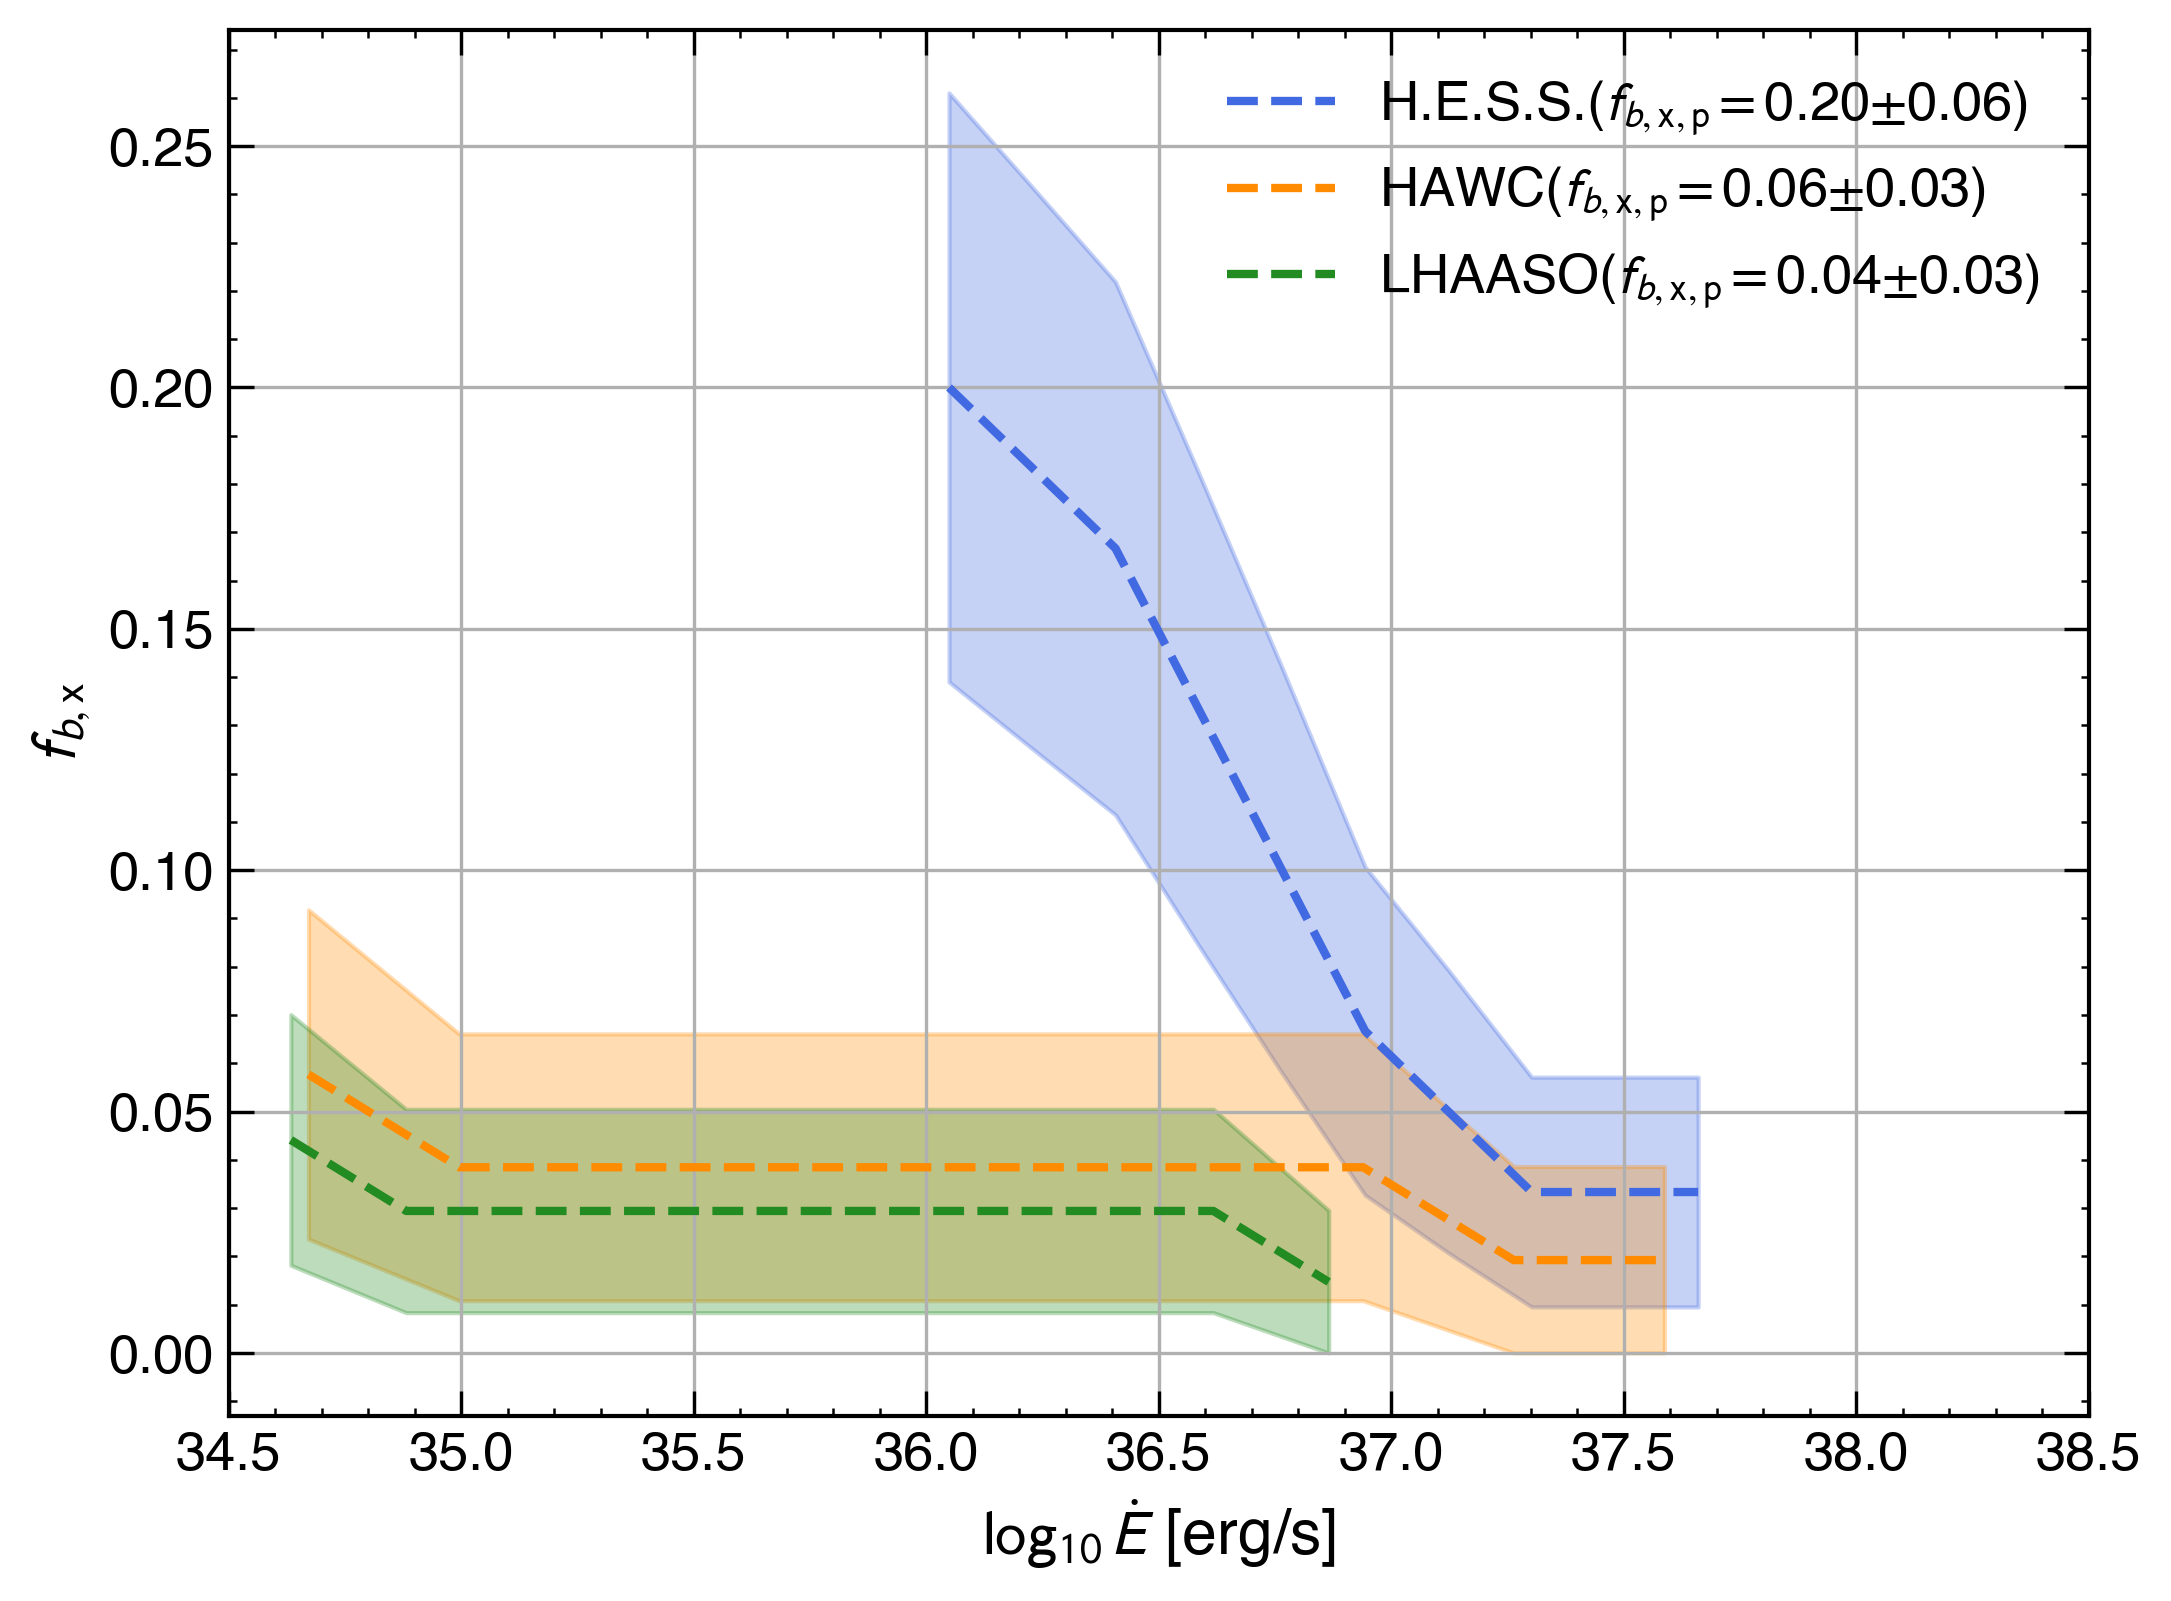

In [115]:
plt.figure(figsize=(8,6 ))
plt.plot(x_HESS_Edot_x_p, y_HESS_Edot_x_p, label=r'H.E.S.S.($f_{{{{b, \mathrm{{{{x,p}}}}}}}} = ${:.2f}$\pm${:.2f})'.format(y_HESS_Edot_x_p[0], y_err_HESS_x_p[0]), color='royalblue', linewidth=2, linestyle='dashed')
plt.fill_between(x_HESS_Edot_x_p, y_low_HESS_x_p, y_high_HESS_x_p, color='royalblue', alpha=0.3)
plt.plot(x_HAWC_Edot_x_p, y_HAWC_Edot_x_p, label=r'HAWC($f_{{{{b, \mathrm{{{{x,p}}}}}}}} = ${:.2f}$\pm${:.2f})'.format(y_HAWC_Edot_x_p[0], y_err_HAWC_x_p[0]), color='darkorange', linewidth=2, linestyle='dashed')
plt.fill_between(x_HAWC_Edot_x_p, y_low_HAWC_x_p, y_high_HAWC_x_p, color='darkorange', alpha=0.3)
plt.plot(x_LHAASO_Edot_x_p, y_LHAASO_Edot_x_p, label=r'LHAASO($f_{{{{b, \mathrm{{{{x,p}}}}}}}} = ${:.2f}$\pm${:.2f})'.format(y_LHAASO_Edot_x_p[0], y_err_LHAASO_x_p[0]), color='forestgreen', linewidth=2, linestyle='dashed')
plt.fill_between(x_LHAASO_Edot_x_p, y_low_LHAASO_x_p, y_high_LHAASO_x_p, color='forestgreen', alpha=0.3)
plt.xlabel(r'$\log_{10} \dot{E}$ [erg/s]')
plt.ylabel(r'$f_{b,\mathrm{x}}$')
plt.legend(frameon=False, loc='best')
plt.xlim(34.5, 38.5)
plt.grid()
plt.savefig('/Users/takumi/NS/Figure/beaming_fraction_Edot_x_p.pdf', bbox_inches='tight', pad_inches=0.1)

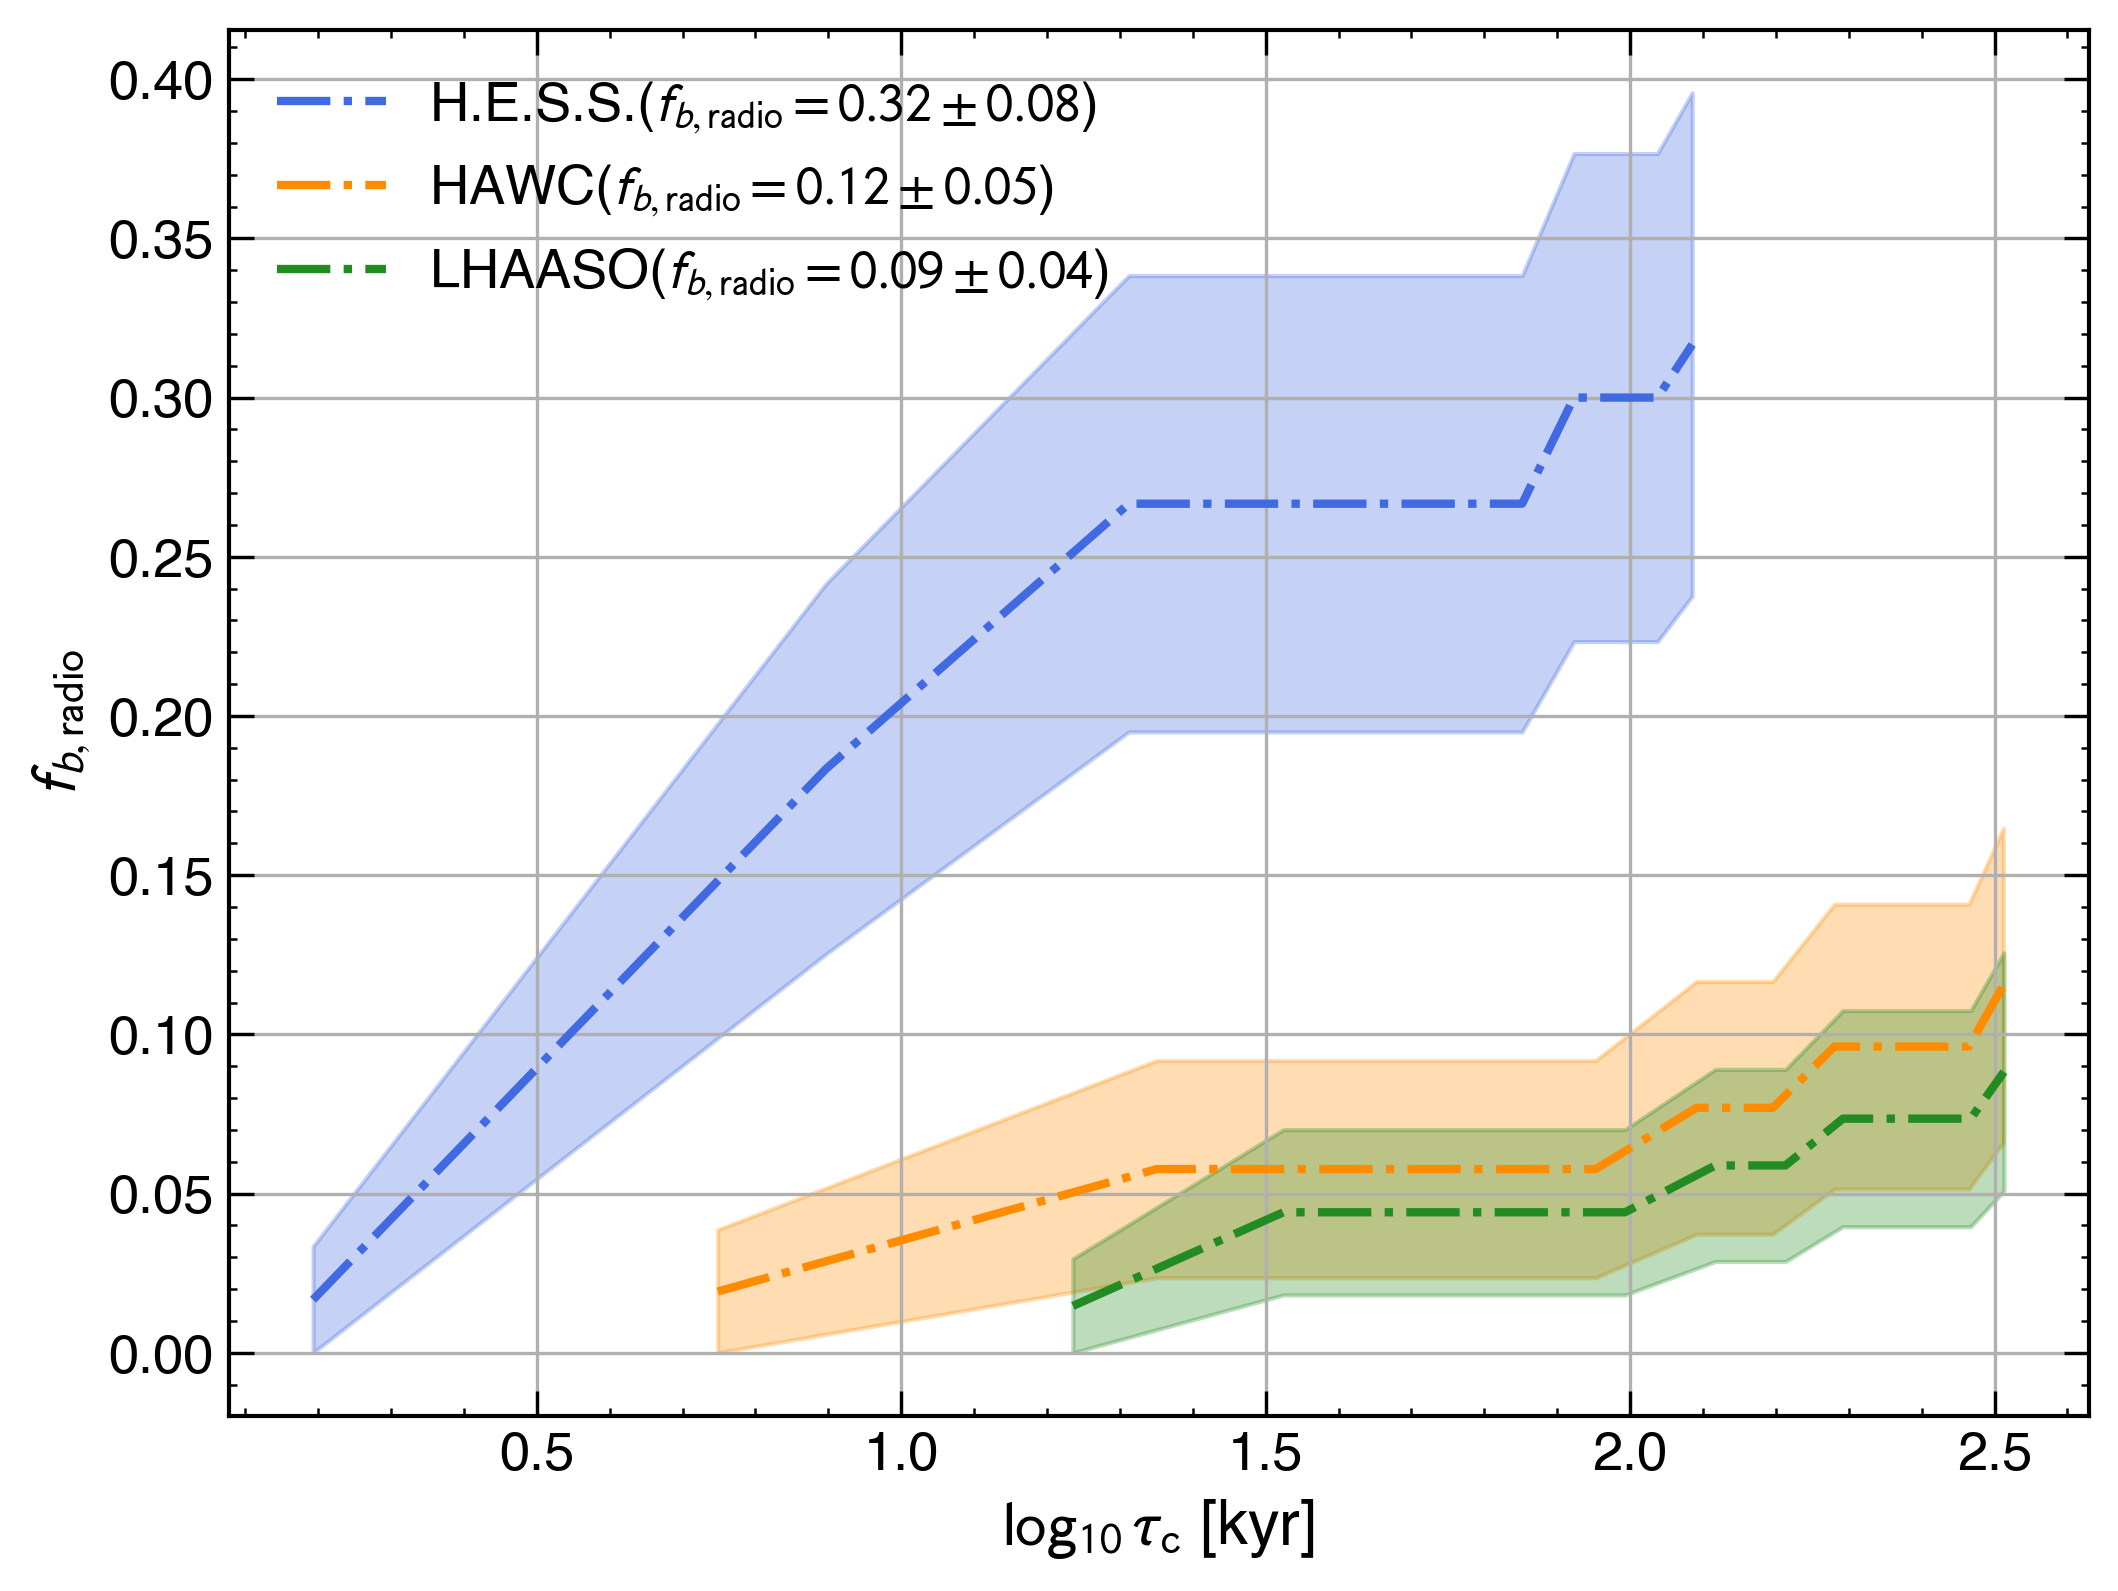

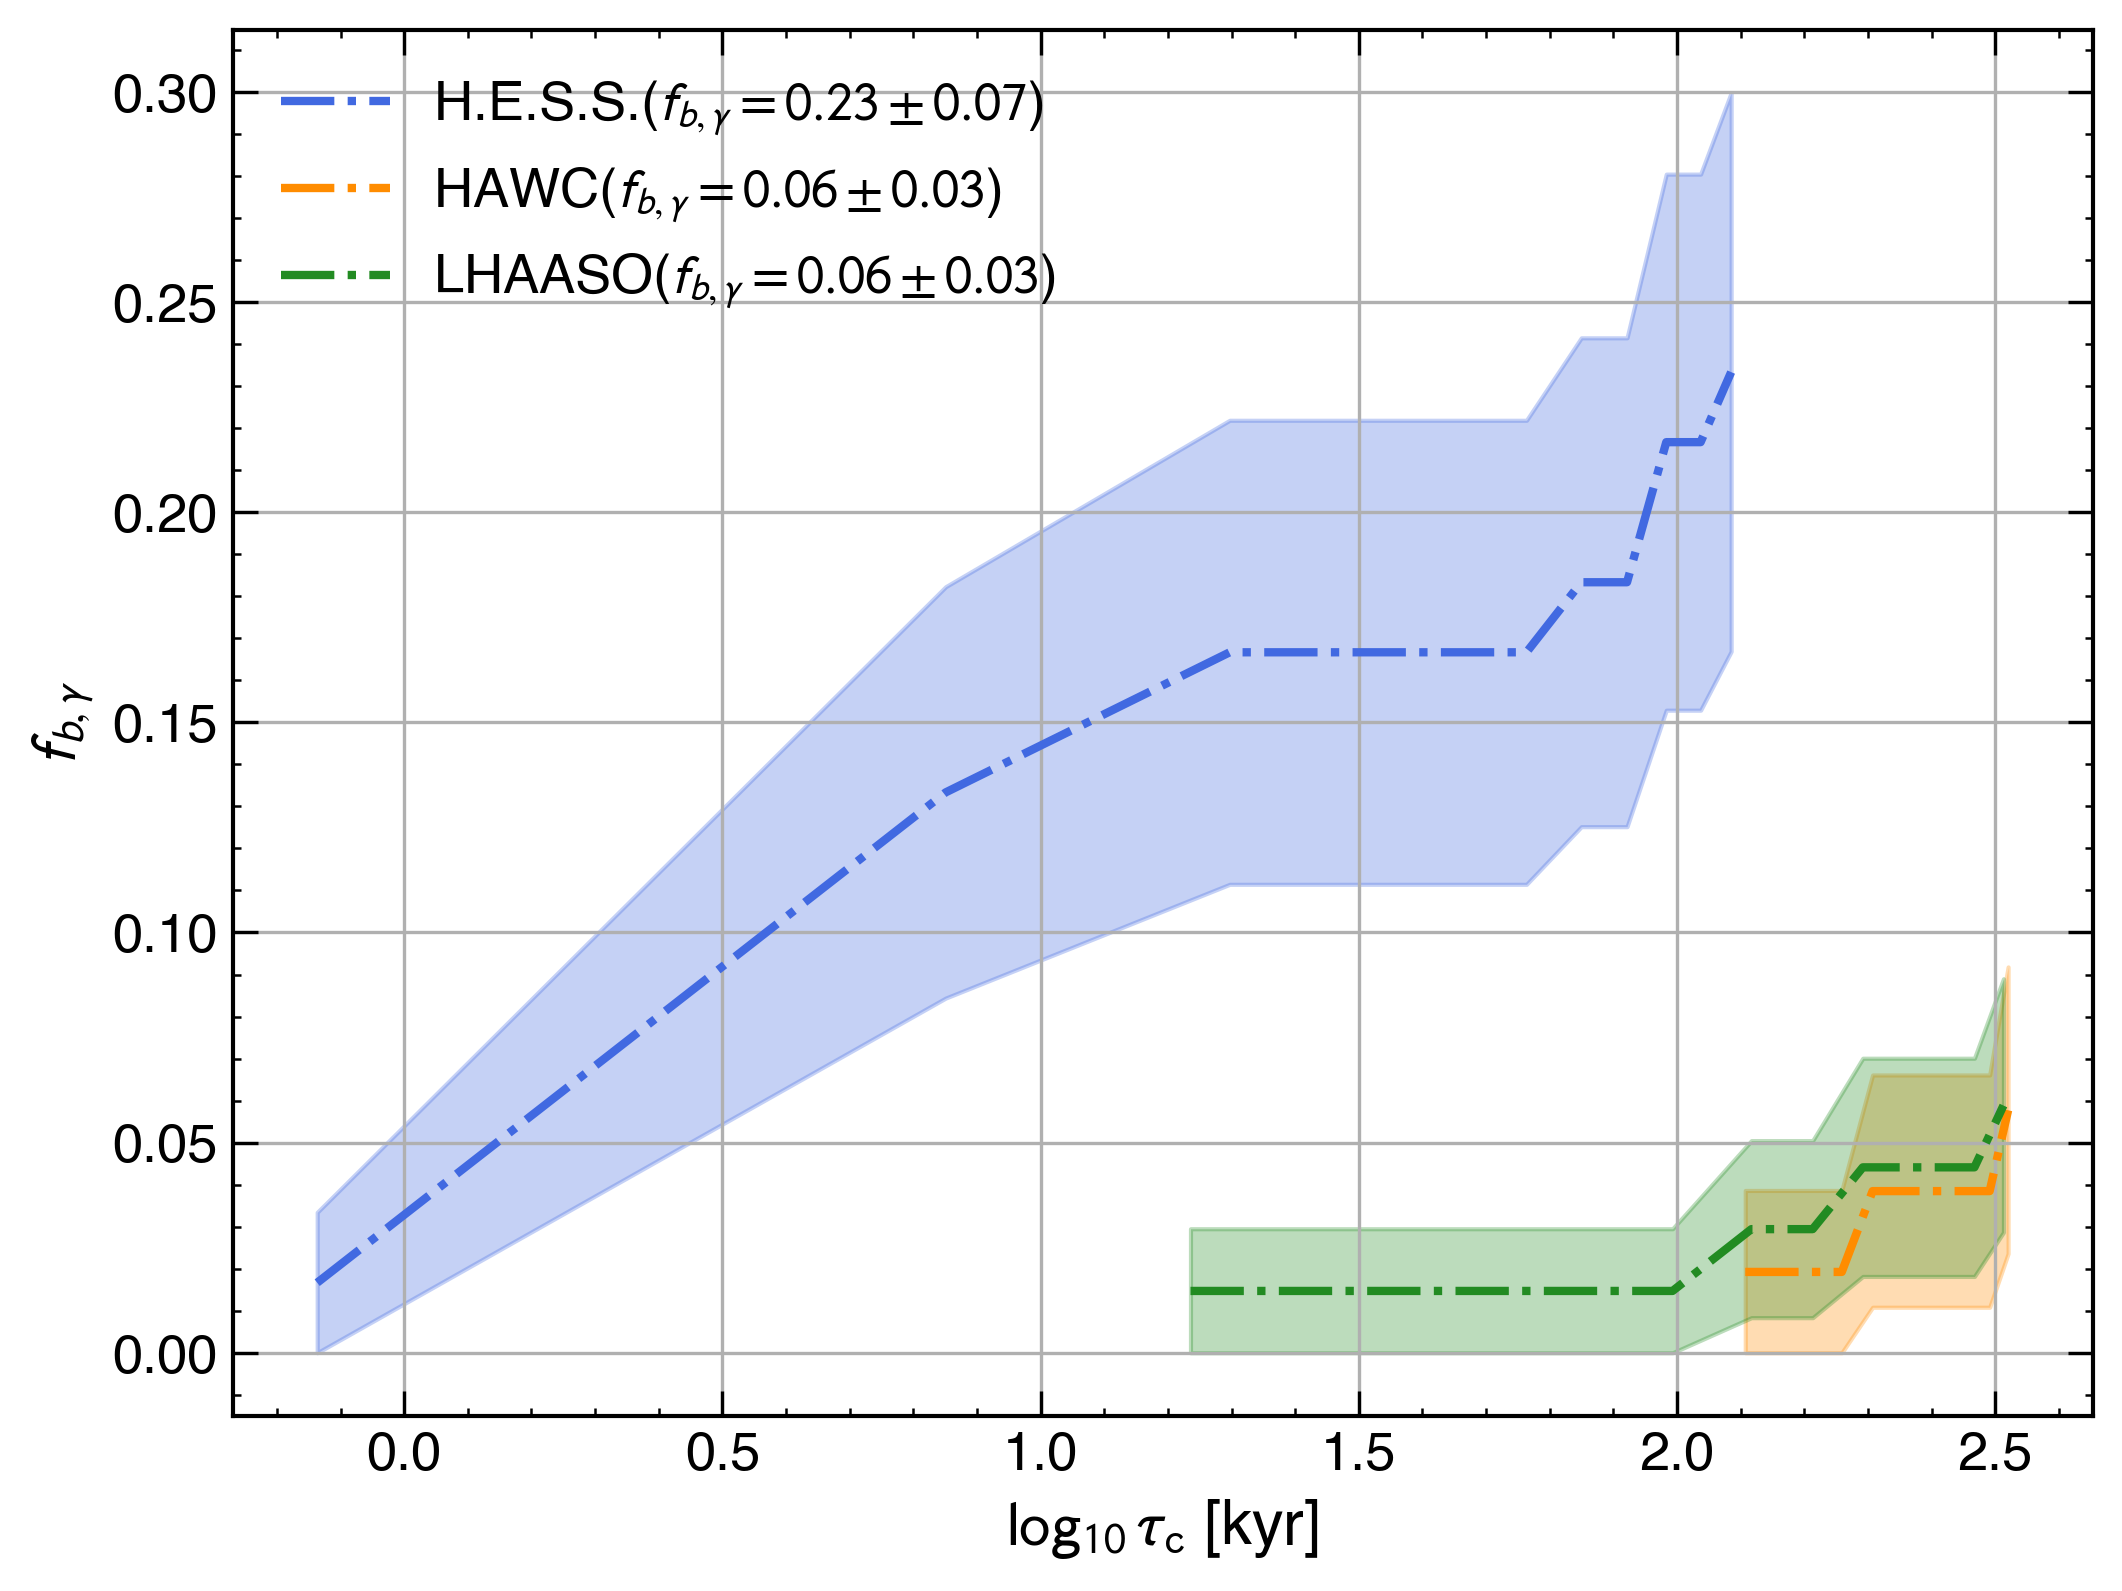

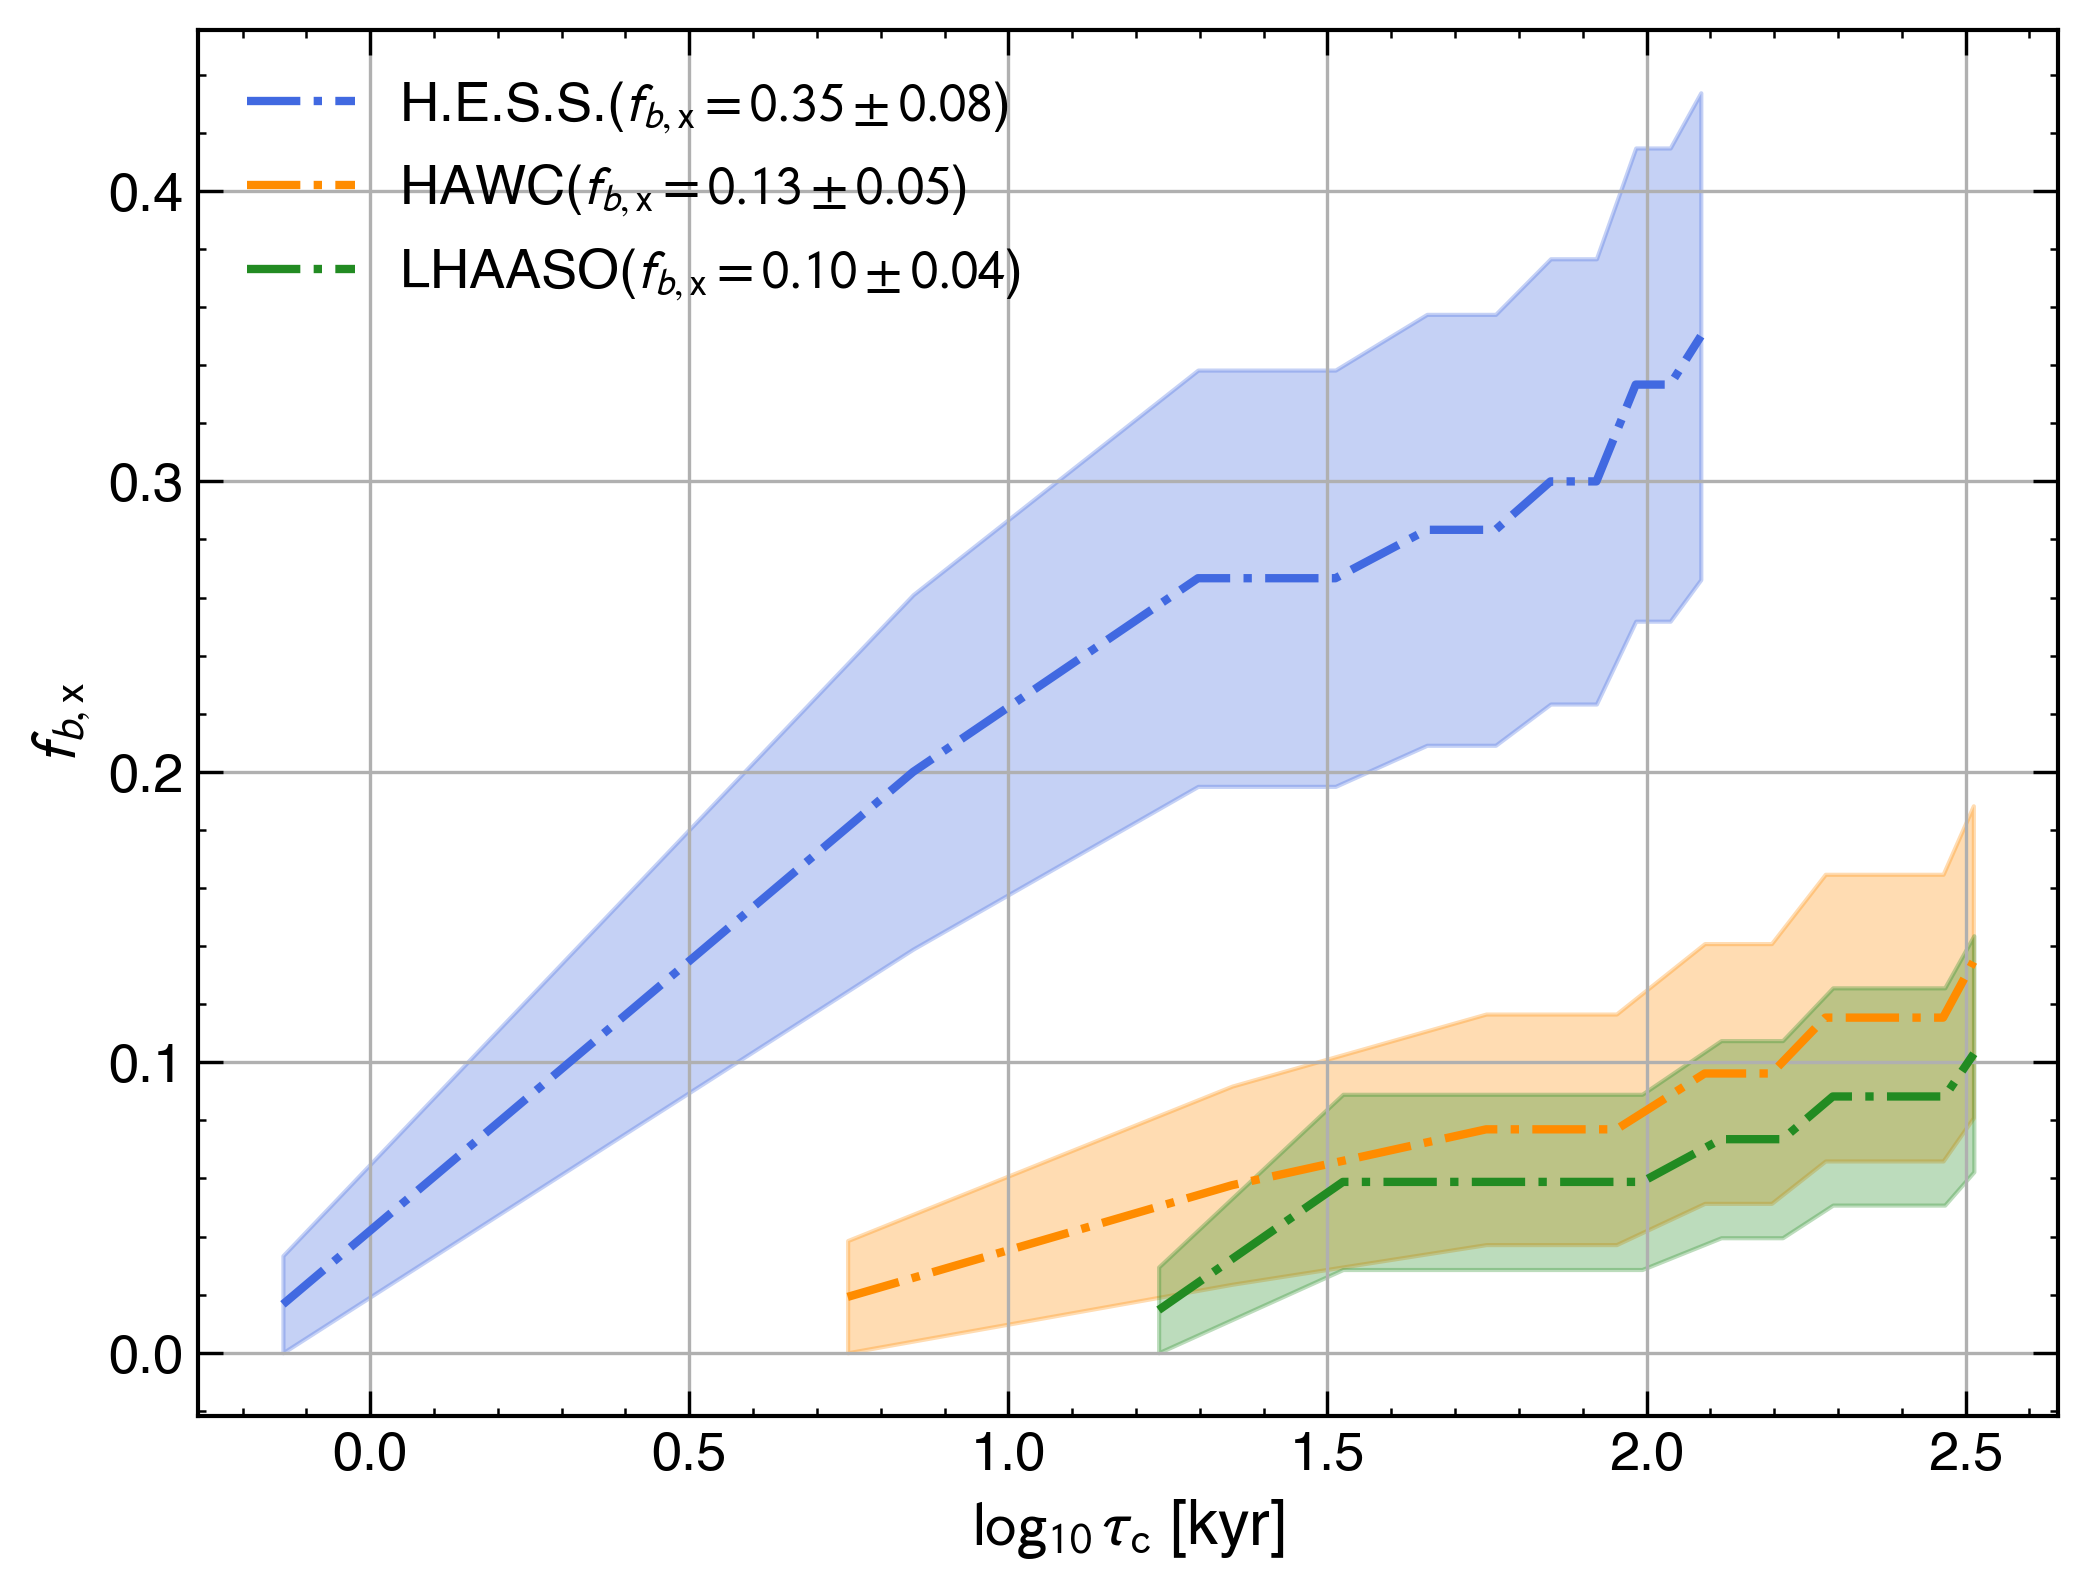

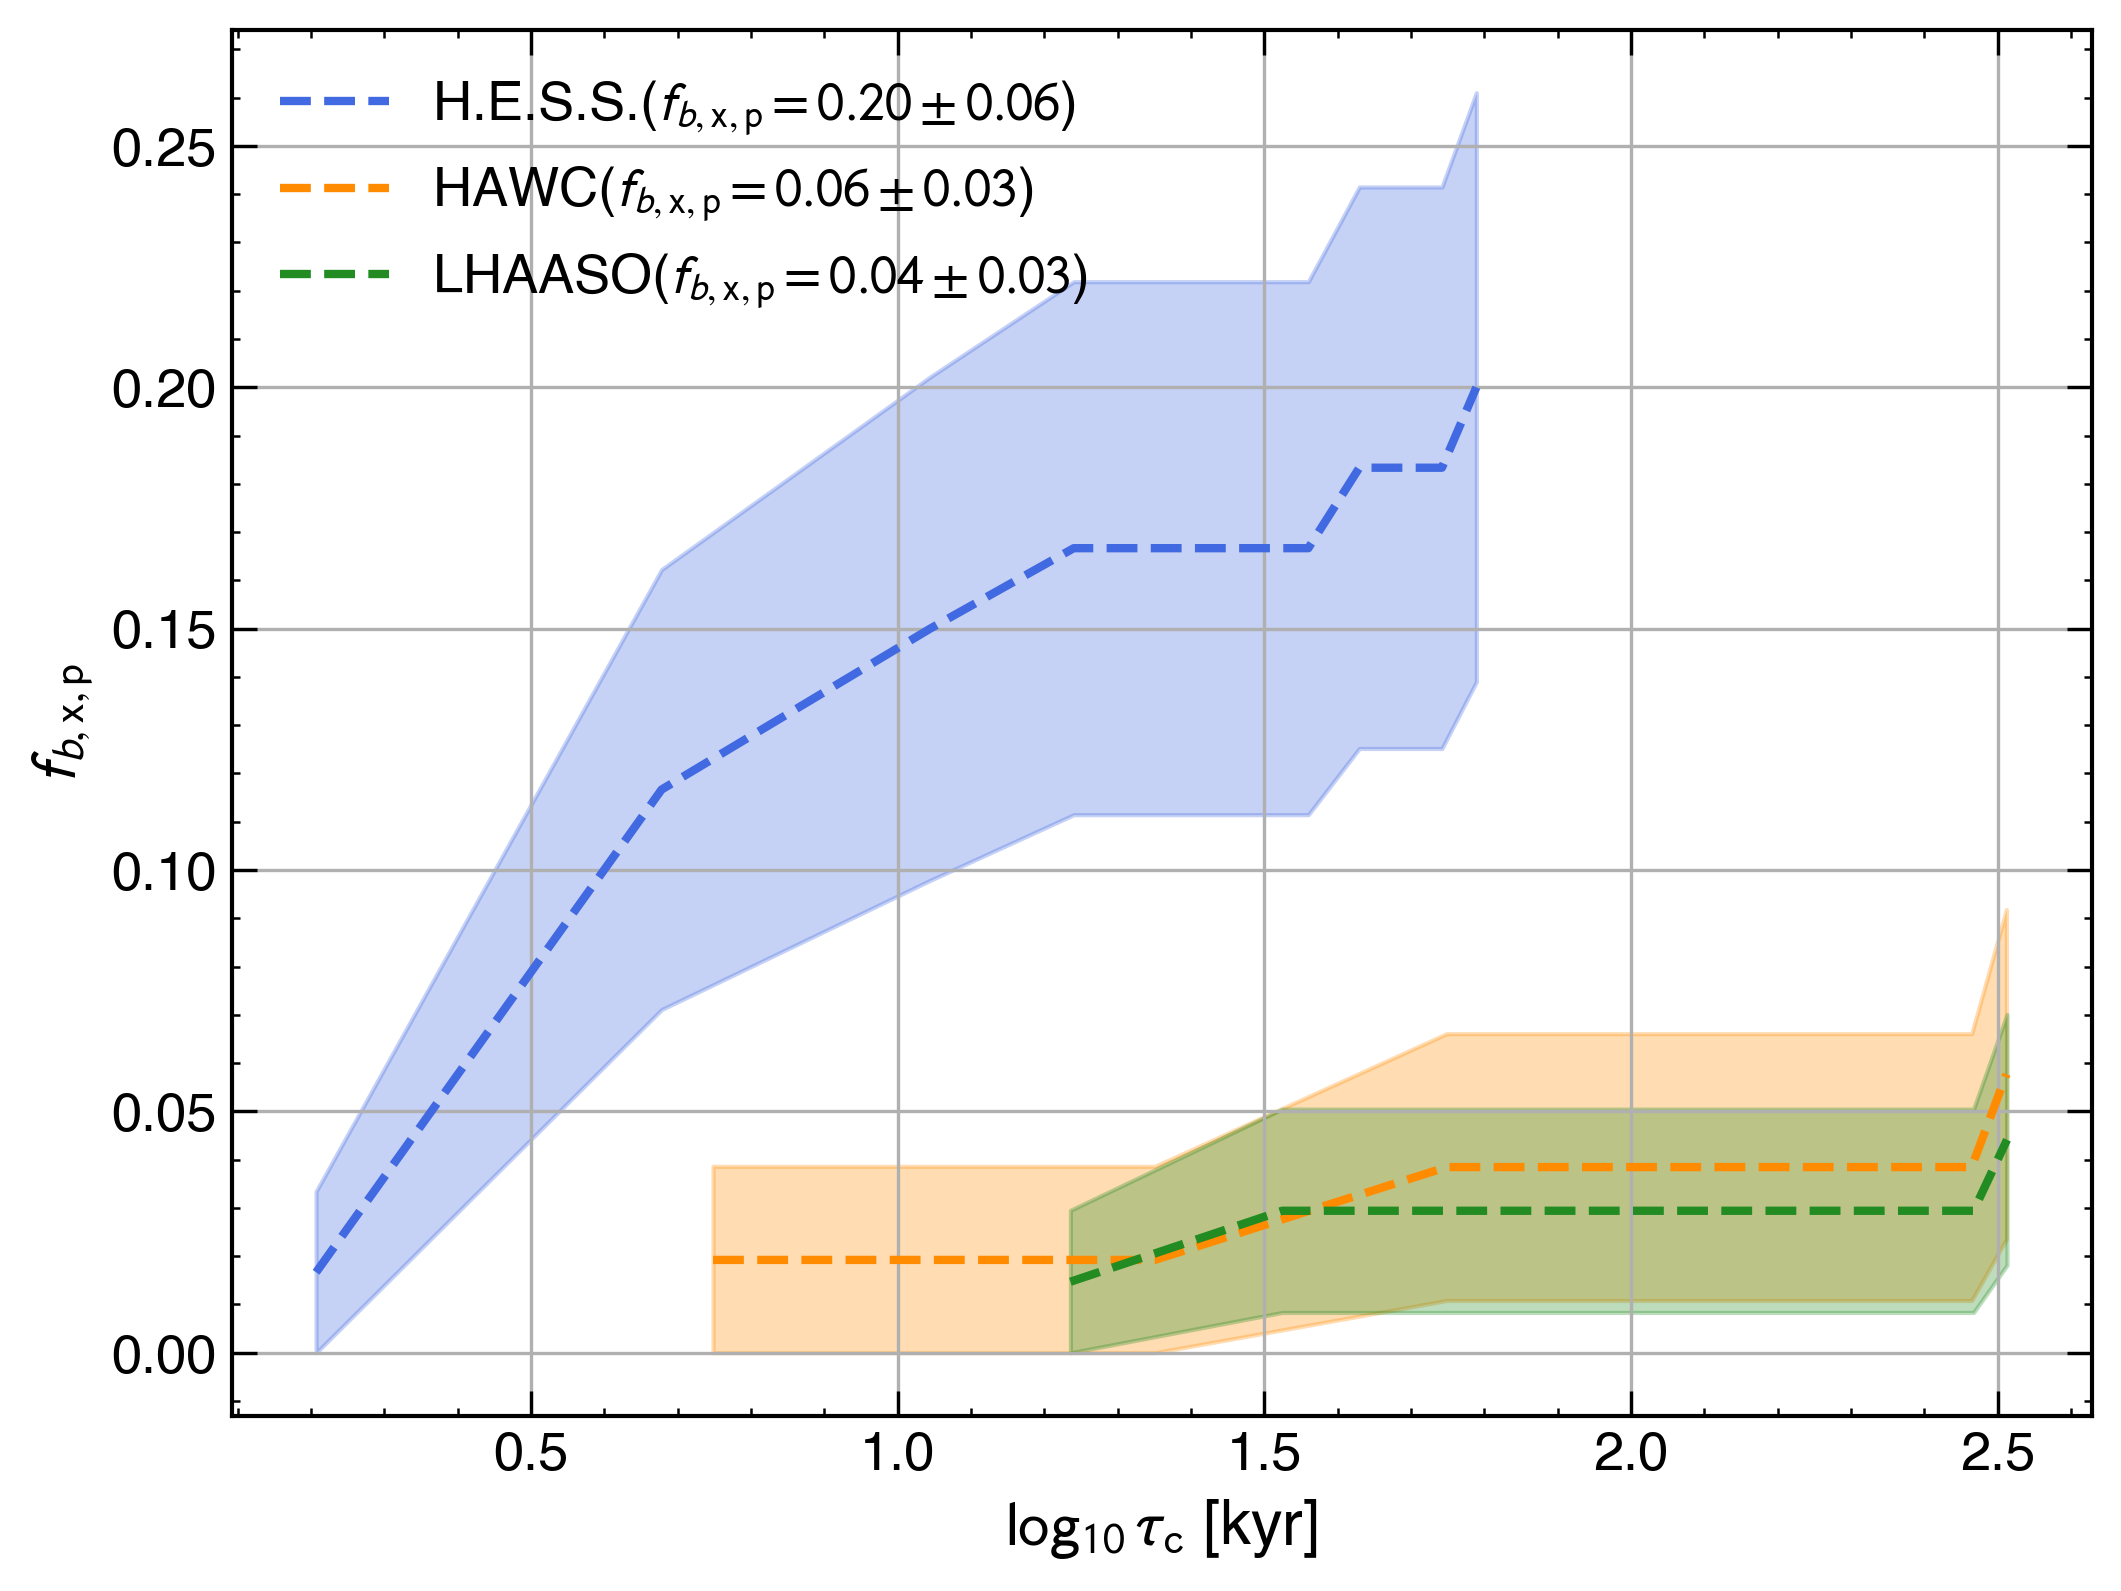

In [114]:
x_HESS_age_radio, y_HESS_age_radio, f_HESS_age_radio, y_err_HESS_age_radio, y_low_HESS_age_radio, y_high_HESS_age_radio = beaming_curve_cumulative_age(pwn_HESS_age[m_HESS], n_unid_region=n_unid_HESS, log_age_nu=pwn_HESS_radio_age[m_HESS], return_error=True)
x_HESS_age_gamma, y_HESS_age_gamma, f_HESS_age_gamma, y_err_HESS_age_gamma, y_low_HESS_age_gamma, y_high_HESS_age_gamma = beaming_curve_cumulative_age(pwn_HESS_age[m_HESS], n_unid_region=n_unid_HESS, log_age_nu=pwn_HESS_gamma_age[m_HESS], return_error=True)
x_HESS_age_x, y_HESS_age_x, f_HESS_age_x, y_err_HESS_age_x, y_low_HESS_age_x, y_high_HESS_age_x = beaming_curve_cumulative_age(pwn_HESS_age[m_HESS], n_unid_region=n_unid_HESS, log_age_nu=pwn_HESS_x_age[m_HESS], return_error=True)
x_HAWC_age_radio, y_HAWC_age_radio, f_HAWC_age_radio, y_err_HAWC_age_radio, y_low_HAWC_age_radio, y_high_HAWC_age_radio = beaming_curve_cumulative_age(pwn_HAWC_age[m_HAWC], n_unid_region=n_unid_HAWC, log_age_nu=pwn_HAWC_radio_age[m_HAWC], return_error=True)
x_HAWC_age_gamma, y_HAWC_age_gamma, f_HAWC_age_gamma, y_err_HAWC_age_gamma, y_low_HAWC_age_gamma, y_high_HAWC_age_gamma = beaming_curve_cumulative_age(pwn_HAWC_age[m_HAWC], n_unid_region=n_unid_HAWC, log_age_nu=pwn_HAWC_gamma_age[m_HAWC], return_error=True)
x_HAWC_age_x, y_HAWC_age_x, f_HAWC_age_x, y_err_HAWC_age_x, y_low_HAWC_age_x, y_high_HAWC_age_x = beaming_curve_cumulative_age(pwn_HAWC_age[m_HAWC], n_unid_region=n_unid_HAWC, log_age_nu=pwn_HAWC_x_age[m_HAWC], return_error=True)
x_LHAASO_age_radio, y_LHAASO_age_radio, f_LHAASO_age_radio, y_err_LHAASO_age_radio, y_low_LHAASO_age_radio, y_high_LHAASO_age_radio = beaming_curve_cumulative_age(pwn_LHAASO_age[m_LHAASO], n_unid_region=n_unid_LHAASO, log_age_nu=pwn_LHAASO_radio_age[m_LHAASO], return_error=True)
x_LHAASO_age_gamma, y_LHAASO_age_gamma, f_LHAASO_age_gamma, y_err_LHAASO_age_gamma, y_low_LHAASO_age_gamma, y_high_LHAASO_age_gamma = beaming_curve_cumulative_age(pwn_LHAASO_age[m_LHAASO], n_unid_region=n_unid_LHAASO, log_age_nu=pwn_LHAASO_gamma_age[m_LHAASO], return_error=True)
x_LHAASO_age_x, y_LHAASO_age_x, f_LHAASO_age_x, y_err_LHAASO_age_x, y_low_LHAASO_age_x, y_high_LHAASO_age_x = beaming_curve_cumulative_age(pwn_LHAASO_age[m_LHAASO], n_unid_region=n_unid_LHAASO, log_age_nu=pwn_LHAASO_x_age[m_LHAASO], return_error=True)
x_HESS_age_x_p, y_HESS_age_x_p, f_HESS_age_x_p, y_err_HESS_age_x_p, y_low_HESS_age_x_p, y_high_HESS_age_x_p = beaming_curve_cumulative_age(pwn_HESS_age[m_HESS], n_unid_region=n_unid_HESS, log_age_nu=pwn_HESS_x_p_age[m_HESS_p], return_error=True)
x_HAWC_age_x_p, y_HAWC_age_x_p, f_HAWC_age_x_p, y_err_HAWC_age_x_p, y_low_HAWC_age_x_p, y_high_HAWC_age_x_p = beaming_curve_cumulative_age(pwn_HAWC_age[m_HAWC], n_unid_region=n_unid_HAWC, log_age_nu=pwn_HAWC_x_p_age[m_HAWC_p], return_error=True)
x_LHAASO_age_x_p, y_LHAASO_age_x_p, f_LHAASO_age_x_p, y_err_LHAASO_age_x_p, y_low_LHAASO_age_x_p, y_high_LHAASO_age_x_p = beaming_curve_cumulative_age(pwn_LHAASO_age[m_LHAASO], n_unid_region=n_unid_LHAASO, log_age_nu=pwn_LHAASO_x_p_age[m_LHAASO_p], return_error=True)       
plt.figure(figsize=(8,6))
plt.plot(np.log10(x_HESS_age_radio), y_HESS_age_radio, label=r'H.E.S.S.($f_{{b,\mathrm{{radio}}}} = {:.2f}\pm{:.2f}$)'.format(y_HESS_age_radio[-1], y_err_HESS_age_radio[-1]), color='royalblue', linewidth=2, linestyle='dashdot'); plt.fill_between(np.log10(x_HESS_age_radio), y_low_HESS_age_radio, y_high_HESS_age_radio, color='royalblue', alpha=0.3)
plt.plot(np.log10(x_HAWC_age_radio), y_HAWC_age_radio, label=r'HAWC($f_{{b,\mathrm{{radio}}}} = {:.2f}\pm{:.2f}$)'.format(y_HAWC_age_radio[-1], y_err_HAWC_age_radio[-1]), color='darkorange', linewidth=2, linestyle='dashdot'); plt.fill_between(np.log10(x_HAWC_age_radio), y_low_HAWC_age_radio, y_high_HAWC_age_radio, color='darkorange', alpha=0.3)
plt.plot(np.log10(x_LHAASO_age_radio), y_LHAASO_age_radio, label=r'LHAASO($f_{{b,\mathrm{{radio}}}} = {:.2f}\pm{:.2f}$)'.format(y_LHAASO_age_radio[-1], y_err_LHAASO_age_radio[-1]), color='forestgreen', linewidth=2, linestyle='dashdot'); plt.fill_between(np.log10(x_LHAASO_age_radio), y_low_LHAASO_age_radio, y_high_LHAASO_age_radio, color='forestgreen', alpha=0.3)
plt.xlabel(r'$\log_{10} \tau_{\mathrm{c}}$ [kyr]'); plt.ylabel(r'$f_{b,\mathrm{radio}}$'); plt.legend(frameon=False, loc='best'); plt.grid(); plt.savefig('/Users/takumi/NS/Figure/beaming_fraction_age_radio.pdf', bbox_inches='tight', pad_inches=0.1); plt.show()

plt.figure(figsize=(8,6))
plt.plot(np.log10(x_HESS_age_gamma), y_HESS_age_gamma, label=r'H.E.S.S.($f_{{b,\gamma}} = {:.2f}\pm{:.2f}$)'.format(y_HESS_age_gamma[-1], y_err_HESS_age_gamma[-1]), color='royalblue', linewidth=2, linestyle='dashdot'); plt.fill_between(np.log10(x_HESS_age_gamma), y_low_HESS_age_gamma, y_high_HESS_age_gamma, color='royalblue', alpha=0.3)
plt.plot(np.log10(x_HAWC_age_gamma), y_HAWC_age_gamma, label=r'HAWC($f_{{b,\gamma}} = {:.2f}\pm{:.2f}$)'.format(y_HAWC_age_gamma[-1], y_err_HAWC_age_gamma[-1]), color='darkorange', linewidth=2, linestyle='dashdot'); plt.fill_between(np.log10(x_HAWC_age_gamma), y_low_HAWC_age_gamma, y_high_HAWC_age_gamma, color='darkorange', alpha=0.3)
plt.plot(np.log10(x_LHAASO_age_gamma), y_LHAASO_age_gamma, label=r'LHAASO($f_{{b,\gamma}} = {:.2f}\pm{:.2f}$)'.format(y_LHAASO_age_gamma[-1], y_err_LHAASO_age_gamma[-1]), color='forestgreen', linewidth=2, linestyle='dashdot'); plt.fill_between(np.log10(x_LHAASO_age_gamma), y_low_LHAASO_age_gamma, y_high_LHAASO_age_gamma, color='forestgreen', alpha=0.3)
plt.xlabel(r'$\log_{10} \tau_{\mathrm{c}}$ [kyr]'); plt.ylabel(r'$f_{b,\gamma}$'); plt.legend(frameon=False, loc='best'); plt.grid(); plt.savefig('/Users/takumi/NS/Figure/beaming_fraction_age_gamma.pdf', bbox_inches='tight', pad_inches=0.1); plt.show()

plt.figure(figsize=(8,6))
plt.plot(np.log10(x_HESS_age_x), y_HESS_age_x, label=r'H.E.S.S.($f_{{b,\mathrm{{x}}}} = {:.2f}\pm{:.2f}$)'.format(y_HESS_age_x[-1], y_err_HESS_age_x[-1]), color='royalblue', linewidth=2, linestyle='dashdot'); plt.fill_between(np.log10(x_HESS_age_x), y_low_HESS_age_x, y_high_HESS_age_x, color='royalblue', alpha=0.3)
plt.plot(np.log10(x_HAWC_age_x), y_HAWC_age_x, label=r'HAWC($f_{{b,\mathrm{{x}}}} = {:.2f}\pm{:.2f}$)'.format(y_HAWC_age_x[-1], y_err_HAWC_age_x[-1]), color='darkorange', linewidth=2, linestyle='dashdot'); plt.fill_between(np.log10(x_HAWC_age_x), y_low_HAWC_age_x, y_high_HAWC_age_x, color='darkorange', alpha=0.3)
plt.plot(np.log10(x_LHAASO_age_x), y_LHAASO_age_x, label=r'LHAASO($f_{{b,\mathrm{{x}}}} = {:.2f}\pm{:.2f}$)'.format(y_LHAASO_age_x[-1], y_err_LHAASO_age_x[-1]), color='forestgreen', linewidth=2, linestyle='dashdot'); plt.fill_between(np.log10(x_LHAASO_age_x), y_low_LHAASO_age_x, y_high_LHAASO_age_x, color='forestgreen', alpha=0.3)
plt.xlabel(r'$\log_{10} \tau_{\mathrm{c}}$ [kyr]'); plt.ylabel(r'$f_{b,\mathrm{x}}$'); plt.legend(frameon=False, loc='best'); plt.grid(); plt.savefig('/Users/takumi/NS/Figure/beaming_fraction_age_x.pdf', bbox_inches='tight', pad_inches=0.1); plt.show()

plt.figure(figsize=(8,6))
plt.plot(np.log10(x_HESS_age_x_p), y_HESS_age_x_p, label=r'H.E.S.S.($f_{{b,\mathrm{{x,p}}}} = {:.2f}\pm{:.2f}$)'.format(y_HESS_age_x_p[-1], y_err_HESS_age_x_p[-1]), color='royalblue', linewidth=2, linestyle='dashed'); plt.fill_between(np.log10(x_HESS_age_x_p), y_low_HESS_age_x_p, y_high_HESS_age_x_p, color='royalblue', alpha=0.3)
plt.plot(np.log10(x_HAWC_age_x_p), y_HAWC_age_x_p, label=r'HAWC($f_{{b,\mathrm{{x,p}}}} = {:.2f}\pm{:.2f}$)'.format(y_HAWC_age_x_p[-1], y_err_HAWC_age_x_p[-1]), color='darkorange', linewidth=2, linestyle='dashed'); plt.fill_between(np.log10(x_HAWC_age_x_p), y_low_HAWC_age_x_p, y_high_HAWC_age_x_p, color='darkorange', alpha=0.3)
plt.plot(np.log10(x_LHAASO_age_x_p), y_LHAASO_age_x_p, label=r'LHAASO($f_{{b,\mathrm{{x,p}}}} = {:.2f}\pm{:.2f}$)'.format(y_LHAASO_age_x_p[-1], y_err_LHAASO_age_x_p[-1]), color='forestgreen', linewidth=2, linestyle='dashed'); plt.fill_between(np.log10(x_LHAASO_age_x_p), y_low_LHAASO_age_x_p, y_high_LHAASO_age_x_p, color='forestgreen', alpha=0.3)
plt.xlabel(r'$\log_{10} \tau_{\mathrm{c}}$ [kyr]'); plt.ylabel(r'$f_{b,\mathrm{x,p}}$'); plt.legend(frameon=False, loc='best'); plt.grid(); plt.savefig('/Users/takumi/NS/Figure/beaming_fraction_age_x_p.pdf', bbox_inches='tight', pad_inches=0.1); plt.show()

In [20]:
pwn_L, pwn_L_min, pwn_L_max = pl_lumi_mc(pwn_flux, pwn_flux_err,pwn_index,    pwn_index_err,   pwn_d,        0,                   E0=pwn_pivot,   Emin=1.0, Emax=10.0, nsim=20000)
pwn_HESS_L, pwn_HESS_L_min, pwn_HESS_L_max = pl_lumi_mc(pwn_HESS_flux, pwn_HESS_flux_err,pwn_HESS_index,    pwn_HESS_index_err,   pwn_HESS_d,        0,                   E0=pwn_HESS_pivot,   Emin=1.0, Emax=10.0, nsim=20000)
pwn_HAWC_L, pwn_HAWC_L_min, pwn_HAWC_L_max = pl_lumi_mc(pwn_HAWC_flux, pwn_HAWC_flux_err,pwn_HAWC_index,    pwn_HAWC_index_err,   pwn_HAWC_d,        0,                   E0=pwn_HAWC_pivot,   Emin=1.0, Emax=10.0, nsim=20000)
pwn_LHAASO_L, pwn_LHAASO_L_min, pwn_LHAASO_L_max = pl_lumi_mc(pwn_LHAASO_flux, pwn_LHAASO_flux_err,pwn_LHAASO_index,    pwn_LHAASO_index_err,   pwn_LHAASO_d,        0,                   E0=pwn_LHAASO_pivot,   Emin=1.0, Emax=10.0, nsim=20000)

In [21]:
pwn_L_10, pwn_L_min_10, pwn_L_max_10 = pl_lumi_mc(pwn_flux, pwn_flux_err,pwn_index,    pwn_index_err,   pwn_d,        0,                   E0=pwn_pivot,   Emin=10.0, Emax=100.0, nsim=20000)
pwn_HESS_L_10, pwn_HESS_L_min_10, pwn_HESS_L_max_10 = pl_lumi_mc(pwn_HESS_flux, pwn_HESS_flux_err,pwn_HESS_index,    pwn_HESS_index_err,   pwn_HESS_d,        0,                   E0=pwn_HESS_pivot,   Emin=10.0, Emax=100.0, nsim=20000)
pwn_HAWC_L_10, pwn_HAWC_L_min_10, pwn_HAWC_L_max_10 = pl_lumi_mc(pwn_HAWC_flux, pwn_HAWC_flux_err,pwn_HAWC_index,    pwn_HAWC_index_err,   pwn_HAWC_d,        0,                   E0=pwn_HAWC_pivot,   Emin=10.0, Emax=100.0, nsim=20000)
pwn_LHAASO_L_10, pwn_LHAASO_L_min_10, pwn_LHAASO_L_max_10 = pl_lumi_mc(pwn_LHAASO_flux, pwn_LHAASO_flux_err,pwn_LHAASO_index,    pwn_LHAASO_index_err,   pwn_LHAASO_d,        0,                   E0=pwn_LHAASO_pivot,   Emin=10.0, Emax=100.0, nsim=20000)

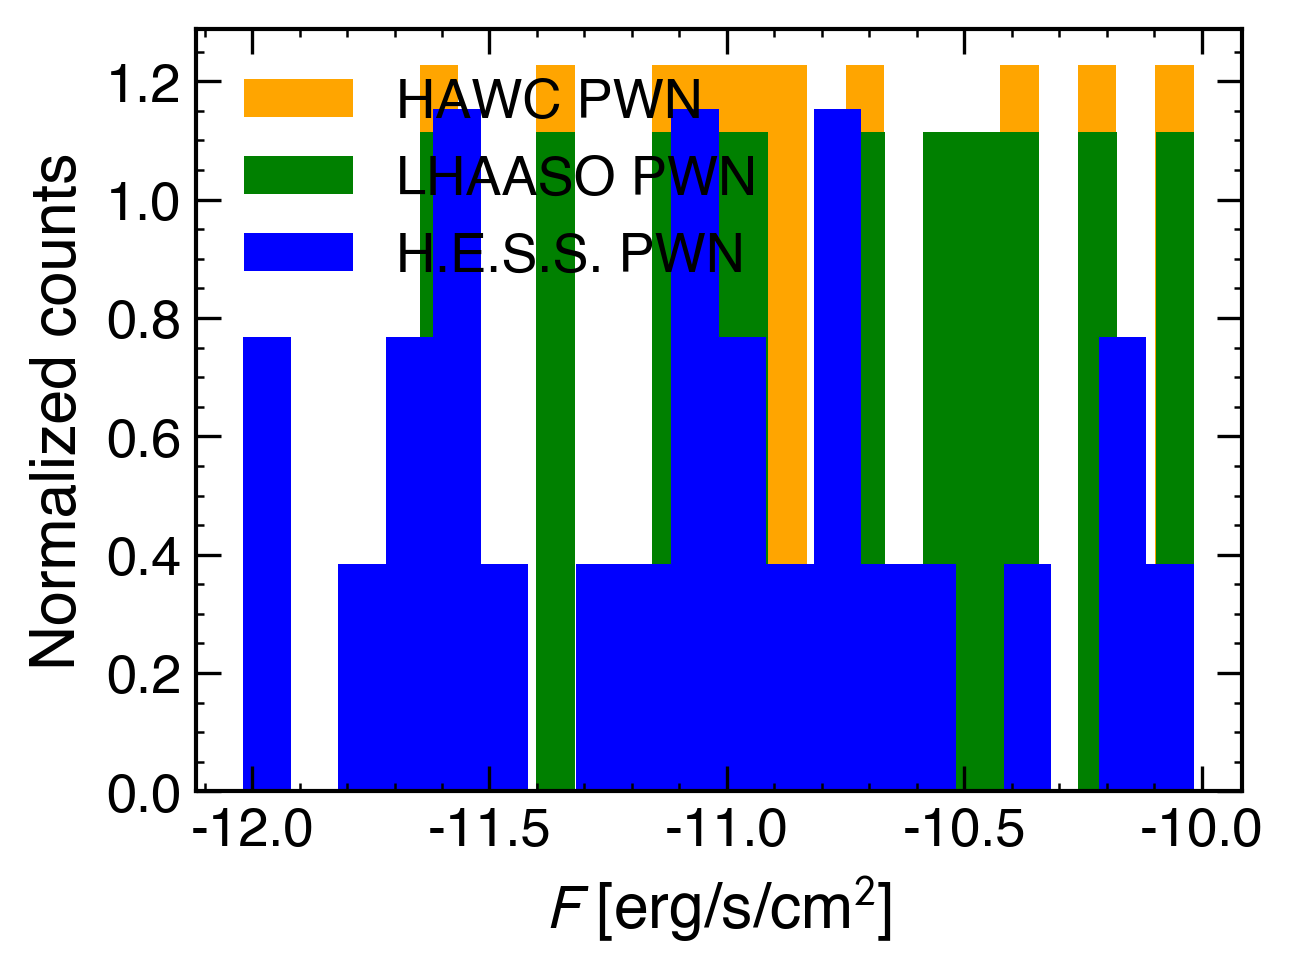

In [22]:
plt.hist(np.log10(pwn_HAWC_L/(pwn_HAWC_d*3e21)**2/4/np.pi), bins=20, alpha=1, label='HAWC PWN', color='orange', density=True)
plt.hist(np.log10(pwn_LHAASO_L/(pwn_LHAASO_d*3e21)**2/4/np.pi), bins=20, alpha=1, label='LHAASO PWN', color='green', density=True)
plt.hist(np.log10(pwn_HESS_L/(pwn_HESS_d*3e21)**2/4/np.pi), bins=20, alpha=1, label='H.E.S.S. PWN', color='blue', density=True)
plt.xlabel(r'$F$ [erg/s/cm$^2$]')
plt.ylabel('Normalized counts')
plt.legend()
plt.show()

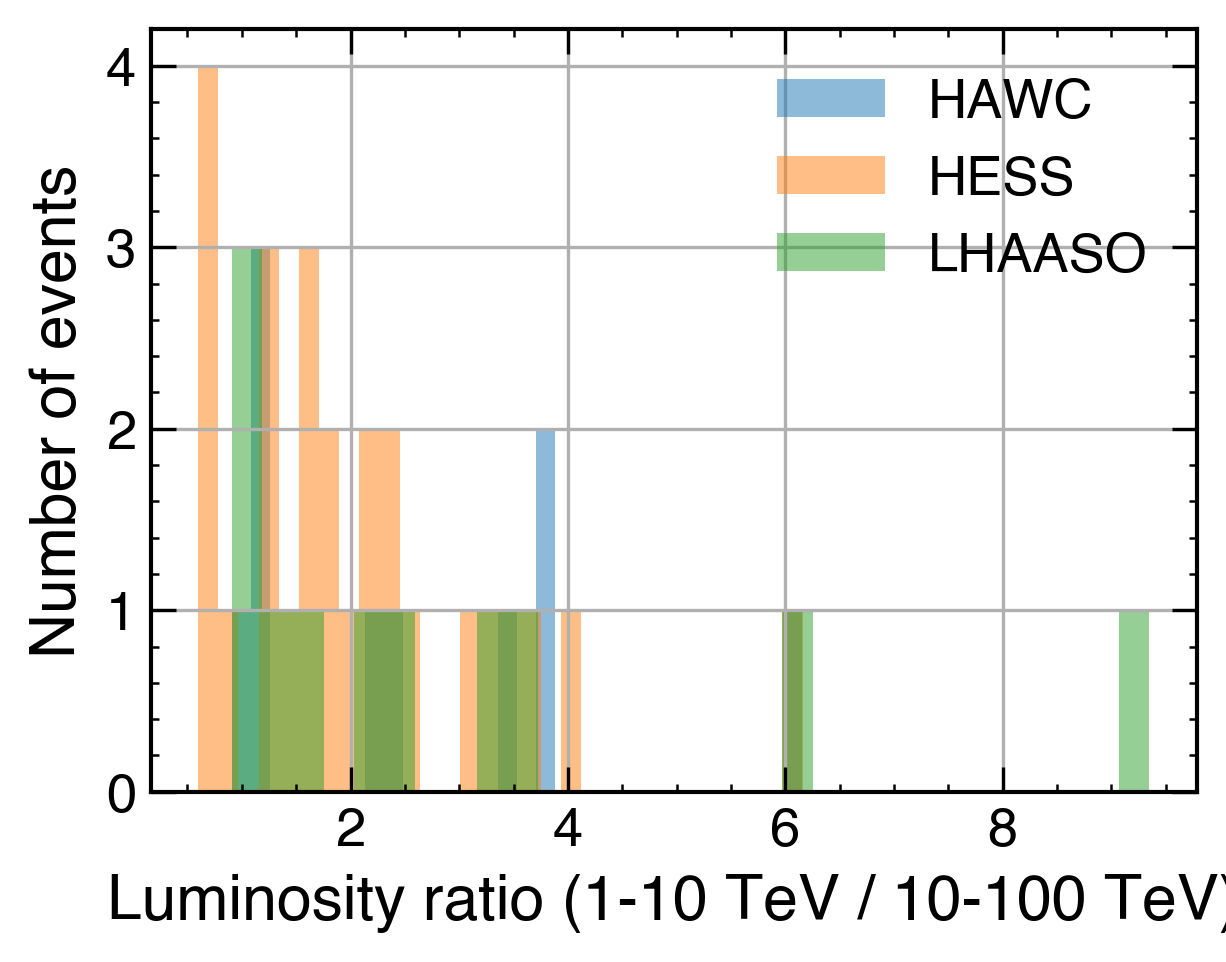

In [23]:
plt.hist(pwn_HAWC_L / pwn_HAWC_L_10, bins=30, alpha=0.5, label='HAWC')
plt.hist(pwn_HESS_L / pwn_HESS_L_10, bins=30, alpha=0.5, label='HESS')
plt.hist(pwn_LHAASO_L / pwn_LHAASO_L_10, bins=30, alpha=0.5, label='LHAASO')
plt.xlabel('Luminosity ratio (1-10 TeV / 10-100 TeV)')
plt.ylabel('Number of events')
plt.legend()
plt.grid()
plt.savefig('/Users/takumi/NS/Figure/PWN_Beaming_Fraction.pdf', bbox_inches='tight', pad_inches=0.1)


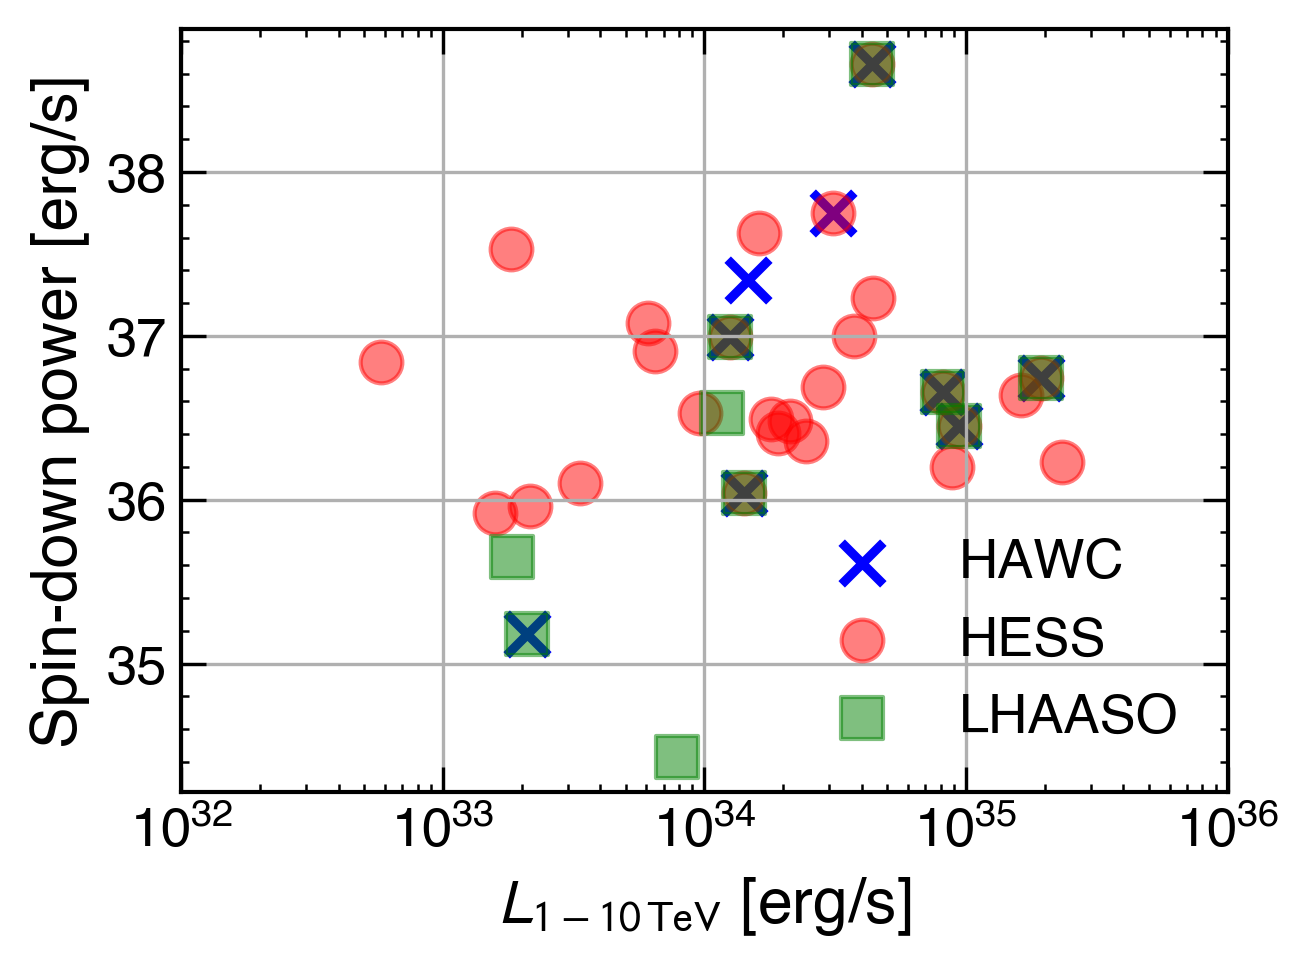

In [24]:
plt.scatter(pwn_HAWC_L, pwn_HAWC_Edot, color = 'blue', label = 'HAWC', marker ='x', s =100, alpha=1)
plt.scatter(pwn_HESS_L, pwn_HESS_Edot, color = 'red', label = 'HESS', marker ='o', s =100, alpha=0.5)
plt.scatter(pwn_LHAASO_L, pwn_LHAASO_Edot, color = 'green', label = 'LHAASO', marker ='s', s =100, alpha=0.5)
plt.xscale('log')
plt.xlabel(r'$L_{1-10\,\mathrm{TeV}}$ [erg/s]')
plt.ylabel('Spin-down power [erg/s]')
plt.legend()
plt.grid()
plt.xlim(1e32, 1e36)
plt.savefig('/Users/takumi/NS/Figure/PWN_Luminosity_vs_Edot.pdf', bbox_inches='tight', pad_inches=0.1)

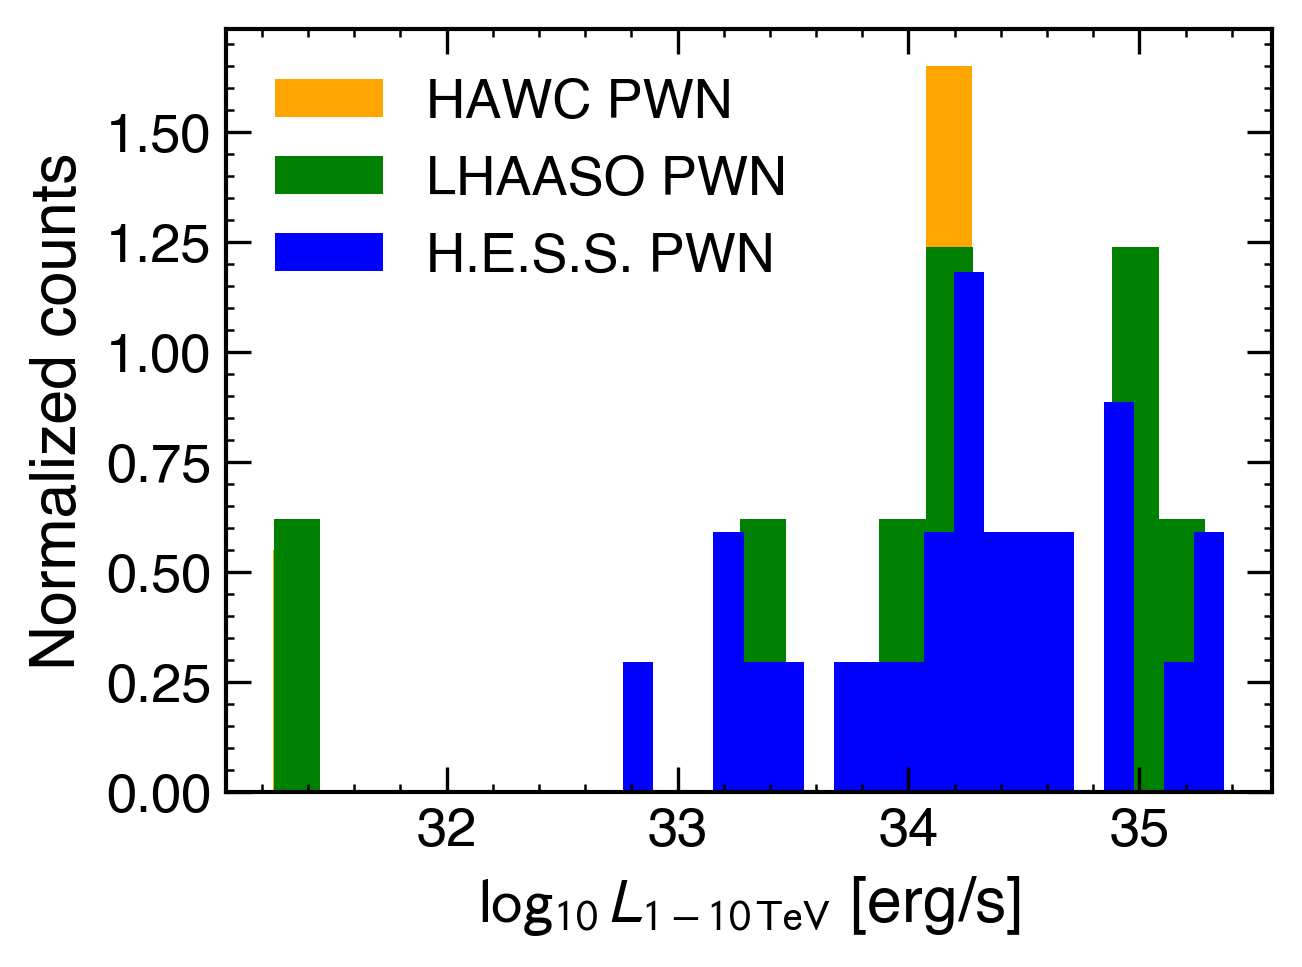

In [25]:
plt.hist(np.log10(pwn_HAWC_L[np.abs(pwn_HAWC_b) < 4]), bins=20, alpha=1, label='HAWC PWN', color='orange', density=True)
plt.hist(np.log10(pwn_LHAASO_L[np.abs(pwn_LHAASO_b) < 5]), bins=20, alpha=1, label='LHAASO PWN', color='green', density=True)
plt.hist(np.log10(pwn_HESS_L[np.abs(pwn_HESS_b) < 7 ]), bins=20, alpha=1, label='H.E.S.S. PWN', color='blue', density=True)
plt.xlabel(r'$\log_{10} L_{1-10\,\mathrm{TeV}}$ [erg/s]')
plt.ylabel('Normalized counts')
plt.legend()
plt.savefig('/Users/takumi/NS/Figure/PWN_Luminosity_distribution.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

In [26]:
np.random.normal(loc=34, scale=0.5, size=10000)

array([33.62678098, 33.92041988, 34.42416975, ..., 34.123408  ,
       33.40598941, 33.96838488], shape=(10000,))

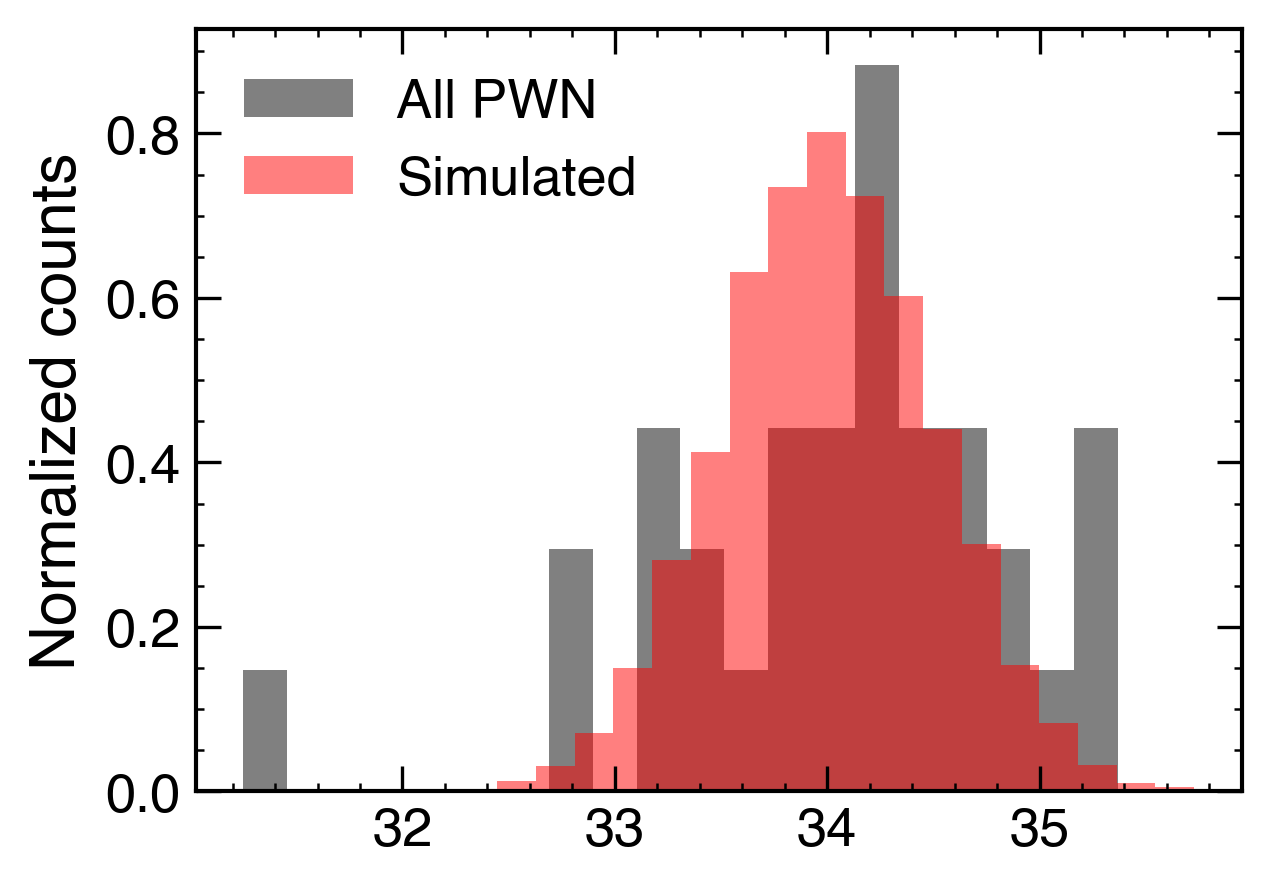

In [27]:
plt.hist(np.log10(pwn_L), bins=20, alpha=1, label='All PWN', color='gray', density=True)
L_sim = np.random.normal(loc=34, scale=0.5, size=10000)
plt.hist(L_sim, bins=20, alpha=0.5, label='Simulated', color='red', density=True)
plt.ylabel('Normalized counts')
plt.legend()
plt.savefig('/Users/takumi/NS/Figure/PWN_Luminosity_distribution_all.pdf', bbox_inches='tight', pad_inches=0.1)

In [32]:
from astropy.coordinates import Angle

In [33]:

def ra_dec_to_deg(ra_str, dec_str):
    """
    RA/Dec を文字列 (例: "17:45:44", "-29:00:00") から度に変換する。

    Parameters
    ----------
    ra_str : str
        RA in "hh:mm:ss"
    dec_str : str
        Dec in "±dd:mm:ss"

    Returns
    -------
    ra_deg, dec_deg : float
        RA, Dec in degrees
    """
    ra_deg = Angle(ra_str + " hours").degree
    dec_deg = Angle(dec_str + " degrees").degree
    return ra_deg, dec_deg

def xy(ra_deg, dec_deg, dis):
    """
    (RA, Dec, distance) -> (x, y) in Galactic coordinates.
    RA, Dec [deg], distance [kpc or chosen unit]

    Returns
    -------
    x, y : ndarray or float
        Projected galactic coordinates (x,y)
    """
    c = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame='icrs')
    gal = c.galactic

    l_rad = gal.l.radian
    b_rad = gal.b.radian
    dis = np.asarray(dis, dtype=float)

    x = dis * np.cos(l_rad) * np.cos(b_rad)
    y = dis * np.sin(l_rad) * np.cos(b_rad)

    return -x, -y   # 符号は元のコードに合わせてマイナス

def lb(ra_deg, dec_deg):
    """
    (RA, Dec) -> Galactic (l, b) in degrees.
    RA, Dec [deg]

    Returns
    -------
    l, b : float
        Galactic longitude, latitude [deg]
    """
    c = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame='icrs')
    gal = c.galactic
    return gal.l.deg, gal.b.deg


In [34]:
df_snr = pd.read_csv(
    "/Users/takumi/NS/PWN/csv/SNRcat20250928-SNR.csv",
    sep=";",            # 連続空白を区切りに
    engine="python",       # 正規表現sepに強い
    comment="#",           # # 以降はコメントとして無視（任意）
    skip_blank_lines=True,
    on_bad_lines="skip"    # 変な行は飛ばす（任意）
)



snr_ra = df_snr['J2000_ra (hh:mm:ss)'].dropna()
snr_dec = df_snr['J2000_dec (dd:mm:ss)'].dropna()
snr__ra_deg, snr_dec_deg = ra_dec_to_deg(snr_ra, snr_dec)
snr_l, snr_b = lb(snr__ra_deg, snr_dec_deg)


In [35]:
df_snr

,G,id_uncertain,id_new,id_alt,id_old,type,type_uncertain,context,remnant,SN_year,...,age_max (yr),distance_min (kpc),distance_max (kpc),size_coarse (arcmin),size_imprecise,size_radio,size_X,J2000_ra (hh:mm:ss),J2000_dec (dd:mm:ss),J2000_from
0,G000.0+00.0,NaN,NaN,Sgr A East,NaN,thermal composite,NaN,contains CXOGC J174545.5-285829 = the Cannonba...,"eje,NS,PWN?",NaN,...,10000.0,8.00,8.34,2.90,NaN,3.5'x2.5',NaN,17:45:44,-29:00:00,Green J coord
1,G000.1-00.1,NaN,NaN,G0.13-0.12,NaN,thermal & plerionic composite,1.0,contains PWN G0.13-0.11,"eje?,PWN",NaN,...,NaN,NaN,NaN,0.70,1.0,NaN,">40"" x ~2""",17:46:30,-28:51:30,paper J coord
2,G000.3+00.0,NaN,NaN,NaN,"G0.33+0.04, G0.4+0.1",shell,NaN,NaN,eje,NaN,...,500000.0,8.34,8.50,11.00,1.0,15'x8',NaN,17:46:15,-28:38:00,Green J coord
3,G000.9+00.1,NaN,NaN,NaN,NaN,plerionic composite,NaN,contains PSR J1747-2809 + PWN G0.87+0.08,"eje,PSR,PWN",NaN,...,1900.0,8.34,10.00,8.00,NaN,8',NaN,17:47:21,-28:09:00,Green J coord
4,G001.0-00.1,NaN,NaN,Sgr D,"G1.05-0.1, G1.05-0.15",shell,NaN,close to star forming region Sgr D and other S...,eje,NaN,...,NaN,8.00,8.34,8.00,NaN,8',NaN,17:48:30,-28:09:00,Green J coord
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,G359.0-00.9,NaN,NaN,NaN,NaN,shell,NaN,NaN,eje,NaN,...,9700.0,3.13,3.85,23.00,NaN,23',NaN,17:46:50,-30:16:00,Green J coord
379,G359.1+00.9,NaN,NaN,NaN,NaN,shell,NaN,NaN,eje,NaN,...,NaN,NaN,NaN,12.00,NaN,12'x11',NaN,17:39:36,-29:11:00,Green J coord
380,G359.1-00.5,NaN,NaN,NaN,NaN,thermal composite,NaN,close to PSR J1747-2958 + PWN G359.23-0.82 = t...,eje,NaN,...,20700.0,3.29,5.00,24.00,NaN,24',NaN,17:45:30,-29:57:00,Green J coord
381,G359.2-00.8,NaN,NaN,Mouse,NaN,filled-centre,NaN,bow shock PWN G359.23-0.82 = the Mouse and PSR...,"PSR,PWN",NaN,...,NaN,NaN,NaN,4.90,1.0,12'x2',"40""-45""",17:47:00,-30:01:10,paper G name


In [36]:
len(pwn_HESS), len(pwn_LHAASO), len(pwn_HAWC), n_unid_HESS, n_unid_LHAASO, n_unid_HAWC

(26, 11, 10, 35, 63, 46)

In [37]:
def to_float_array(x):
    """数値配列に変換し、NaN を除外"""
    x = pd.to_numeric(x, errors='coerce')  # 数値化、変換できないものは NaN
    return x

pwn_l = to_float_array(pwn_l)
pwn_b = to_float_array(pwn_b)
unid_l = to_float_array(unid_l)
unid_b = to_float_array(unid_b)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


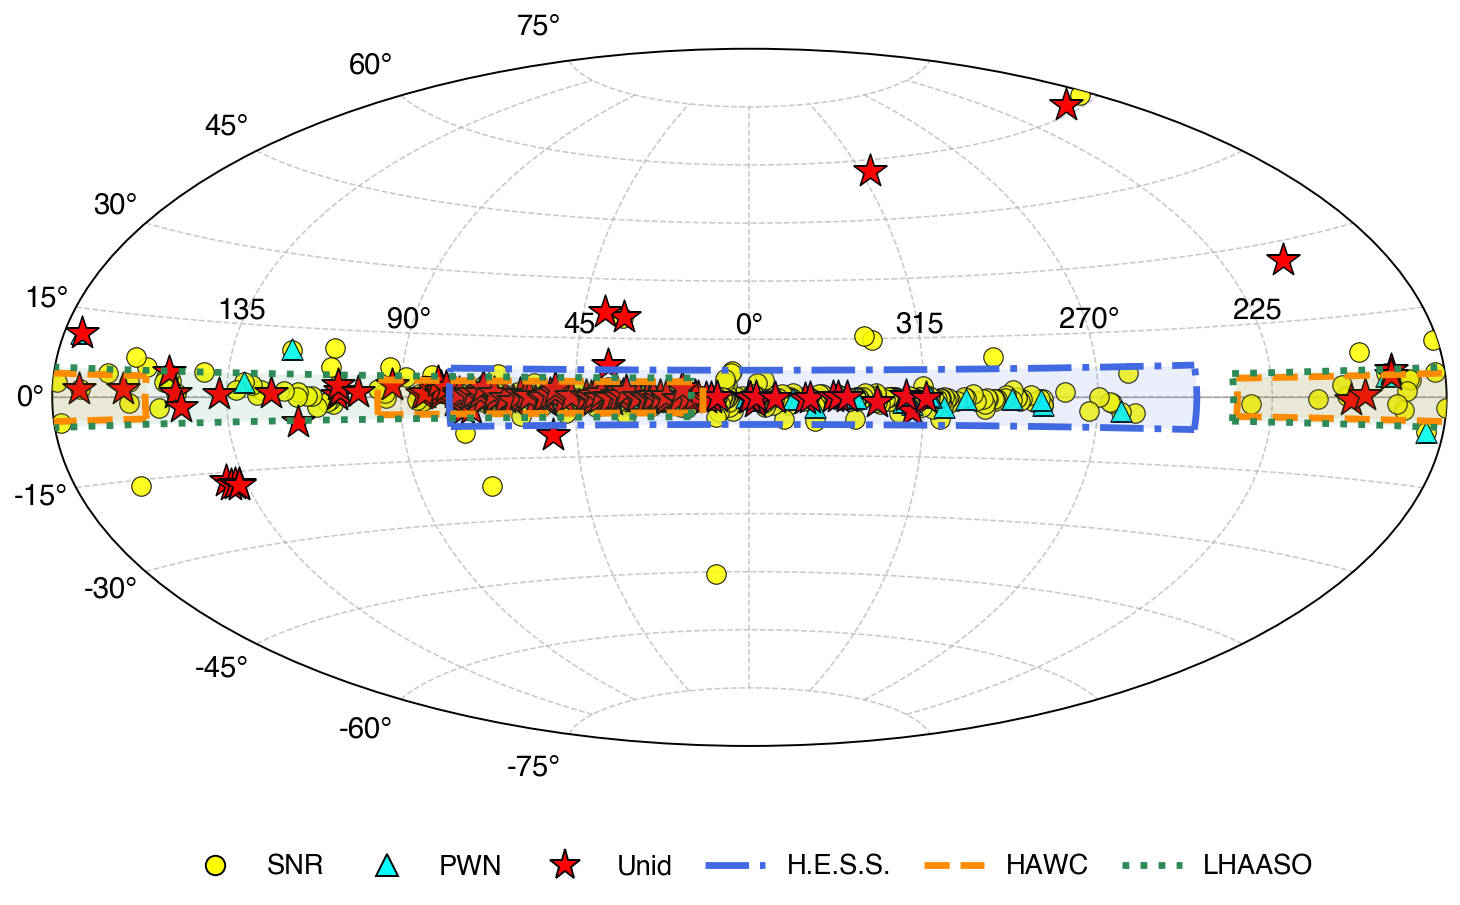

In [99]:

# ======== 銀経フォーマッタ（左が +l） ========
def galactic_lon_formatter(x, pos):
    """Aitoff の −180〜180 を銀経 0〜360 に変換（左が +l）"""
    l = (-np.degrees(x)) % 360
    # 端（±180°）はラベルを非表示
    if np.isclose(abs(np.degrees(x)), 180, atol=1e-2):
        return ""
    # 主目盛（90°間隔）は°付き、それ以外は控えめ
    if int(l) % 90 == 0:
        return f"{int(l)}°"
    return f"{int(l)}"

# ======== 経度処理ヘルパ ========
def wrap180(l_deg):
    """銀経を [-180, 180] に正規化"""
    return (np.asarray(l_deg) + 180.0) % 360.0 - 180.0

# ======== 観測領域プロット ========
def add_lonlat_band(ax, lmin, lmax, bmin, bmax,
                    facecolor='none', edgecolor='k', lw=2.0, linestyle='-',
                    alpha=1.0, label=None, zorder=5):
    if lmin > lmax:  # 跨ぎ
        add_lonlat_band(ax, lmin, 180.0, bmin, bmax,
                        facecolor, edgecolor, lw, linestyle, alpha, None, zorder)
        add_lonlat_band(ax, -180.0, lmax, bmin, bmax,
                        facecolor, edgecolor, lw, linestyle, alpha, label, zorder)
        return
    N = 400
    l_vals = np.linspace(lmin, lmax, N)
    # 塗りつぶし（視認性UP・薄色）
    ax.fill(np.radians([lmin, lmax, lmax, lmin]),
            np.radians([bmin, bmin, bmax, bmax]),
            facecolor=facecolor, edgecolor='none', alpha=0.1, zorder=zorder-1)
    # 外枠
    for y in (bmin, bmax):
        ax.plot(np.radians(l_vals), np.radians(np.full_like(l_vals, y)),
                color=edgecolor, lw=lw, ls=linestyle, alpha=alpha, zorder=zorder)
    for x in (lmin, lmax):
        ax.plot([np.radians(x)]*2, np.radians([bmin, bmax]),
                color=edgecolor, lw=lw, ls=linestyle, alpha=alpha, zorder=zorder)
    if label:
        ax.plot([], [], color=edgecolor, lw=lw, ls=linestyle, label=label)

# ======== データ処理 ========
snr_l_rad  = np.radians(wrap180(snr_l))
pwn_l_rad  = np.radians(wrap180(pwn_l))
unid_l_rad = np.radians(wrap180(unid_l))

# ======== 描画設定 ========
plt.figure(figsize=(14, 6))
ax = plt.subplot(111, projection="aitoff")

# --- 銀河帯 ±5° ---
phi = np.linspace(-np.pi, np.pi, 800)
# ax.fill_between(phi, np.radians(-5), np.radians(5),
#                 color='lightgray', alpha=0.3, zorder=0)
ax.plot(phi, np.zeros_like(phi), color='gray', lw=0.8, alpha=0.6, zorder=1)

# ======== 散布図 ========
ax.scatter(-snr_l_rad,  np.radians(snr_b),
           s=100, color='yellow', marker='o', edgecolor='black',
           linewidth=0.6, alpha=0.85, label='SNR', zorder=3)
ax.scatter(-pwn_l_rad,  np.radians(pwn_b),
           s=120, color='cyan', marker='^', edgecolor='black',
           linewidth=0.6, alpha=0.9, label='PWN', zorder=3)
ax.scatter(-unid_l_rad, np.radians(unid_b),
           s=320, color='red', marker='*', edgecolor='black',
           linewidth=0.8, label='Unid', zorder=4)

# ======== 観測領域（輪郭線） ========
# add_lonlat_band(ax, -77.5, 115.5, -7.0, 7.0,
#                 edgecolor='royalblue', lw=4, linestyle='-.', alpha=1, label='H.E.S.S.', zorder=5)
# add_lonlat_band(ax, -73.0, -43.0, -4.0, 4.0,
#                 edgecolor='darkorange', lw=4, linestyle='--', alpha=1, label='HAWC', zorder=5)
# add_lonlat_band(ax, -190.0, -15.0, -5.0, 5.0,
#                 edgecolor='seagreen', lw=4, linestyle=':', alpha=1, label='LHAASO', zorder=5)
# add_lonlat_band(ax, 125, 190, -5.0, 5.0,
#                 edgecolor='seagreen', lw=4, linestyle=':', alpha=1, label=None, zorder=5)
add_lonlat_band(ax, -77.5, 115.5, -7.0, 7.0,
                facecolor='royalblue', edgecolor='royalblue', lw=3.5, linestyle='-.',
                alpha=1, label='H.E.S.S.', zorder=5)
add_lonlat_band(ax, -96.0, -12.0, -4.0, 4.0,
                facecolor='darkorange', edgecolor='darkorange', lw=3.5, linestyle='--',
                alpha=1, label='HAWC', zorder=5)
add_lonlat_band(ax, -190, -156.0, -4.0, 4.0,
                facecolor='darkorange', edgecolor='darkorange', lw=3.5, linestyle='--',
                alpha=1, label=None, zorder=5)
add_lonlat_band(ax, 360-234, 190.0, -4.0, 4.0,
                facecolor='darkorange', edgecolor='darkorange', lw=3.5, linestyle='--',
                alpha=1, label=None, zorder=5)
add_lonlat_band(ax, -190.0, -15.0, -5.0, 5.0,
                facecolor='seagreen', edgecolor='seagreen', lw=3.5, linestyle=':',
                alpha=1, label='LHAASO', zorder=5)
add_lonlat_band(ax, 125, 190, -5.0, 5.0,
                facecolor='seagreen', edgecolor='seagreen', lw=3.5, linestyle=':',
                alpha=1, label=None, zorder=5)

# ======== 軸・目盛 ========
ax.set_axisbelow(True)  # ← 軸を最前面に
ax.grid(True, linestyle='--', alpha=0.7, zorder=10)  # グリッドも再描画で上へ

# --- 銀経を45°刻みに（±180°は非表示）---
xticks_deg = np.arange(-135, 136, 45)  # -135, -90, -45, 0, 45, 90, 135
ax.set_xticks(np.radians(xticks_deg), minor=False)
ax.xaxis.set_major_formatter(FuncFormatter(galactic_lon_formatter))
ax.tick_params(axis='y', labelsize=15, zorder=100)
for lab in ax.get_xticklabels():
    # x はデータ座標、y は軸座標（0〜1）の変換を使う
    lab.set_transform(ax.get_xaxis_transform())
    x, _ = lab.get_position()
    lab.set_position((x, 0.6))  # デフォルト ~ -0.1 前後。値を -0.08→-0.06→-0.04 と詰めると“上がる”
    ax.tick_params(axis='x', labelsize=15, zorder=100)
    lab.set_va('bottom')
# （任意）上側の目盛線も出すなら

yticks_deg = np.arange(-75, 76, 15)
ax.set_yticks(np.radians(yticks_deg))
ax.set_yticklabels([f"{y}°" for y in yticks_deg])

# # ======== 軸ラベル（白縁取り） ========
# ax.text(0, -np.pi/2 - 0.18, "Galactic Longitude $l$ (deg)",
#         ha='center', va='center', fontsize=18, fontweight='bold',
#         path_effects=[pe.withStroke(linewidth=3, foreground='white')])
# ax.text(-np.pi - 0.25, 0, "Galactic Latitude $b$ (deg)",
#         ha='center', va='center', rotation=90, fontsize=18, fontweight='bold',
#         path_effects=[pe.withStroke(linewidth=3, foreground='white')])

# ---- 凡例（読みやすいシンボルを再構成） ----
# ---- 凡例（読みやすいシンボルを再構成） ----
legend_elems = [
    Line2D([0],[0], marker='o', color='w', label='SNR',
           markerfacecolor='yellow', markeredgecolor='black', markersize=10),
    Line2D([0],[0], marker='^', color='w', label='PWN',
           markerfacecolor='cyan', markeredgecolor='black', markersize=11),
    Line2D([0],[0], marker='*', color='w', label='Unid',
           markerfacecolor='red', markeredgecolor='black', markersize=16),
    Line2D([0],[0], color='royalblue', lw=3.5, ls='-.', label='H.E.S.S.'),
    Line2D([0],[0], color='darkorange', lw=3.5, ls='--', label='HAWC'),
    Line2D([0],[0], color='seagreen', lw=3.5, ls=':', label='LHAASO'),
]
ax.legend(handles=legend_elems, loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=6, frameon=False, fontsize=14, handlelength=2.2, columnspacing=1.2)

plt.subplots_adjust(bottom=0.15, top=0.98)
plt.savefig('/Users/takumi/NS/Figure/lb_distribution.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()


In [39]:
360-115.5


244.5

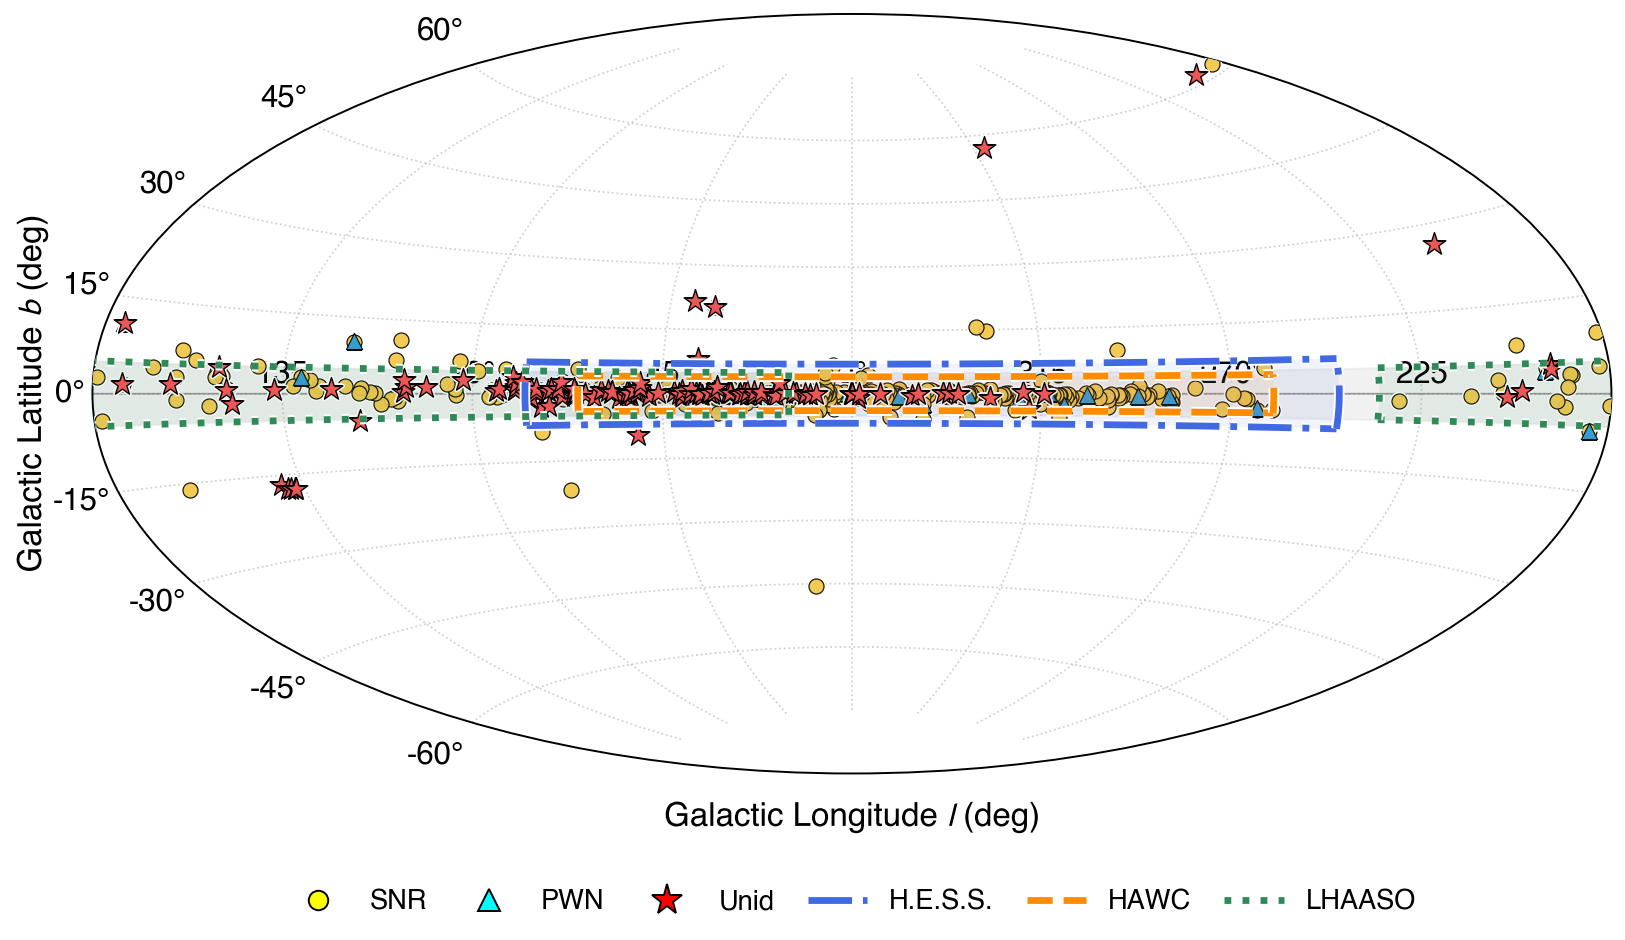

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

# ============ 体裁（見やすさの下地） ============
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,  # PDFで埋め込み互換
    "ps.fonttype": 42,
})

# ======== 銀経フォーマッタ（左が +l） ========
def galactic_lon_formatter(x, pos):
    l = (-np.degrees(x)) % 360
    if np.isclose(abs(np.degrees(x)), 180, atol=1e-2):
        return ""
    lab = int(np.round(l))
    return f"{lab}°" if lab % 90 == 0 else f"{lab}"

def wrap180(l_deg):
    return (np.asarray(l_deg) + 180.0) % 360.0 - 180.0

# ---- 観測領域（矩形） ----
def add_lonlat_band(ax, lmin, lmax, bmin, bmax,
                    facecolor='none', edgecolor='k', lw=2.0, linestyle='-',
                    alpha=1.0, label=None, zorder=5):
    if lmin > lmax:  # 跨ぎ
        add_lonlat_band(ax, lmin, 180.0, bmin, bmax,
                        facecolor, edgecolor, lw, linestyle, alpha, None, zorder)
        add_lonlat_band(ax, -180.0, lmax, bmin, bmax,
                        facecolor, edgecolor, lw, linestyle, alpha, label, zorder)
        return
    N = 400
    l_vals = np.linspace(lmin, lmax, N)
    # 塗りつぶし（視認性UP・薄色）
    ax.fill(np.radians([lmin, lmax, lmax, lmin]),
            np.radians([bmin, bmin, bmax, bmax]),
            facecolor=facecolor, edgecolor='none', alpha=0.08, zorder=zorder-1)
    # 外枠
    for y in (bmin, bmax):
        ax.plot(np.radians(l_vals), np.radians(np.full_like(l_vals, y)),
                color=edgecolor, lw=lw, ls=linestyle, alpha=alpha, zorder=zorder,
                path_effects=[pe.withStroke(linewidth=lw+2, foreground='white')])
    for x in (lmin, lmax):
        ax.plot([np.radians(x)]*2, np.radians([bmin, bmax]),
                color=edgecolor, lw=lw, ls=linestyle, alpha=alpha, zorder=zorder,
                path_effects=[pe.withStroke(linewidth=lw+2, foreground='white')])
    if label:
        ax.plot([], [], color=edgecolor, lw=lw, ls=linestyle, label=label)

# ---- マーカーを“白縁”で読みやすくする ----
def scatter_with_outline(ax, x, y, s, marker, facecolor, edgecolor='black',
                         lw=0.7, zorder=3, alpha=0.9):
    # 太い白縁（下）
    ax.scatter(x, y, s=s, marker=marker, c='white', edgecolor='white',
               linewidth=lw+1.6, alpha=alpha, zorder=zorder-1)
    # 本体（上）
    return ax.scatter(x, y, s=s, marker=marker, c=facecolor, edgecolor=edgecolor,
                      linewidth=lw, alpha=alpha, zorder=zorder)

# ======== データ処理 ========
snr_l_rad  = np.radians(wrap180(snr_l))
pwn_l_rad  = np.radians(wrap180(pwn_l))
unid_l_rad = np.radians(wrap180(unid_l))

# ======== 描画 ========
fig = plt.figure(figsize=(14, 7))
ax = plt.subplot(111, projection="aitoff")

# --- 銀河面 ±5° の帯（薄い塗り） ---
phi = np.linspace(-np.pi, np.pi, 800)
ax.fill_between(phi, np.radians(-5), np.radians(5), color='0.85', alpha=0.35, zorder=0)
ax.plot(phi, np.zeros_like(phi), color='0.4', lw=0.9, alpha=0.6, zorder=1)

# ---- 散布（左が +l なので -lon を使う） ----
h_snr  = scatter_with_outline(ax, -snr_l_rad,  np.radians(snr_b),
                              s=60, marker='o', facecolor='#F2C94C', edgecolor='black',
                              lw=0.6, zorder=4, alpha=0.95)
h_pwn  = scatter_with_outline(ax, -pwn_l_rad,  np.radians(pwn_b),
                              s=70, marker='^', facecolor='#2D9CDB', edgecolor='black',
                              lw=0.6, zorder=4, alpha=0.95)
h_unid = scatter_with_outline(ax, -unid_l_rad, np.radians(unid_b),
                              s=150, marker='*', facecolor='#EB5757', edgecolor='black',
                              lw=0.7, zorder=5, alpha=1.0)

# ---- 観測領域（薄塗り＋白縁アウトライン） ----
add_lonlat_band(ax, -77.5, 115.5, -7.0, 7.0,
                facecolor='royalblue', edgecolor='royalblue', lw=3.5, linestyle='-.',
                alpha=1, label='H.E.S.S.', zorder=5)
add_lonlat_band(ax, -65, 360-260, -4.0, 4.0,
                facecolor='darkorange', edgecolor='darkorange', lw=3.5, linestyle='--',
                alpha=1, label='HAWC', zorder=5)
add_lonlat_band(ax, -190.0, -15.0, -5.0, 5.0,
                facecolor='seagreen', edgecolor='seagreen', lw=3.5, linestyle=':',
                alpha=1, label='LHAASO', zorder=5)
add_lonlat_band(ax, 125, 190, -5.0, 5.0,
                facecolor='seagreen', edgecolor='seagreen', lw=3.5, linestyle=':',
                alpha=1, label=None, zorder=5)

# ---- 目盛・グリッド ----
ax.set_axisbelow(True)
ax.grid(True, linestyle=':', linewidth=0.9, alpha=0.6, zorder=0)

xticks_deg = np.arange(-135, 136, 45)
ax.set_xticks(np.radians(xticks_deg), minor=False)
ax.xaxis.set_major_formatter(FuncFormatter(galactic_lon_formatter))
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

yticks_deg = np.arange(-60, 61, 15)  # |b|>60°は稀なので75°→60°に間引き
ax.set_yticks(np.radians(yticks_deg))
ax.set_yticklabels([f"{y}°" for y in yticks_deg])

# ---- 軸ラベル（白縁取りで読みやすく）----
ax.text(0, -np.pi/2 - 0.18, "Galactic Longitude $l$ (deg)",
        ha='center', va='center', fontsize=17, fontweight='bold',
        path_effects=[pe.withStroke(linewidth=3, foreground='white')])
ax.text(-np.pi - 0.25, 0, "Galactic Latitude $b$ (deg)",
        ha='center', va='center', rotation=90, fontsize=17, fontweight='bold',
        path_effects=[pe.withStroke(linewidth=3, foreground='white')])

# ---- 凡例（読みやすいシンボルを再構成） ----
legend_elems = [
    Line2D([0],[0], marker='o', color='w', label='SNR',
           markerfacecolor='yellow', markeredgecolor='black', markersize=10),
    Line2D([0],[0], marker='^', color='w', label='PWN',
           markerfacecolor='cyan', markeredgecolor='black', markersize=11),
    Line2D([0],[0], marker='*', color='w', label='Unid',
           markerfacecolor='red', markeredgecolor='black', markersize=16),
    Line2D([0],[0], color='royalblue', lw=3.5, ls='-.', label='H.E.S.S.'),
    Line2D([0],[0], color='darkorange', lw=3.5, ls='--', label='HAWC'),
    Line2D([0],[0], color='seagreen', lw=3.5, ls=':', label='LHAASO'),
]
ax.legend(handles=legend_elems, loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=6, frameon=False, fontsize=14, handlelength=2.2, columnspacing=1.2)

plt.subplots_adjust(bottom=0.18, top=0.98)
# plt.savefig('/Users/takumi/NS/Figure/lb_distribution.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()


In [54]:
pwn_HAWC_b[(pwn_HAWC_b < 4) & (pwn_HAWC_l > 43) & (pwn_HAWC_l < 73)]

Series([], Name: b, dtype: float64)

In [41]:
n_unid_HAWC, n_unid_LHAASO, n_unid_HESS, len(pwn_HAWC[np.abs(pwn_HAWC_b) < 4]), len(pwn_LHAASO[np.abs(pwn_LHAASO_b) < 5]), len(pwn_HESS[np.abs(pwn_HESS_b) < 7])

(46, 63, 35, 9, 8, 26)

In [42]:
df_pwn.to_csv("/Users/takumi/NS/PWN/csv/PWN_catalog.csv", index=False)

In [43]:
n_unid_HESS, n_unid_LHAASO, n_unid_HAWC


(35, 63, 46)

In [44]:
pwn_HESS_age.shape, pwn_LHAASO_age.shape, pwn_HAWC_age.shape

((26,), (11,), (10,))

In [61]:
max(pwn_HESS_d)

12.8

In [62]:
0.25 / 3.15 / np.pi * 180

4.547284088339866

In [64]:
6.1*0.18

1.0979999999999999

/var/folders/c3/hk7xv1qj2gz_1dp_9jhkf0f80000gn/T/ipykernel_1122/1930341546.py:23: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_g, pcov_g = curve_fit(rho_powerlaw, t_g, rho_g, p0=p0_rho_g)
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


A = 29.98
beta = 0.99
A (gamma) = 30.00
beta (gamma) = 1.63


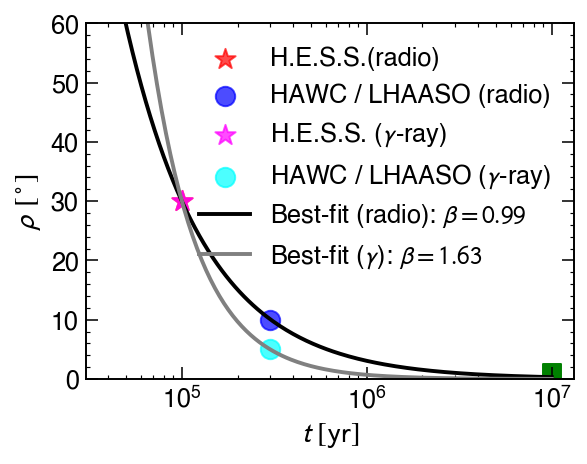

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# data
t = np.array([1e5, 3e5, 1e7])
rho = np.array([30, 10, 1])
t_g = np.array([1e5, 3e5])
rho_g = np.array([30, 5])

t0 = 1e5

# model
def rho_powerlaw(t, A, beta):
    return A * (t / t0)**(-beta)

# better initial guesses
p0_rho = [30, np.log(30/10)/np.log(3)]  
p0_rho_g = [30, np.log(30/5)/np.log(3)]

# fit
popt, pcov = curve_fit(rho_powerlaw, t, rho, p0=p0_rho)
popt_g, pcov_g = curve_fit(rho_powerlaw, t_g, rho_g, p0=p0_rho_g)

A_fit, beta_fit = popt
A_fit_g, beta_fit_g = popt_g

print(f"A = {A_fit:.2f}")
print(f"beta = {beta_fit:.2f}")
print(f"A (gamma) = {A_fit_g:.2f}")
print(f"beta (gamma) = {beta_fit_g:.2f}")

# plot
t_plot = np.logspace(4.6, 7, 200)
plt.scatter(1e5, 30, s=120, c='red', marker='*', label='H.E.S.S.(radio)', alpha =0.7)
plt.scatter(3e5, 10, s=100, c='blue', marker='o', label='HAWC / LHAASO (radio)', alpha =0.7)
plt.scatter(1e7, 1, s=80, c='green', marker='s')
plt.scatter(1e5, 30, s=120, c='magenta', marker='*', label=r'H.E.S.S. ($\gamma$-ray)', alpha =0.7)
plt.scatter(3e5, 5, s=100, c='cyan', marker='o', label=r'HAWC / LHAASO ($\gamma$-ray)', alpha =0.7)

plt.plot(
    t_plot,
    rho_powerlaw(t_plot, *popt),
    lw=2,
    color='k',
    label=rf'Best-fit (radio): $\beta={beta_fit:.2f}$'
)
plt.plot(
    t_plot,
    rho_powerlaw(t_plot, *popt_g),
    lw=2,
    color='gray',
    label=rf'Best-fit ($\gamma$): $\beta={beta_fit_g:.2f}$'
)

plt.ylim(0, 60)
plt.xscale('log')
plt.xlabel(r'$t\ [{\rm yr}]$')
plt.ylabel(r'$\rho\ [^\circ]$')
plt.legend(frameon=False)
plt.savefig('rho_vs_time_fit.pdf', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/c3/hk7xv1qj2gz_1dp_9jhkf0f80000gn/T/ipykernel_1122/4209412591.py:27: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_g, pcov_g = curve_fit(
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


radio: tc = 5.75e+04 yr, beta = 1.26
gamma: tc = 7.01e+04 yr, beta = 1.95


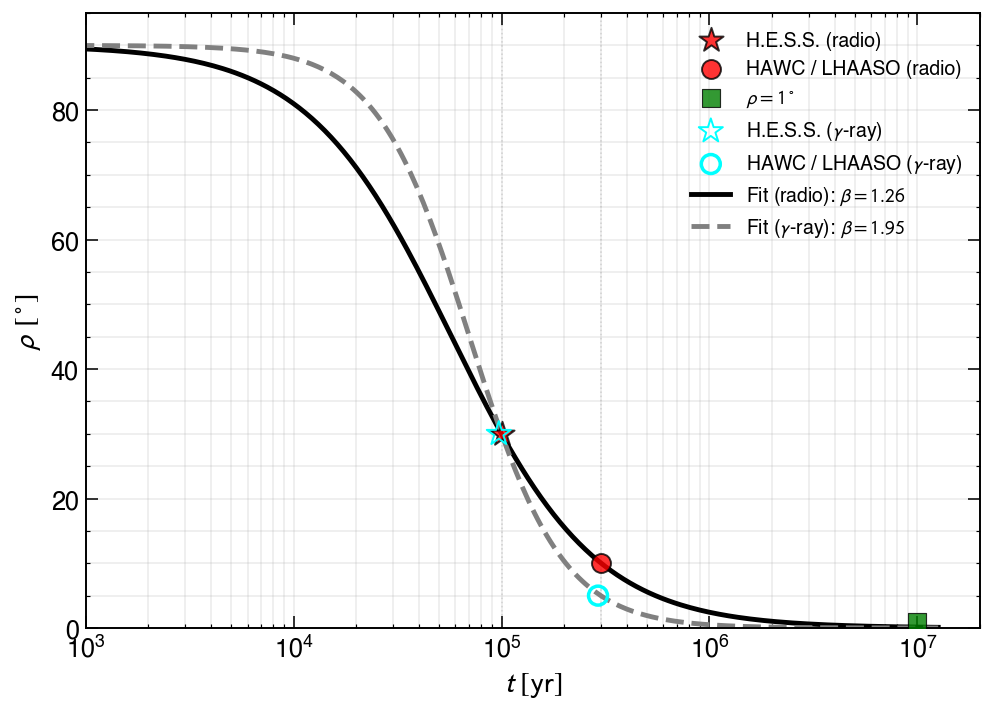

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# data
t = np.array([1e5, 3e5, 1e7], dtype=float)
rho = np.array([30, 10, 1], dtype=float)

t_g = np.array([1e5, 3e5], dtype=float)
rho_g = np.array([30, 5], dtype=float)

rho0 = 90.0  # impose rho(t=0)=90 deg

# model
def rho_model(t, tc, beta):
    return rho0 / (1.0 + (t / tc)**beta)

# fit
p0 = [5e4, 1.0]

popt, pcov = curve_fit(
    rho_model, t, rho,
    p0=p0,
    bounds=([1e3, 0.01], [1e8, 10.0])
)

popt_g, pcov_g = curve_fit(
    rho_model, t_g, rho_g,
    p0=p0,
    bounds=([1e3, 0.01], [1e8, 10.0])
)

tc_fit, beta_fit = popt
tc_fit_g, beta_fit_g = popt_g

print(f"radio: tc = {tc_fit:.2e} yr, beta = {beta_fit:.2f}")
print(f"gamma: tc = {tc_fit_g:.2e} yr, beta = {beta_fit_g:.2f}")

# plot range
t_plot = np.logspace(1, 7.1, 400)

# ---- small x-offsets to avoid overlap on log axis ----
f_left  = 1
f_right = 0.97

t_radio_plot = np.array([1e5 * f_left, 3e5 * f_left, 1e7], dtype=float)
t_gamma_plot = np.array([1e5 * f_right, 3e5 * f_right], dtype=float)

fig, ax = plt.subplots(figsize=(7.2, 5.2))

# radio data
ax.scatter(
    t_radio_plot[0], rho[0],
    s=170, c='red', marker='*', alpha=0.8,
    edgecolors='k', linewidths=1,
    label='H.E.S.S. (radio)', zorder=5
)
ax.scatter(
    t_radio_plot[1], rho[1],
    s=95, c='red', marker='o', alpha=0.8,
    edgecolors='k', linewidths=1,
    label='HAWC / LHAASO (radio)', zorder=5
)
ax.scatter(
    t_radio_plot[2], rho[2],
    s=95, c='green', marker='s', alpha=0.8,
    edgecolors='k', linewidths=0.6,
    label=r'$\rho = 1^\circ$', zorder=5
)

# gamma-ray data
ax.scatter(
    t_gamma_plot[0], rho_g[0],
    s=170, facecolors='none', edgecolors='cyan',
    marker='*', linewidths=1,
    label=r'H.E.S.S. ($\gamma$-ray)', zorder=6
)
ax.scatter(
    t_gamma_plot[1], rho_g[1],
    s=95, facecolors='none', edgecolors='cyan',
    marker='o', linewidths=1.8,
    label=r'HAWC / LHAASO ($\gamma$-ray)', zorder=6
)

# fit curves
ax.plot(
    t_plot, rho_model(t_plot, *popt),
    lw=2.5, color='k',
    label=rf'Fit (radio): $\beta={beta_fit:.2f}$'
)
ax.plot(
    t_plot, rho_model(t_plot, *popt_g),
    lw=2.5, color='gray', ls='--',
    label=rf'Fit ($\gamma$-ray): $\beta={beta_fit_g:.2f}$'
)

# guide lines at true times
for xx in [1e5, 3e5]:
    ax.axvline(xx, color='0.85', lw=0.8, ls=':', zorder=0)

ax.set_xscale('log')
ax.set_xlim(1e3, 2e7)
ax.set_ylim(0, 95)

ax.set_xlabel(r'$t\ [{\rm yr}]$')
ax.set_ylabel(r'$\rho\ [^\circ]$')

ax.grid(alpha=0.25, which='both')
ax.legend(frameon=False, fontsize=10, ncol=1, loc='upper right')

plt.tight_layout()
plt.savefig('rho_vs_time_fit.pdf', dpi=300, bbox_inches='tight')
plt.show()